# TFM — Comprensión documental, auditoría de datos y EDA

## Sistema explicable de detección preventiva de indicadores de riesgo en salud mental adulta mediante aprendizaje automático multisalida y agentes de inteligencia artificial generativa a partir del dataset NSDUH 2024

**Autor:** Carlos Ayllón Motto  
**Máster:** Big Data, Data Science e Inteligencia Artificial  
**Dataset:** National Survey on Drug Use and Health 2024  
**Fuente:** SAMHSA  
**Población de análisis:** personas adultas de 18 años o más

---

Este notebook documenta la auditoría del fichero público, la definición de la población adulta, la validación de las cuatro variables objetivo, el control de fuga, la selección conceptual de predictores y la preparación de una base premodelado reproducible.

No incluye entrenamiento, ajuste de hiperparámetros, SHAP, agentes ni productivización.

# 0. Configuración, documentación y trazabilidad

La propuesta definitiva fija el alcance del TFM. La documentación oficial de NSDUH establece el significado de las variables, códigos, criterios de aplicación de las preguntas, imputaciones y pesos muestrales; los trabajos realizados durante el máster se utilizan únicamente como referencia metodológica y de estilo.

| Nivel | Fuentes | Función |
|---|---|---|
| Alcance | Propuesta definitiva del TFM | Objetivos, población y entregables |
| Datos | Guía PUF, codebook, cuestionarios e informes metodológicos | Interpretación de los datos y del diseño muestral |
| Implementación | Código y notebooks del máster | Organización, validación y presentación |

Ante cualquier duda prevalecerán el alcance aprobado y la documentación oficial. Las decisiones relevantes quedarán respaldadas por una fuente, una comprobación empírica o ambas, y se conservarán en las tablas exportadas y en el registro general del proyecto.

## 0.1. Importación de librerías

Se importan las librerías necesarias para la lectura y tratamiento del fichero público, la revisión de la documentación oficial, el análisis tabular y la representación gráfica de los resultados.

En esta fase no se incorporan librerías de modelado, ya que el notebook se limita a la comprensión documental, depuración, selección conceptual de variables y análisis exploratorio previo al modelado.

In [1]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import hashlib
import platform
import re
from importlib.metadata import version
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pypdf import PdfReader

## 0.2. Configuración general y rutas

Se establece la codificación común de los archivos CSV y se comprueban las versiones de Python y de las bibliotecas utilizadas directamente en este notebook. La validación compara cada versión detectada con la fijada para el entorno `TFM_ML`, mostrando un estado `OK` o `REVISAR` sin modificar ni actualizar ningún paquete.

También se centralizan las rutas del conjunto de datos original, la documentación oficial y las carpetas destinadas a las tablas, figuras y datos intermedios generados durante el EDA. Antes de continuar se comprueba la disponibilidad de las dos entradas necesarias: el fichero público NSDUH 2024 y el archivo comprimido con su documentación.

In [2]:
# =============================================================================
# CONFIGURACIÓN GENERAL Y RUTAS
# =============================================================================
# -----------------------------------------------------------------------------
# ENTORNO
# -----------------------------------------------------------------------------
encoding_csv = 'utf-8-sig'

lib_auditadas = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'pyarrow', 'pypdf'
]

versiones_libs = {paquete: version(paquete) for paquete in lib_auditadas}

versiones_esperadas_eda = {
    'Python': '3.11.15',
    'NumPy': '2.4.6',
    'pandas': '3.0.5',
    'Matplotlib': '3.11.1',
    'Seaborn': '0.13.2',
    'PyArrow': '25.0.0',
    'pypdf': '6.14.2'
}

versiones_detectadas_eda = {
    'Python': platform.python_version(),
    'NumPy': versiones_libs['numpy'],
    'pandas': versiones_libs['pandas'],
    'Matplotlib': versiones_libs['matplotlib'],
    'Seaborn': versiones_libs['seaborn'],
    'PyArrow': versiones_libs['pyarrow'],
    'pypdf': versiones_libs['pypdf']
}

tabla_versiones_eda = pd.DataFrame([
    {
        'Elemento': elemento,
        'Versión': version_detectada,
        'Esperada': versiones_esperadas_eda[elemento],
        'Estado': 'OK' if version_detectada == versiones_esperadas_eda[elemento] else 'REVISAR'
    } for elemento, version_detectada in versiones_detectadas_eda.items()
])

print('\nVERSIONES DEL ENTORNO')
display(tabla_versiones_eda)

# -----------------------------------------------------------------------------
# RUTAS
# -----------------------------------------------------------------------------
ruta_proyecto = Path.home() / 'BD' / 'TFM_NSDUH'
ruta_documentos = ruta_proyecto / 'references' / 'NSDUH_2024'

ruta_datos = ruta_proyecto / 'data' / 'raw' / 'NSDUH_2024_Tab.txt'
ruta_zip_doc = ruta_documentos / '2024-nsduh-archivos.zip'

ruta_interim = ruta_proyecto / 'data' / 'interim'
ruta_tablas = ruta_proyecto / 'results' / 'tables' / '01_datos_eda'
ruta_figuras = ruta_proyecto / 'results' / 'figures' / '01_datos_eda'

ruta_base = ruta_interim / 'NSDUH_2024_adultos_premodelado.parquet'

for ruta in [ruta_interim, ruta_tablas, ruta_figuras]:
    ruta.mkdir(parents=True, exist_ok=True)

if not ruta_datos.is_file():
    raise FileNotFoundError(f'No se encuentra el conjunto de datos:\n{ruta_datos}')

if not ruta_zip_doc.is_file():
    raise FileNotFoundError(f'No se encuentra el ZIP documental:\n{ruta_zip_doc}')

print('\nConfiguración general y rutas validadas correctamente.')


VERSIONES DEL ENTORNO


,Elemento,Versión,Esperada,Estado
0,Python,3.11.15,3.11.15,OK
1,NumPy,2.4.6,2.4.6,OK
2,pandas,3.0.5,3.0.5,OK
3,Matplotlib,3.11.1,3.11.1,OK
4,Seaborn,0.13.2,0.13.2,OK
5,PyArrow,25.0.0,25.0.0,OK
6,pypdf,6.14.2,6.14.2,OK



Configuración general y rutas validadas correctamente.


## 0.3. Diccionarios y etiquetas

Se centralizan las variables objetivo, sus indicadores de imputación y las etiquetas comunes que se utilizarán posteriormente en tablas y gráficos. Las denominaciones visibles de las cuatro variables objetivo se mantienen iguales a las utilizadas en los notebooks de modelado.

También se define un diccionario común para la presentación de tablas. Los nombres técnicos permanecen disponibles durante los cálculos, mientras que las copias destinadas a visualización pueden utilizar encabezados más claros sin modificar los DataFrames de trabajo ni los archivos guardados.

In [3]:
# =============================================================================
# DICCIONARIOS Y ETIQUETAS
# =============================================================================
# -----------------------------------------------------------------------------
# VARIABLES OBJETIVO E INDICADORES DE IMPUTACIÓN
# -----------------------------------------------------------------------------
targets = [
    'IRAMDEYR',
    'IRSUICTHNK',
    'IRSUIPLANYR',
    'IRSUITRYYR'
]

indicadores_imputacion = [
    'IIAMDEYR',
    'IISUICTHNK',
    'IISUIPLANYR',
    'IISUITRYYR'
]

variables_diseno = [
    'ANALWT2_C',
    'VESTR_C',
    'VEREP'
]

titulos_targets = {
    'IRAMDEYR': 'Episodio depresivo mayor',
    'IRSUICTHNK': 'Ideación suicida',
    'IRSUIPLANYR': 'Planificación suicida',
    'IRSUITRYYR': 'Intento suicida'
}

titulos_targets_red = {
    'IRAMDEYR': 'Depresión',
    'IRSUICTHNK': 'Ideación',
    'IRSUIPLANYR': 'Planificación',
    'IRSUITRYYR': 'Intento'
}

# -----------------------------------------------------------------------------
# RENOMBRADO COMÚN DE TABLAS
# -----------------------------------------------------------------------------
renombrado_comun_eda = {
    # Variables e identificación
    'AGE3': 'Código AGE3',
    'edad': 'Edad',
    'variable': 'Variable',
    'variable_1': 'Variable 1',
    'variable_2': 'Variable 2',
    'variable_grupo': 'Variable de agrupación',
    'variable_vinculada': 'Variable vinculada',
    'variable_objetivo': 'Variable objetivo',
    'variables_objetivo': 'Variables objetivo',
    'descripcion': 'Descripción',
    # Tipos, módulos y roles
    'tipo': 'Tipo',
    'tipo_version': 'Tipo de versión',
    'tipo_modulo': 'Tipo de módulo',
    'tipo_vinculo': 'Tipo de vínculo',
    'tipo_variable': 'Tipo de variable',
    'rol_provisional': 'Rol provisional',
    'rol_final_eda': 'Rol final EDA',
    'rol_base': 'Rol',
    'uso_provisional': 'Uso provisional',
    'modulo': 'Módulo',
    'modulos': 'Módulos',
    # Decisiones y comprobaciones
    'motivo': 'Motivo',
    'justificacion': 'Justificación',
    'decision_funcional': 'Decisión funcional',
    'decision_modulo': 'Decisión del módulo',
    'comprobacion': 'Comprobación',
    'resultado': 'Resultado',
    'elemento': 'Elemento',
    'valor': 'Valor',
    # Recuentos generales
    'variables': 'Variables',
    'predictores': 'Predictores',
    'frecuencia': 'Frecuencia',
    'porcentaje': 'Porcentaje (%)',
    'patron': 'Patrón',
    'registros': 'Registros',
    'n_registros': 'Registros',
    'n_presentes': 'Valores presentes',
    'n_unicos': 'Valores únicos',
    'n_validos': 'Valores válidos',
    # Valores físicamente ausentes
    'n_nan': 'Valores físicamente ausentes',
    'pct_nan': 'Valores físicamente ausentes (%)',
    'n_nan_adultos': 'Valores físicamente ausentes',
    'pct_nan_adultos': 'Valores físicamente ausentes (%)',
    'pct_nan_medio': 'Media de valores físicamente ausentes (%)',
    'pct_nan_mediana': 'Mediana de valores físicamente ausentes (%)',
    'pct_nan_max': 'Máximo de valores físicamente ausentes (%)',
    'vars_sin_nan': 'Variables sin valores físicamente ausentes',
    'vars_nan_90': 'Variables con ≥ 90 % de valores físicamente ausentes',
    # Variables objetivo y prevalencias
    'valor_0': 'Valor 0',
    'valor_1': 'Valor 1',
    'otros_valores': 'Otros valores',
    'positivos': 'Positivos',
    'n_positivos': 'Positivos',
    'prevalencia_pct': 'Prevalencia (%)',
    'registros_cuestionario': 'Registros del cuestionario',
    'registros_imputados': 'Registros imputados',
    'prevalencia_cuestionario_pct': 'Prevalencia cuestionario (%)',
    'prevalencia_imputados_pct': 'Prevalencia imputados (%)',
    'pct_imputados': 'Registros imputados (%)',
    'diferencia_pp': 'Diferencia (pp)',
    'pct_no_ponderado': 'Prevalencia no ponderada (%)',
    'pct_ponderado': 'Prevalencia ponderada (%)',
    'prevalencia_ponderada': 'Prevalencia ponderada (%)',
    'indicadores_imputacion': 'Indicadores de imputación',
    # Exclusiones y relaciones documentales
    'valor_constante': 'Valor constante',
    'predictores_candidatos': 'Predictores candidatos',
    'nivel_maximo': 'Nivel máximo',
    'fuente_directa': 'Fuente directa',
    'indicador': 'Indicador',
    'casos_cuestionario_validos': 'Casos válidos del cuestionario',
    'coincidencias': 'Coincidencias',
    'diferencias': 'Diferencias',
    'pct_coincidencia': 'Coincidencia (%)',
    'presentes_eda': 'Presentes en el EDA',
    # Codebook y códigos documentales
    'etiqueta_codebook': 'Etiqueta del codebook',
    'tipo_codigo_doc': 'Tipo de código documental',
    'codigos': 'Códigos',
    'codigo_doc': 'Código documental',
    'etiqueta_codigo': 'Etiqueta del código',
    'frecuencia_codebook': 'Frecuencia en codebook',
    'pct_codebook': 'Frecuencia en codebook (%)',
    'codigos_documentados': 'Códigos documentados',
    'codigos_presentes': 'Códigos observados',
    'observaciones_adultos': 'Observaciones en adultos',
    'interpretacion_nan': 'Interpretación del valor ausente',
    'codigo_nan_doc': 'Código documental de ausencia',
    'etiqueta_nan_doc': 'Etiqueta documental de ausencia',
    # Estructura de predictores
    'mediana_dominante': 'Mediana del valor dominante (%)',
    'pct_dominante': 'Valor dominante (%)',
    'mediana_valores_unicos': 'Mediana de valores únicos',
    'celdas': 'Celdas',
    'pct_celdas_predictores': 'Celdas de los predictores (%)',
    # Variables numéricas
    'mediana_fuera_rango': 'Mediana fuera de rango (%)',
    'rango_documentado': 'Rango documentado',
    'pct_fuera_rango': 'Valores fuera de rango (%)',
    'tipos_fuera_rango': 'Tipos fuera de rango',
    'tramo_valores_validos': 'Tramo de valores válidos',
    'pct_validos': 'Valores válidos (%)',
    'media': 'Media',
    'mediana': 'Mediana',
    'minimo': 'Mínimo',
    'maximo': 'Máximo',
    'q1': 'Primer cuartil',
    'q3': 'Tercer cuartil',
    'minimo_valido': 'Mínimo válido',
    'maximo_valido': 'Máximo válido',
    'pct_alejados_iqr': 'Valores alejados según IQR (%)',
    # Correlaciones
    'n_comunes': 'Observaciones comunes',
    'correlacion_spearman': 'Correlación de Spearman',
    'correlacion_absoluta': 'Correlación absoluta',
    # Variables categóricas
    'mediana_categorias': 'Mediana de categorías',
    'n_categorias_observadas': 'Categorías observadas',
    'n_categorias_minoritarias_1': 'Categorías < 1 %',
    'pct_acum_minoritarias_1': 'Categorías < 1 % acumuladas',
    'variables_con_minoritarias_1': 'Variables con categorías < 1 %',
    'variables_con_minoritarias_01': 'Variables con categorías < 0,1 %',
    'mediana_pct_minoritarias_1': 'Mediana acumulada de categorías < 1 %',
    # Porcentajes ponderados y muestrales
    'porcentaje_muestral': 'Porcentaje muestral (%)',
    'porcentaje_ponderado': 'Porcentaje ponderado (%)',
}

## 0.4. Funciones auxiliares

Se centralizan las funciones reutilizadas durante el EDA para la lectura y guardado de archivos, preparación de tablas de presentación, etiquetado de gráficos y representación de matrices de correlación.

También se mantienen algunas funciones de apoyo a la revisión documental, necesarias para normalizar códigos y recorrer las relaciones registradas entre variables. Las funciones auxiliares se reservan para operaciones repetidas; los análisis específicos de cada apartado permanecerán visibles en sus propias celdas.

In [4]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================
# -----------------------------------------------------------------------------
# GUARDADO Y CARGA
# -----------------------------------------------------------------------------
def guardar_csv(df, nombre, **kwargs):
    """
    Guarda un DataFrame en la carpeta de tablas del EDA.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError('El objeto debe ser un DataFrame.')
    if not str(nombre).lower().endswith('.csv'):
        nombre = f'{nombre}.csv'

    kwargs.setdefault('index', False)
    kwargs.setdefault('encoding', encoding_csv)
    ruta = ruta_tablas / nombre
    df.to_csv(ruta, **kwargs)

    return ruta


def guardar_figura(fig, nombre, dpi=300, rect=None):
    """
    Guarda, muestra y cierra una figura del EDA.
    """
    ruta = ruta_figuras / f'{nombre}.png'

    if rect is None:
        fig.tight_layout()
    else:
        fig.tight_layout(rect=rect)

    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor='white')
    display(fig)
    plt.close(fig)

    return ruta


def cargar_tsv(ruta, **kwargs):
    """
    Carga un archivo TSV con la configuración común del proyecto.
    """
    kwargs.setdefault('sep', '\t')
    kwargs.setdefault('encoding', encoding_csv)
    kwargs.setdefault('low_memory', False)

    salida = pd.read_csv(ruta, **kwargs)

    return salida


# -----------------------------------------------------------------------------
# PRESENTACIÓN
# -----------------------------------------------------------------------------
def preparar_tabla(df, columnas=None, redondeo=None):
    """
    Prepara una copia de un DataFrame exclusivamente para presentación.
    """
    tabla = df.copy()

    if columnas is not None:
        tabla = tabla[columnas]

    if redondeo is not None:
        tabla = tabla.round(redondeo)

    return tabla.rename(columns=renombrado_comun_eda)


def etiquetar_barras(
    ax, decimales=1, porcentaje=False, padding=3, fontsize=9, ocultar_ceros=False
):
    """
    Añade etiquetas numéricas a las barras de un eje.
    """

    sufijo = ' %' if porcentaje else ''

    for container in ax.containers:
        etiquetas = [
            '' if ocultar_ceros and valor == 0 else f'{valor:.{decimales}f}{sufijo}'
            for valor in container.datavalues
        ]

        ax.bar_label(container, labels=etiquetas, padding=padding, fontsize=fontsize)


# -----------------------------------------------------------------------------
# REPRESENTACIÓN GRÁFICA
# -----------------------------------------------------------------------------
def grafico_anillo(ax, valores, etiquetas, texto_centro, paleta='Set2', leyenda=False):
    """
    Representa una distribución mediante un gráfico de anillo.
    """
    colores = sns.color_palette(paleta, len(valores))
    sectores, _, _ = ax.pie(
        valores, labels=None if leyenda else etiquetas, autopct='%1.1f %%',
        pctdistance=0.78, startangle=90, colors=colores,
        wedgeprops={'width': 0.42, 'edgecolor': 'white'}
    )
    if leyenda:
        ax.legend(
            sectores, etiquetas, loc='upper center', bbox_to_anchor=(0.5, -0.03),
            frameon=False, fontsize=8
        )
    ax.text(0, 0, texto_centro, ha='center', va='center', fontsize=10, weight='bold')


def matriz_correlacion(
    matriz, titulo, nombre, xlabel='', ylabel='', triangular=False, figsize=(8, 6),
    rotacion_x=0, rotacion_y=0, tam_etiqueta=10
):
    """
    Representa y guarda una matriz de correlación.
    """
    if not isinstance(matriz, pd.DataFrame):
        raise TypeError('La matriz debe ser un DataFrame.')
    if triangular and matriz.shape[0] != matriz.shape[1]:
        raise ValueError('La máscara triangular requiere una matriz cuadrada.')

    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1) if triangular else None

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        matriz, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
        mask=mascara, linewidths=0.5, linecolor='white', square=True,
        cbar_kws={'label': 'Coeficiente', 'shrink': 0.85}, ax=ax
    )

    ax.set_title(titulo, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelrotation=rotacion_x, labelsize=tam_etiqueta)
    ax.tick_params(axis='y', labelrotation=rotacion_y, labelsize=tam_etiqueta)

    if rotacion_x:
        plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')

    _ = guardar_figura(fig, nombre)


# -----------------------------------------------------------------------------
# REVISIÓN DOCUMENTAL
# -----------------------------------------------------------------------------
def normalizar_codigo(valor):
    """
    Normaliza los códigos documentales para facilitar su comparación.
    """
    if pd.isna(valor):
        return None, False

    texto = str(valor).strip()

    if texto == '':
        return '__VACIO__', False
    if texto == '.':
        return '__PUNTO__', False
    if texto.upper() == 'RANGE':
        return '__RANGO__', False

    try:
        numero = float(texto)

        if np.isfinite(numero):
            numero = round(numero, 1)
            codigo = str(int(numero)) if numero.is_integer() else f'{numero:.1f}'

            return codigo, True

    except ValueError:
        pass

    return texto, False


def separar_referencias(valor):
    """
    Separa las referencias documentales almacenadas en una cadena.
    """
    if pd.isna(valor) or not str(valor).strip():
        return []

    salida = [ref.strip() for ref in str(valor).split(',') if ref.strip()]
    return salida


def recorrer_grafo(origen, grafo):
    """
    Recorre las dependencias documentales a partir de una variable.
    """
    resultados = {}
    pendientes = [(variable, 1) for variable in grafo.get(origen, [])]
    visitadas = {origen}

    while pendientes:
        variable, nivel = pendientes.pop(0)

        if variable in visitadas:
            continue

        visitadas.add(variable)
        resultados[variable] = nivel
        pendientes.extend((siguiente, nivel + 1) for siguiente in grafo.get(variable, []))

    return resultados


def extraer_limites(rango):
    """
    Extrae los límites inferior y superior de un rango documental.
    """
    patron = (r'^\s*(-?\d+(?:\.\d+)?)\s*-\s*(-?\d+(?:\.\d+)?)\s*$')

    coincidencia = re.search(patron, str(rango))

    if coincidencia is None:
        return np.nan, np.nan

    salida = (float(coincidencia.group(1)), float(coincidencia.group(2)))

    return salida


def clasificar_codigo_documental(codigo, etiqueta):
    """
    Clasifica un código documental según su etiqueta y significado operativo.
    """
    texto = etiqueta.upper()

    if codigo == 'RANGE':
        return 'Rango válido'
    if codigo == '':
        return 'Categoría válida vacía'
    if re.search(r'LOGICALLY ASSIGNED|LOGICAL(?:LY)? ASSIGN', texto):
        return 'Asignación lógica'
    if re.search(
        r'LEGIT(?:IMATE)? SKIP|NOT APPLICABLE|NOT IN UNIVERSE|AGED 12-17|21 OR OLDER|OTHERWISE',
        texto
    ):
        return 'Salto legítimo o no aplicable'
    if re.search(
        r'NEVER USED|NEVER HAD|NEVER SMOKED|NEVER DRANK|'
        r'DID NOT USE|NOT USED|NON[- ]?USER|NO PAST .*USE',
        texto
    ):
        return 'Ausencia de exposición'
    if re.search(
        r"DON'?T KNOW|REFUSED|BAD DATA|BLANK|UNKNOWN|SYSTEM MISSING|MISSING",
        texto
    ):
        return 'No respuesta o ausencia'
    if codigo == '.':
        return 'Ausencia documental'

    return 'Categoría analítica'

## Síntesis de la sección 0 (memoria)

El Notebook 01 se ejecuta en el entorno `TFM_ML` con las versiones de Python y de las bibliotecas utilizadas coincidentes con las versiones fijadas para el proyecto. Las rutas del conjunto público NSDUH 2024, de su documentación oficial y de las carpetas de resultados quedan centralizadas y validadas antes de comenzar el análisis.

La configuración establece además las cuatro variables objetivo, sus indicadores de imputación, las variables del diseño muestral y la nomenclatura común utilizada en tablas y figuras. Las funciones auxiliares concentran las operaciones reutilizadas de lectura, guardado, presentación, representación gráfica y revisión documental, manteniendo visibles en las secciones posteriores los análisis específicos.

Esta preparación proporciona una base reproducible para la comprensión documental, la depuración y el EDA, sin incorporar todavía operaciones de modelado ni transformaciones aprendidas a partir de los datos.

**Tabla candidata:** no; las versiones completas del entorno y los diccionarios se reservan para anexos.

**Figura candidata:** no.

**Destino:** ANEXO.

# 1. Interpretación del fichero público NSDUH 2024

Antes de iniciar la depuración se revisan las características del fichero público, el diseño de la encuesta y la codificación utilizada. Esta interpretación documental permite distinguir los valores físicamente ausentes de los códigos con significado específico y establecer correctamente los criterios aplicables a cada variable.

## 1.1. Población y diseño muestral

El NSDUH estudia a la población civil no institucionalizada de Estados Unidos de 12 años o más. Utiliza un diseño probabilístico, estratificado y multietápico, por lo que las estimaciones poblacionales deben considerar el peso y las variables del diseño de encuesta.

## 1.2. Tipos de variables

El fichero contiene variables editadas, imputadas, recodificadas y técnicas. Las versiones imputadas suelen utilizar el prefijo `IR` y sus indicadores el prefijo `II`; las recodificadas suelen aparecer en módulos `RECODED` y presentan etiquetas `RC`.

Las variables `II` se conservarán como auxiliares para auditar la procedencia de los valores, pero no formarán parte de las variables de entrada del modelado. Las versiones imputadas o recodificadas se valorarán según su finalidad y documentación.

## 1.3. Códigos especiales y valores ausentes

El codebook utiliza códigos para distinguir no respuesta, rechazo, saltos legítimos, ausencia de exposición y asignaciones lógicas. Su significado depende de cada variable, por lo que no se realizará una recodificación global basada únicamente en el valor numérico.

Los valores físicamente ausentes se analizarán de forma independiente de estos códigos documentados, evitando interpretar automáticamente cualquier ausencia como un error del conjunto de datos.

## 1.4. Peso muestral y población adulta

`ANALWT2_C` es el peso individual de análisis del PUF. Se utilizará para las descripciones poblacionales cuando proceda y se conservará como variable de diseño, separada de las variables de entrada del modelado principal.

La población adulta y el tratamiento de cada variable se definirán posteriormente mediante la información del codebook y las frecuencias observadas en el fichero.

**Fuentes:** guía del PUF 2024, codebook oficial e informes metodológicos del NSDUH 2024.

## 1.5. Comprobación estructural y carga de datos

Antes de cargar el fichero completo se revisa su cabecera para comprobar el número de variables, la ausencia de nombres duplicados o vacíos y la coincidencia entre la separación directa de la primera línea y la lectura realizada con pandas.

Una vez validada la estructura, se carga el conjunto de datos completo y se comprueban sus dimensiones, el uso aproximado de memoria, la presencia de registros duplicados exactos y los tipos de datos obtenidos.

In [5]:
# =============================================================================
# COMPROBACIÓN DE LA CABECERA
# =============================================================================
# Se comprueba la estructura de la cabecera sin cargar el conjunto completo.
with ruta_datos.open('r', encoding=encoding_csv) as archivo:
    cabecera = archivo.readline().rstrip('\r\n')

columnas_cabecera = cabecera.split('\t')
columnas_lectura = cargar_tsv(ruta_datos, nrows=0).columns.tolist()

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('COMPROBACIÓN DE LA CABECERA')
print('Ruta:', ruta_datos)
print(f'Tamaño: {ruta_datos.stat().st_size / (1024 ** 2):,.2f} MB')
print(f'Tabuladores: {cabecera.count(chr(9)):,}')
print(f'Variables: {len(columnas_cabecera):,}')
print(f'Cabecera reproducida correctamente: {columnas_cabecera == columnas_lectura}')
print(f'Nombres duplicados: {pd.Series(columnas_cabecera).duplicated().sum():,}')
print(f'Nombres vacíos: {sum(nombre == "" for nombre in columnas_cabecera):,}')

COMPROBACIÓN DE LA CABECERA
Ruta: /home/cam/BD/TFM_NSDUH/data/raw/NSDUH_2024_Tab.txt
Tamaño: 372.07 MB
Tabuladores: 2,631
Variables: 2,632
Cabecera reproducida correctamente: True
Nombres duplicados: 0
Nombres vacíos: 0


In [6]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================
# Se carga el conjunto completo y se comprueban sus dimensiones, memoria,
# registros duplicados y tipos de datos.
df = cargar_tsv(ruta_datos)

resumen_tipos_datos = (
    df.dtypes.astype(str).value_counts().rename_axis('tipo').reset_index(name='variables')
)

tabla_tipos_datos = preparar_tabla(resumen_tipos_datos)
# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CARGA DE DATOS')
print(f'Registros: {df.shape[0]:,}')
print(f'Variables: {df.shape[1]:,}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / (1024 ** 2):,.2f} MB')
print(f'Registros duplicados exactos: {df.duplicated().sum():,}')

print('\nTipos de datos:')
display(tabla_tipos_datos)

CARGA DE DATOS
Registros: 58,633
Variables: 2,632
Memoria: 1,177.95 MB


Registros duplicados exactos: 0

Tipos de datos:


,Tipo,Variables
0,int64,2238
1,float64,392
2,str,2


### Resultados

La comprobación de la cabecera confirma que el fichero contiene 2.632 variables y que su estructura se reproduce correctamente mediante la lectura tabulada. No aparecen nombres duplicados ni vacíos, por lo que la entrada puede cargarse sin aplicar correcciones previas sobre las columnas.

La carga completa recupera los 58.633 registros esperados y no detecta registros duplicados exactos. Los tipos obtenidos son mayoritariamente enteros, junto con un grupo menor de variables decimales y dos variables de texto. Esta estructura se conservará inicialmente sin forzar conversiones globales, ya que la interpretación funcional de cada variable dependerá de la documentación y del análisis posterior.

**Clasificación:** ANEXO. La memoria únicamente necesita recoger las dimensiones generales del fichero; las comprobaciones detalladas de cabecera y tipos de datos se conservan como trazabilidad técnica.

## 1.6. Visión general de las variables

Se revisan los tipos de datos, el número de valores distintos y los valores físicamente ausentes de las 2.632 variables. El objetivo es detectar posibles identificadores, variables constantes y problemas estructurales antes de iniciar la selección conceptual de información.

Los valores físicamente ausentes se interpretarán posteriormente junto con los códigos documentados y los criterios de aplicación de cada pregunta. En esta fase no se consideran automáticamente errores ni se aplica ningún tratamiento global sobre ellos.

In [7]:
# =============================================================================
# VISIÓN GENERAL DE LAS VARIABLES
# =============================================================================
# Se resumen los tipos, valores presentes, valores distintos y NaN físicos.
resumen_variables = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'n_presentes': df.notna().sum(),
    'n_unicos': df.nunique(dropna=True),
    'n_nan': df.isna().sum(),
    'pct_nan': (df.isna().mean() * 100).round(3)
}).rename_axis('variable').reset_index()

resumen_variables['pct_unicos_presentes'] = resumen_variables['n_unicos'].div(
    resumen_variables['n_presentes'].replace(0, np.nan)
).mul(100).round(3)

vars_constantes = resumen_variables.loc[resumen_variables['n_unicos'].le(1), 'variable'].tolist()

vars_unicas_registro = resumen_variables.loc[
    resumen_variables['n_unicos'].eq(len(df)), 'variable'
].tolist()

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_variables, '01_resumen_variables')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VISIÓN GENERAL DE LAS VARIABLES')
print(f'Variables totales: {len(resumen_variables):,}')
print(f'Variables con valores físicamente ausentes: {resumen_variables["n_nan"].gt(0).sum():,}')
print(f'Variables sin valores físicamente ausentes: {resumen_variables["n_nan"].eq(0).sum():,}')
print(f'Variables constantes: {len(vars_constantes):,} → {vars_constantes}')
print(
    'Variables con un valor distinto por registro: '
    f'{len(vars_unicas_registro):,} → {vars_unicas_registro}'
)

print('\nComprobación de QUESTID2:')
print(f'Valores únicos: {df["QUESTID2"].nunique(dropna=True):,}')
print(f'Valores duplicados: {df["QUESTID2"].duplicated().sum():,}')
print(f'Valores físicamente ausentes: {df["QUESTID2"].isna().sum():,}')

VISIÓN GENERAL DE LAS VARIABLES
Variables totales: 2,632
Variables con valores físicamente ausentes: 377
Variables sin valores físicamente ausentes: 2,255
Variables constantes: 1 → ['FILEDATE']
Variables con un valor distinto por registro: 1 → ['QUESTID2']

Comprobación de QUESTID2:
Valores únicos: 58,633
Valores duplicados: 0
Valores físicamente ausentes: 0


### Resultados

El conjunto de datos contiene 377 variables con al menos un valor físicamente ausente y una única variable constante. La comprobación identifica `FILEDATE` como la variable constante, por lo que se interpreta como información técnica del fichero y no como una posible variable predictora.

`QUESTID2` presenta un valor distinto para cada uno de los 58.633 registros, sin duplicados ni valores físicamente ausentes, confirmando su función como identificador individual.

Los valores físicamente ausentes presentes en las demás variables no se tratarán de forma automática. Su interpretación se realizará posteriormente a partir de la documentación y de los códigos definidos para cada variable antes de decidir cualquier exclusión o transformación.

**Clasificación:** ANEXO. La dimensión general del conjunto de datos y la identificación de `QUESTID2` podrán resumirse en la metodología de la memoria, mientras que el detalle estructural completo se conserva como soporte del EDA.

## Síntesis de la sección 1 (memoria)

La carga del fichero público NSDUH 2024 recupera los 58.633 registros y las 2.632 variables esperadas, sin nombres de columnas duplicados o vacíos ni registros duplicados exactos. La revisión inicial identifica 377 variables con algún valor físicamente ausente y una única variable constante, `FILEDATE`, cuyo contenido es técnico.

`QUESTID2` presenta un valor distinto para cada registro, sin duplicados ni valores físicamente ausentes, por lo que queda validado como identificador individual para mantener la trazabilidad a lo largo del proyecto.

Los valores físicamente ausentes no se recodifican de forma global en esta fase, ya que su interpretación depende del significado documental de cada variable y de los códigos definidos en el codebook oficial.

**Tabla candidata:** no; las comprobaciones estructurales completas se reservan para anexos.

**Figura candidata:** no.

**Destino:** MEMORIA + ANEXO.

# 2. Población adulta y variables objetivo

El análisis principal del TFM se limita a población adulta. El codebook define `AGE3` como la edad final editada: los códigos `1-3` corresponden a menores de 18 años y los códigos `4-11` a personas adultas.

Antes de aplicar esta selección se comprueba su coherencia con las cuatro variables objetivo y con sus indicadores de imputación. Posteriormente se revisan la distribución, el desbalanceo, la procedencia de los valores y las relaciones existentes entre las cuatro salidas.

## 2.1. Población adulta

Se revisa la distribución de `AGE3` y se comprueba que las variables objetivo no son aplicables a los menores de 18 años. También se verifica que sus indicadores de imputación utilizan en estos registros el código `9`, documentado como salto legítimo por edad.

In [8]:
# =============================================================================
# POBLACIÓN ADULTA
# =============================================================================
# Se comprueba la distribución de AGE3 y se valida la selección de adultos mediante las cuatro
# variables objetivo y sus indicadores de imputación.
etiquetas_edad = {
    1: '12-13 años',
    2: '14-15 años',
    3: '16-17 años',
    4: '18-20 años',
    5: '21-23 años',
    6: '24-25 años',
    7: '26-29 años',
    8: '30-34 años',
    9: '35-49 años',
    10: '50-64 años',
    11: '65 años o más'
}

variables_requeridas = ['AGE3'] + targets + indicadores_imputacion

variables_faltantes = [variable for variable in variables_requeridas if variable not in df.columns]

if variables_faltantes:
    raise KeyError(f'Variables no encontradas: {variables_faltantes}')

resumen_edad = (
    df['AGE3'].value_counts().sort_index().rename_axis('AGE3').reset_index(name='frecuencia')
)
resumen_edad['edad'] = resumen_edad['AGE3'].map(etiquetas_edad)
resumen_edad['porcentaje'] = resumen_edad['frecuencia'] / len(df) * 100

filtro_adultos = df['AGE3'].between(4, 11)
filtro_menores = df['AGE3'].between(1, 3)

validacion_adultos = pd.DataFrame({
    'comprobacion': [
        'Registros totales',
        'Menores de 18 años',
        'Adultos',
        'AGE3 fuera de 1-11',
        'Variables objetivo físicamente ausentes en menores',
        'Indicadores de imputación con código 9 en menores'
    ],
    'resultado': [
        len(df),
        filtro_menores.sum(),
        filtro_adultos.sum(),
        (~df['AGE3'].between(1, 11)).sum(),
        df.loc[filtro_menores, targets].isna().all(axis=1).sum(),
        df.loc[filtro_menores, indicadores_imputacion].eq(9).all(axis=1).sum()
    ]
})

tabla_edad = preparar_tabla(
    resumen_edad, columnas=['AGE3', 'edad', 'frecuencia', 'porcentaje'], redondeo={'porcentaje': 2}
)

tabla_validacion_adultos = preparar_tabla(validacion_adultos)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('POBLACIÓN ADULTA')

print('\nDistribución por grupos de edad:')
display(tabla_edad)

print('\nComprobaciones de la selección de adultos:')
display(tabla_validacion_adultos)

POBLACIÓN ADULTA

Distribución por grupos de edad:


,Código AGE3,Edad,Frecuencia,Porcentaje (%)
0,1,12-13 años,3527,6.02
1,2,14-15 años,3932,6.71
2,3,16-17 años,3875,6.61
3,4,18-20 años,5024,8.57
4,5,21-23 años,5401,9.21
5,6,24-25 años,3711,6.33
6,7,26-29 años,4000,6.82
7,8,30-34 años,5621,9.59
8,9,35-49 años,12845,21.91
9,10,50-64 años,5197,8.86



Comprobaciones de la selección de adultos:


,Comprobación,Resultado
0,Registros totales,58633
1,Menores de 18 años,11334
2,Adultos,47299
3,AGE3 fuera de 1-11,0
4,Variables objetivo físicamente ausentes en men...,11334
5,Indicadores de imputación con código 9 en menores,11334


### Resultados

El fichero contiene 47.299 personas adultas y 11.334 menores de 18 años. Los códigos observados de `AGE3` coinciden íntegramente con las categorías documentadas y no existen registros fuera del rango `1-11`.

En todos los menores, las cuatro variables objetivo se encuentran físicamente ausentes y sus indicadores de imputación toman el código `9`, correspondiente a un salto legítimo por edad. Esta ausencia responde, por tanto, al criterio de aplicación de las variables y no a un problema de calidad de los datos.

La población de análisis queda definida de forma reproducible mediante `AGE3` comprendido entre `4` y `11`, ambos incluidos, obteniéndose 47.299 registros adultos.

**Clasificación:** ANEXO. La definición de la población adulta se resumirá en la metodología de la memoria.

## 2.2. Variables objetivo

Una vez definida la población adulta, se crea el DataFrame de trabajo correspondiente y se comprueba la estructura de las cuatro variables objetivo: tipo de dato, valores distintos, frecuencia de las clases `0/1`, presencia de otros códigos y valores físicamente ausentes.

En esta fase no se realiza ninguna recodificación. El objetivo es confirmar que las cuatro salidas pueden tratarse posteriormente como problemas de clasificación binaria y cuantificar su prevalencia muestral antes de considerar el peso de encuesta.

In [9]:
# =============================================================================
# VARIABLES OBJETIVO
# =============================================================================
# Se crea la población adulta y se comprueban los valores de las cuatro variables
# objetivo antes de realizar cualquier recodificación.
df_adultos = df.loc[filtro_adultos].copy()
resumen_targets = []

for target in targets:
    resumen_targets.append({
        'variable': target,
        'descripcion': titulos_targets[target],
        'tipo': str(df_adultos[target].dtype),
        'n_unicos': df_adultos[target].nunique(dropna=True),
        'valor_0': df_adultos[target].eq(0).sum(),
        'valor_1': df_adultos[target].eq(1).sum(),
        'otros_valores': (df_adultos[target].notna() & ~df_adultos[target].isin([0, 1])).sum(),
        'n_nan': df_adultos[target].isna().sum(),
        'prevalencia_pct': df_adultos[target].eq(1).mean() * 100
    })

resumen_targets = pd.DataFrame(resumen_targets)

tabla_objetivos = preparar_tabla(resumen_targets, redondeo={'prevalencia_pct': 3})

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VARIABLES OBJETIVO')
print(f'Registros adultos: {df_adultos.shape[0]:,}')
print(f'Variables disponibles: {df_adultos.shape[1]:,}')

print('\nResumen de las variables objetivo:')
display(tabla_objetivos)

VARIABLES OBJETIVO
Registros adultos: 47,299
Variables disponibles: 2,632

Resumen de las variables objetivo:


,Variable,Descripción,Tipo,Valores únicos,Valor 0,Valor 1,Otros valores,Valores físicamente ausentes,Prevalencia (%)
0,IRAMDEYR,Episodio depresivo mayor,float64,2,42094,5205,0,0,11.004
1,IRSUICTHNK,Ideación suicida,float64,2,43810,3489,0,0,7.376
2,IRSUIPLANYR,Planificación suicida,float64,2,46129,1170,0,0,2.474
3,IRSUITRYYR,Intento suicida,float64,2,46774,525,0,0,1.110


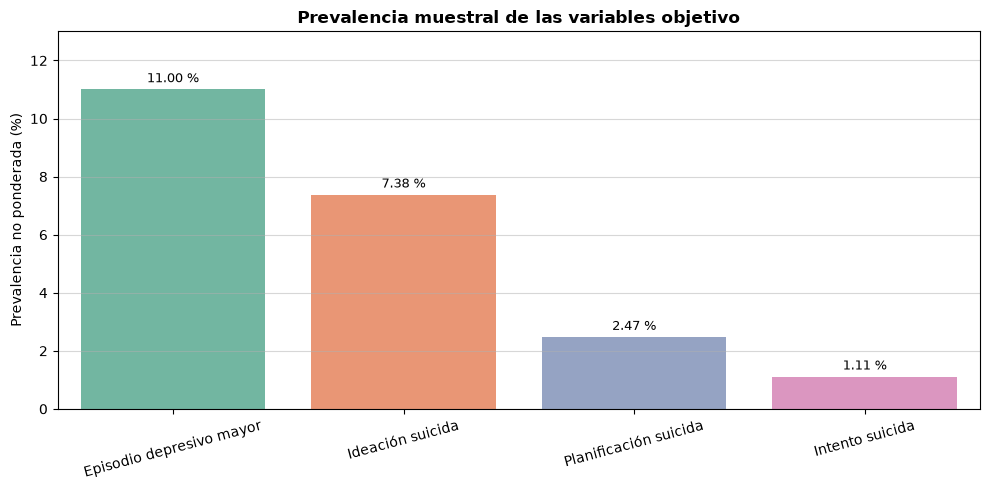

In [10]:
# =============================================================================
# DISTRIBUCIÓN DE LAS VARIABLES OBJETIVO
# =============================================================================
# Se representa la prevalencia positiva para comparar el desbalanceo de
# las cuatro variables objetivo.
df_plot_objetivos = resumen_targets[['variable', 'prevalencia_pct']].copy()
df_plot_objetivos['objetivo'] = df_plot_objetivos['variable'].map(titulos_targets)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_plot_objetivos, x='objetivo', y='prevalencia_pct', hue='objetivo',
    palette='Set2', legend=False, ax=ax
)

etiquetar_barras(ax, decimales=2, porcentaje=True)

ax.set_title('Prevalencia muestral de las variables objetivo', weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Prevalencia no ponderada (%)')
ax.set_ylim(0, df_plot_objetivos['prevalencia_pct'].max() + 2)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', visible=True, alpha=0.5)

_ = guardar_figura(fig, '01_distribucion_objetivos')

### Resultados

Las cuatro variables objetivo son binarias, no contienen valores físicamente ausentes en la población adulta y únicamente presentan los códigos `0` y `1`. Las prevalencias calculadas en este apartado son descriptivas y no ponderadas.

La clase positiva presenta un desbalanceo creciente: el episodio depresivo mayor alcanza el 11,00 %, la ideación suicida el 7,38 %, la planificación suicida el 2,47 % y el intento suicida el 1,11 %.

Este comportamiento condiciona la estrategia de evaluación posterior. `Accuracy` no será suficiente por sí sola y se complementará con `Recall`, `Precision`, `F1`, `F2`, `Balanced Accuracy`, `Average Precision`, `ROC-AUC` y `Especificidad`, prestando especial atención a la detección de la clase positiva.

**Clasificación:** MEMORIA. La distribución de las cuatro variables objetivo y su desbalanceo constituyen una característica central del problema predictivo.

## 2.3. Imputación de las variables objetivo

Las cuatro variables objetivo corresponden a versiones preparadas para análisis y disponen de un indicador asociado que permite identificar la procedencia de cada valor:

- `1`: valor obtenido del cuestionario.
- `3`: valor imputado estadísticamente.
- `9`: salto legítimo por edad, presente únicamente en menores.

En la población adulta se cuantifica la proporción de registros imputados y se compara la prevalencia de cada variable objetivo entre los valores procedentes del cuestionario y los valores imputados.

No se excluyen registros en esta fase. Los indicadores se conservarán como información auxiliar para permitir posteriormente un análisis de sensibilidad sobre la imputación.

**Fuente:** codebook oficial NSDUH 2024, apartados *Imputed Adult Mental Health* e *Imputed Adult Depression*.

In [11]:
# =============================================================================
# IMPUTACIÓN DE LAS VARIABLES OBJETIVO
# =============================================================================
# Se cuantifican los valores imputados y se compara la prevalencia de cada
# variable objetivo según la procedencia del valor.
pares_objetivo_imputacion = dict(zip(targets, indicadores_imputacion))
filas_imputacion = []

for target, indicador in pares_objetivo_imputacion.items():
    for codigo, procedencia in {1: 'Cuestionario', 3: 'Imputado'}.items():
        datos = df_adultos.loc[df_adultos[indicador].eq(codigo), target]

        filas_imputacion.append({
            'variable': target,
            'procedencia': procedencia,
            'registros': len(datos),
            'positivos': datos.eq(1).sum(),
            'prevalencia_pct': datos.eq(1).mean() * 100
        })

df_imputacion = pd.DataFrame(filas_imputacion)
df_imputacion['objetivo'] = df_imputacion['variable'].map(titulos_targets)

resumen_imputacion = df_imputacion.pivot(
    index='variable', columns='procedencia', values=['registros', 'prevalencia_pct']
)

resumen_imputacion.columns = ['_'.join(col).lower() for col in resumen_imputacion.columns]

resumen_imputacion = resumen_imputacion.reset_index().rename(columns={
    'registros_imputado': 'registros_imputados',
    'prevalencia_pct_cuestionario': 'prevalencia_cuestionario_pct',
    'prevalencia_pct_imputado': 'prevalencia_imputados_pct'
})

resumen_imputacion.insert(1, 'descripcion', resumen_imputacion['variable'].map(titulos_targets))

columnas_registros = ['registros_cuestionario', 'registros_imputados']
resumen_imputacion[columnas_registros] = resumen_imputacion[columnas_registros].astype('int64')

resumen_imputacion['pct_imputados'] = (
    resumen_imputacion['registros_imputados'] / len(df_adultos) * 100
)

resumen_imputacion['diferencia_pp'] = (
    resumen_imputacion['prevalencia_imputados_pct'] -
    resumen_imputacion['prevalencia_cuestionario_pct']
)

tabla_imputacion = preparar_tabla(resumen_imputacion, redondeo={
    'prevalencia_cuestionario_pct': 3, 'prevalencia_imputados_pct': 3, 'pct_imputados': 3,
    'diferencia_pp': 3
})

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('IMPUTACIÓN DE LAS VARIABLES OBJETIVO')
display(tabla_imputacion)

IMPUTACIÓN DE LAS VARIABLES OBJETIVO


,Variable,Descripción,Registros del cuestionario,Registros imputados,Prevalencia cuestionario (%),Prevalencia imputados (%),Registros imputados (%),Diferencia (pp)
0,IRAMDEYR,Episodio depresivo mayor,45659,1640,10.957,12.317,3.467,1.360
1,IRSUICTHNK,Ideación suicida,45906,1393,7.361,7.897,2.945,0.536
2,IRSUIPLANYR,Planificación suicida,45949,1350,2.483,2.148,2.854,-0.335
3,IRSUITRYYR,Intento suicida,45970,1329,1.103,1.354,2.810,0.252


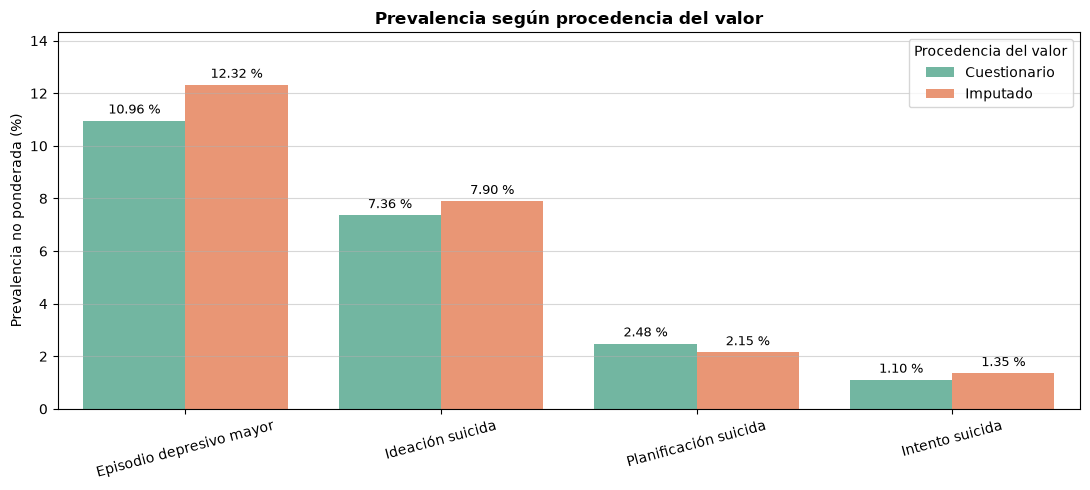

In [12]:
# =============================================================================
# DISTRIBUCIÓN SEGÚN PROCEDENCIA DEL VALOR
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=df_imputacion, x='objetivo', y='prevalencia_pct', hue='procedencia', palette='Set2', ax=ax
)

etiquetar_barras(ax, decimales=2, porcentaje=True)

ax.set_title('Prevalencia según procedencia del valor', weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Prevalencia no ponderada (%)')
ax.set_ylim(0, df_imputacion['prevalencia_pct'].max() + 2)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Procedencia del valor')
ax.grid(axis='x', visible=False)
ax.grid(axis='y', visible=True, alpha=0.5)

_ = guardar_figura(fig, '02_casos_positivos_procedencia')

### Resultados

Los valores imputados representan entre el 2,81 % y el 3,47 % de la población adulta, por lo que más del 96 % de los valores de cada variable objetivo procede directamente del cuestionario.

Las diferencias de prevalencia entre ambas procedencias son moderadas. La mayor se observa en el episodio depresivo mayor, con 1,36 puntos porcentuales más entre los registros imputados. En planificación suicida, por el contrario, la prevalencia de los valores imputados es 0,34 puntos inferior.

En esta fase se mantienen todos los registros. Los indicadores de imputación permiten distinguir la procedencia del valor y se conservarán como variables auxiliares para el análisis de sensibilidad posterior; no se utilizarán como variables de entrada del modelado.

**Clasificación:** ANEXO. El porcentaje de imputación se resumirá en la metodología de la memoria, pero la comparación detallada por variable objetivo puede mantenerse fuera del cuerpo principal.

## 2.4. Relación entre las variables objetivo

Finalmente se analiza cómo coexisten las cuatro variables objetivo dentro de la población adulta. Para ello se revisan las 16 combinaciones binarias posibles, el número de indicadores positivos por registro y la correlación entre las cuatro salidas.

Al tratarse de variables binarias, la correlación de Pearson coincide con el coeficiente phi y permite resumir su grado de asociación sin establecer causalidad.

Los patrones se representan en el orden depresión–ideación–planificación–intento (`D-I-P-A`) exclusivamente como convención gráfica. Este orden no implica una secuencia obligatoria, temporal ni causal.

RELACIÓN ENTRE VARIABLES OBJETIVO
Orden del patrón: Depresión-Ideación-Planificación-Intento



,Patrón,Frecuencia,Porcentaje (%)
0,0-0-0-0,40258,85.114
1,1-0-0-0,3437,7.267
2,0-1-0-0,1279,2.704
3,1-1-0-0,1058,2.237
4,1-1-1-0,431,0.911
5,0-1-1-0,247,0.522
6,1-1-1-1,210,0.444
7,0-1-1-1,201,0.425
8,0-0-1-0,44,0.093
9,1-1-0-1,38,0.080


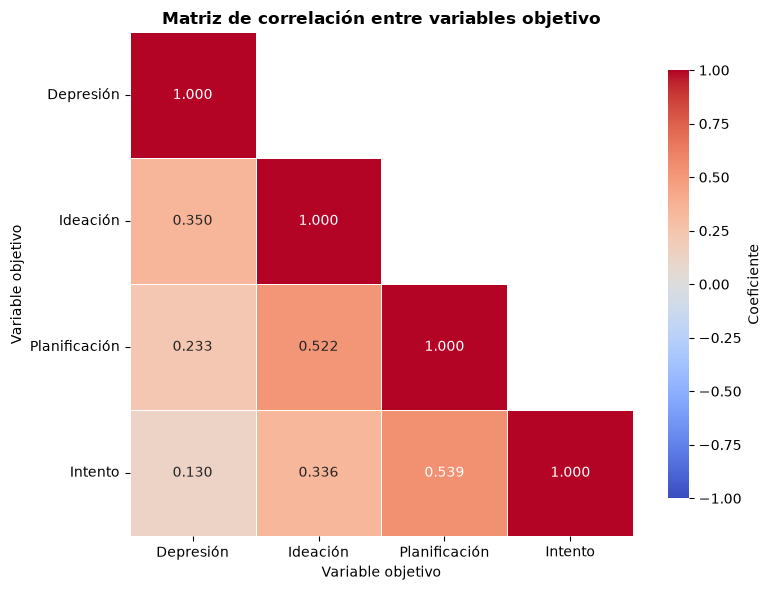

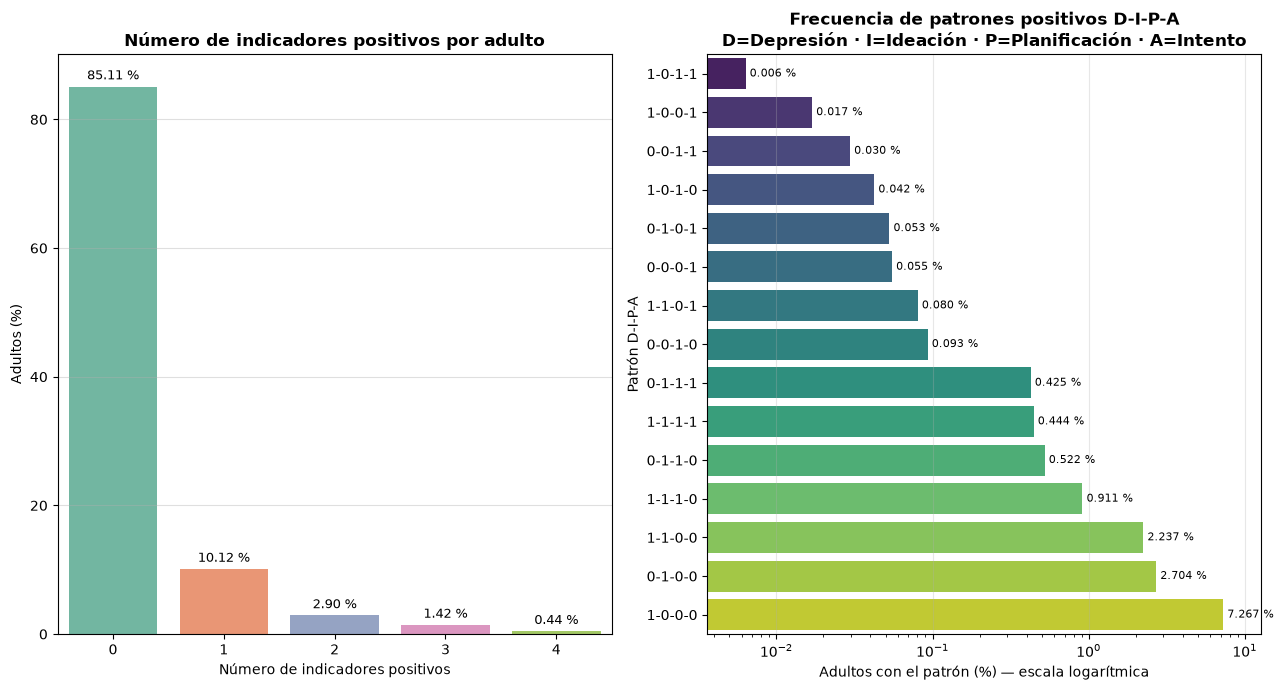

In [13]:
# =============================================================================
# RELACIÓN ENTRE LAS VARIABLES OBJETIVO
# =============================================================================
# Se revisan las combinaciones observadas y la asociación entre las cuatro
# variables objetivo, sin interpretar su orden como una progresión obligatoria.
resumen_combinaciones = (
    df_adultos[targets].astype(int).value_counts().rename('frecuencia').reset_index()
)

resumen_combinaciones['porcentaje'] = resumen_combinaciones['frecuencia'] / len(df_adultos) * 100

resumen_combinaciones['patron'] = resumen_combinaciones[targets].astype(str).agg('-'.join, axis=1)

resumen_combinaciones = resumen_combinaciones[['patron'] + targets + ['frecuencia', 'porcentaje']]

tabla_combinaciones = preparar_tabla(
    resumen_combinaciones, columnas=['patron', 'frecuencia', 'porcentaje'],
    redondeo={'porcentaje': 3}
)

corr_objetivos = df_adultos[targets].corr().rename(
    index=titulos_targets_red, columns=titulos_targets_red
)

print('RELACIÓN ENTRE VARIABLES OBJETIVO')
print('Orden del patrón: Depresión-Ideación-Planificación-Intento\n')
display(tabla_combinaciones)

matriz_correlacion(
    corr_objetivos, 'Matriz de correlación entre variables objetivo', '03_correlacion_objetivos',
    xlabel='Variable objetivo', ylabel='Variable objetivo', triangular=True
)

resumen_n_indicadores = (
    df_adultos[targets].sum(axis=1).value_counts().sort_index()
    .rename_axis('n_indicadores').reset_index(name='frecuencia')
)

resumen_n_indicadores['porcentaje'] = resumen_n_indicadores['frecuencia'] / len(df_adultos) * 100
resumen_n_indicadores['n_indicadores'] = (
    resumen_n_indicadores['n_indicadores'].astype(int).astype(str)
)

patrones_positivos = resumen_combinaciones.loc[
    resumen_combinaciones['patron'].ne('0-0-0-0'), ['patron', 'frecuencia', 'porcentaje']
].sort_values('porcentaje')

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

sns.barplot(
    data=resumen_n_indicadores, x='n_indicadores', y='porcentaje', hue='n_indicadores',
    palette='Set2', legend=False, ax=axes[0]
)

etiquetar_barras(axes[0], decimales=2, porcentaje=True)
axes[0].set_title('Número de indicadores positivos por adulto', weight='bold')
axes[0].set_xlabel('Número de indicadores positivos')
axes[0].set_ylabel('Adultos (%)')
axes[0].set_ylim(0, resumen_n_indicadores['porcentaje'].max() + 5)
axes[0].grid(axis='y', visible=True, alpha=0.4)

sns.barplot(
    data=patrones_positivos, y='patron', x='porcentaje', hue='patron', palette='viridis',
    legend=False, ax=axes[1]
)

etiquetar_barras(axes[1], decimales=3, porcentaje=True, fontsize=8)
axes[1].set_xscale('log')
axes[1].set_title(
    'Frecuencia de patrones positivos D-I-P-A\n'
    'D=Depresión · I=Ideación · P=Planificación · A=Intento', weight='bold'
)

axes[1].margins(x=0.08)
axes[1].set_xlabel('Adultos con el patrón (%) — escala logarítmica')
axes[1].set_ylabel('Patrón D-I-P-A')
axes[1].grid(axis='x', visible=True, alpha=0.3)

_ = guardar_figura(fig, '04_patrones_multisalida')

### Resultados

En la población adulta sin ponderar, el 85,11 % de los registros no presenta ninguno de los cuatro indicadores y el 14,89 % presenta al menos uno. El patrón positivo más frecuente es episodio depresivo mayor sin los otros tres indicadores (`1-0-0-0`), con un 7,27 %, seguido de ideación suicida aislada (`0-1-0-0`), con un 2,70 %, y de la coexistencia de episodio depresivo mayor e ideación (`1-1-0-0`), con un 2,24 %.

Las asociaciones más elevadas aparecen entre planificación e intento suicida (`0,539`) y entre ideación y planificación suicida (`0,522`). Entre los registros con intento suicida, aproximadamente el 90,29 % presenta también ideación y el 81,52 % planificación, mientras que el 49,33 % presenta episodio depresivo mayor.

Se observan las 16 combinaciones binarias posibles. Por tanto, el orden `D-I-P-A` se utiliza únicamente como convención de representación y no como una secuencia obligatoria, temporal o causal. Las cuatro variables se mantienen como salidas diferenciadas dentro del enfoque multisalida.

**Clasificación:** MEMORIA para la relación general entre las cuatro variables objetivo y la figura de patrones como candidata; ANEXO para la tabla completa de las 16 combinaciones y la matriz de correlación detallada.

## Síntesis de la sección 2 (memoria)

La población principal queda definida mediante `AGE3` entre `4` y `11`, obteniéndose 47.299 personas adultas y excluyéndose 11.334 menores de 18 años. En los menores, las cuatro variables objetivo se encuentran fuera de su universo de aplicación y sus indicadores de imputación registran el salto legítimo por edad.

En la población adulta, `IRAMDEYR`, `IRSUICTHNK`, `IRSUIPLANYR` e `IRSUITRYYR` son variables binarias completas. Sus prevalencias muestrales son, respectivamente, 11,00 %, 7,38 %, 2,47 % y 1,11 %, mostrando un desbalanceo creciente que deberá tenerse en cuenta en la evaluación predictiva. Entre el 2,81 % y el 3,47 % de sus valores procede de imputación estadística; estos registros se conservan y sus indicadores quedan reservados para el análisis de sensibilidad.

Las cuatro salidas están relacionadas, pero no forman una secuencia obligatoria: se observan las 16 combinaciones binarias posibles. Las asociaciones más altas corresponden a planificación–intento (`0,539`) e ideación–planificación (`0,522`). El orden depresión–ideación–planificación–intento se mantiene únicamente como convención de representación y no implica temporalidad ni causalidad.

**Tabla candidata:** prevalencias y procedencia de las cuatro variables objetivo.

**Figuras candidatas:** prevalencia muestral de las variables objetivo y patrones multisalida `D-I-P-A`.

**Destino:** MEMORIA + ANEXO.

# 3. Análisis y depuración estructural

Una vez definida la población adulta, se revisa la estructura de las 2.632 variables originales para identificar aquellas que han quedado sin datos o sin variabilidad. Estas situaciones pueden aparecer de forma natural cuando determinadas preguntas se dirigen exclusivamente a menores de edad.

La decisión de eliminación no se basa únicamente en esta comprobación estructural. Las variables identificadas se contrastarán también con los módulos oficiales del NSDUH para documentar su procedencia antes de crear la base de trabajo del EDA.

## 3.1. Análisis de la población adulta

Se revisan el número de valores distintos y la presencia de valores físicamente ausentes después de seleccionar la población adulta. Algunas variables dirigidas exclusivamente a menores pueden quedar completamente sin datos o presentar un único valor.

Esta revisión es diagnóstica. Las variables se mantendrán hasta comprobar también su significado, módulo y criterios de aplicación en la documentación oficial.

In [14]:
# =============================================================================
# ANÁLISIS DE LA POBLACIÓN ADULTA
# =============================================================================
# Se revisan los valores presentes, los valores distintos y los NaN físicos
# después de seleccionar la población adulta.
n_adultos = len(df_adultos)

resumen_adultos = pd.DataFrame({
    'tipo': df_adultos.dtypes.astype(str),
    'n_presentes': df_adultos.notna().sum(),
    'n_unicos': df_adultos.nunique(dropna=True),
    'n_nan': df_adultos.isna().sum(),
    'pct_nan': (df_adultos.isna().mean() * 100).round(3)
}).rename_axis('variable').reset_index()

variables_sin_datos = resumen_adultos.loc[resumen_adultos['n_presentes'].eq(0), 'variable'].tolist()

variables_constantes_adultos = resumen_adultos.loc[
    resumen_adultos['n_presentes'].gt(0) & resumen_adultos['n_unicos'].le(1), 'variable'
].tolist()

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_adultos, '02_resumen_variables_adultos')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('ANÁLISIS DE LA POBLACIÓN ADULTA')
print(f'Registros adultos: {n_adultos:,}')
print(f'Variables totales: {len(resumen_adultos):,}')
print(f'Variables con valores físicamente ausentes: {resumen_adultos["n_nan"].gt(0).sum():,}')
print(f'Variables sin datos: {len(variables_sin_datos):,}')
print(f'Variables constantes: {len(variables_constantes_adultos):,}')

ANÁLISIS DE LA POBLACIÓN ADULTA
Registros adultos: 47,299
Variables totales: 2,632
Variables con valores físicamente ausentes: 343
Variables sin datos: 80
Variables constantes: 159


### Resultados

Tras seleccionar la población adulta, 80 variables quedan completamente sin datos y 159 presentan un único valor. En ambos casos carecen de variabilidad útil para diferenciar registros dentro del análisis predictivo.

La mayoría parece corresponder a preguntas o indicadores destinados a población juvenil, aunque esta interpretación se contrastará en el apartado siguiente mediante la documentación oficial.

En este momento todavía no se elimina ninguna variable de `df_adultos`. Primero se registra la causa estructural de cada posible exclusión y posteriormente se comprueba el módulo al que pertenece.

**Clasificación:** ANEXO. La memoria puede indicar de forma resumida que se eliminaron variables sin datos o sin variabilidad después de seleccionar la población adulta.

## 3.2. Variables candidatas a eliminar

Se construye un registro único con las variables que han quedado completamente sin datos y con aquellas que presentan un único valor en la población adulta. En esta fase se conserva el motivo estructural de la posible eliminación, pero la decisión todavía no se considera definitiva.

El registro servirá como base para la revisión documental del apartado siguiente.

In [15]:
# =============================================================================
# VARIABLES CANDIDATAS A ELIMINAR
# =============================================================================
# Se registran las variables sin datos o constantes en población adulta.
# La decisión definitiva se realizará después de la revisión documental.

exclusiones_sin_datos = resumen_adultos.loc[
    resumen_adultos['variable'].isin(variables_sin_datos)
].copy()

exclusiones_sin_datos['motivo'] = 'Variable sin datos en población adulta'
exclusiones_sin_datos['valor_constante'] = None

exclusiones_constantes = resumen_adultos.loc[
    resumen_adultos['variable'].isin(variables_constantes_adultos)
].copy()

exclusiones_constantes['motivo'] = 'Variable constante en población adulta'
exclusiones_constantes['valor_constante'] = [
    df_adultos[variable].dropna().iloc[0] for variable in exclusiones_constantes['variable']
]

exclusiones_variables = pd.concat(
    [exclusiones_sin_datos, exclusiones_constantes], ignore_index=True
)

exclusiones_variables = exclusiones_variables[[
    'variable', 'tipo', 'n_presentes', 'n_unicos', 'n_nan', 'pct_nan', 'valor_constante', 'motivo'
]]

resumen_exclusiones = (
    exclusiones_variables['motivo'].value_counts()
    .rename_axis('motivo').reset_index(name='variables')
)

tabla_exclusiones = preparar_tabla(resumen_exclusiones)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VARIABLES CANDIDATAS A ELIMINAR')
print(f'Variables sin datos: {len(exclusiones_sin_datos):,}')
print(f'Variables constantes: {len(exclusiones_constantes):,}')
print(f'Total de variables candidatas: {len(exclusiones_variables):,}')

print('\nResumen por motivo:')
display(tabla_exclusiones)

VARIABLES CANDIDATAS A ELIMINAR
Variables sin datos: 80
Variables constantes: 159
Total de variables candidatas: 239

Resumen por motivo:


,Motivo,Variables
0,Variable constante en población adulta,159
1,Variable sin datos en población adulta,80


## 3.3. Clasificación de las variables candidatas

Las variables candidatas a eliminar se cruzan con el catálogo oficial de módulos del NSDUH 2024. Esta comprobación permite determinar de forma trazable si corresponden principalmente a preguntas juveniles o si existen variables procedentes de otros ámbitos del cuestionario.

La pertenencia a un módulo aporta contexto documental a la decisión estructural, pero no sustituye la revisión de los criterios de aplicación y de la codificación específica de cada variable.

In [16]:
# =============================================================================
# CLASIFICACIÓN DE LAS VARIABLES CANDIDATAS
# =============================================================================
# Se incorpora el módulo oficial de cada variable utilizando el fichero de comparabilidad incluido
# en la documentación.
with ZipFile(ruta_zip_doc) as archivo_zip:
    contenido_excel = archivo_zip.read('PUFComparability_2024.xlsx')

catalogo_variables = pd.read_excel(
    BytesIO(contenido_excel), sheet_name='Comparability', header=3
)
catalogo_variables = catalogo_variables[['VARIABLE', 'MODULE', 'NOTES']].rename(
    columns={'VARIABLE': 'variable', 'MODULE': 'modulo', 'NOTES': 'notas'}
)
catalogo_variables = catalogo_variables.dropna(subset=['variable']).drop_duplicates('variable')
catalogo_variables['variable'] = catalogo_variables['variable'].astype(str).str.strip()

exclusiones_variables = (
    exclusiones_variables.drop(columns=['modulo', 'notas'], errors='ignore')
    .merge(catalogo_variables, on='variable', how='left')
)

resumen_modulos_exclusion = (
    exclusiones_variables['modulo'].fillna('SIN MÓDULO').value_counts()
    .rename_axis('modulo').reset_index(name='variables')
)

tabla_modulos_exclusion = preparar_tabla(resumen_modulos_exclusion)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CLASIFICACIÓN DE LAS VARIABLES CANDIDATAS')
print(f'Variables clasificadas: {exclusiones_variables["modulo"].notna().sum():,}')
print(f'Variables sin módulo: {exclusiones_variables["modulo"].isna().sum():,}')

print('\nVariables candidatas por módulo:')
display(tabla_modulos_exclusion)

CLASIFICACIÓN DE LAS VARIABLES CANDIDATAS
Variables clasificadas: 239
Variables sin módulo: 0

Variables candidatas por módulo:


,Módulo,Variables
0,ADOLESCENT DEPRESSION,77
1,YOUTH EXPERIENCES,64
2,RECODED YOUTH EXPERIENCES,43
3,RECODED ADOLESCENT DEPRESSION,36
4,IMPUTED YOUTH EXPERIENCES,14
5,HOUSEHOLD COMPOSITION (ROSTER),2
6,IDENTIFICATION,1
7,SPECIAL TOPICS,1
8,RECODED DRUG USE,1


### Resultados

Las 239 variables candidatas pueden asociarse con un módulo oficial del NSDUH 2024. De ellas, 234 pertenecen a módulos de experiencias juveniles o depresión adolescente, incluidas sus versiones recodificadas e imputadas.

Las cinco variables restantes proceden de otros módulos, aunque también se encuentran completamente sin datos o presentan un único valor dentro de la población adulta. Su posible eliminación queda, por tanto, respaldada por su estructura en los datos y no únicamente por la temática a la que pertenecen.

La revisión documental confirma que la gran mayoría de las variables detectadas responde al cambio de población analizada y no a un problema general de calidad del fichero.

**Clasificación:** ANEXO. La memoria puede resumir que la mayor parte de las variables eliminadas corresponde a preguntas juveniles no aplicables a la población adulta.

## 3.4. Depuración de variables candidatas

Tras revisar la población adulta y clasificar las variables mediante los módulos oficiales del NSDUH, se eliminan de la base de trabajo las variables completamente sin datos o sin variabilidad.

`df_adultos` se conserva sin modificar como referencia y se crea `df_eda` para continuar el análisis exploratorio. Después de la eliminación se comprueba que no permanezcan variables sin datos ni constantes y que se conserven el identificador, la edad, el peso muestral, las variables del diseño de encuesta, las cuatro variables objetivo y sus indicadores de imputación.

In [17]:
# =============================================================================
# DEPURACIÓN DE VARIABLES CANDIDATAS
# =============================================================================
# Se eliminan de la base de trabajo las variables sin datos o constantes en población adulta.
# df_adultos se conserva sin modificar.
modulos_juveniles = [
    'ADOLESCENT DEPRESSION',
    'YOUTH EXPERIENCES',
    'RECODED YOUTH EXPERIENCES',
    'RECODED ADOLESCENT DEPRESSION',
    'IMPUTED YOUTH EXPERIENCES'
]

variables_excluir_eda = exclusiones_variables['variable'].tolist()

exclusiones_variables['decision'] = 'Eliminar'
exclusiones_variables['motivo_decision'] = 'Sin datos o constante en población adulta'

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(exclusiones_variables, '03_excluir_variables_adultos')

df_eda = df_adultos.drop(columns=variables_excluir_eda)

resumen_eda = resumen_adultos.loc[resumen_adultos['variable'].isin(df_eda.columns)].copy()

exclusiones_no_juveniles = exclusiones_variables.loc[
    ~exclusiones_variables['modulo'].isin(modulos_juveniles)
].copy()

tabla_exclusiones_no_juveniles = preparar_tabla(
    exclusiones_no_juveniles, columnas=['variable', 'modulo', 'motivo', 'valor_constante']
)

variables_principales = (
    ['QUESTID2', 'ANALWT2_C', 'VESTR_C', 'VEREP', 'AGE3'] + targets + indicadores_imputacion
)
variables_principales_faltantes = [v for v in variables_principales if v not in df_eda.columns]

if variables_principales_faltantes:
    raise ValueError(f'Variables principales eliminadas: {variables_principales_faltantes}')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('DEPURACIÓN DE VARIABLES CANDIDATAS')
print(f'Registros adultos: {df_adultos.shape[0]:,}')
print(f'Variables iniciales: {df_adultos.shape[1]:,}')
print(f'Variables eliminadas: {len(variables_excluir_eda):,}')
print(f'Variables finales: {df_eda.shape[1]:,}')
print(f'Variables sin datos restantes: {resumen_eda["n_presentes"].eq(0).sum():,}')
print('Variables constantes restantes:',
      f'{(resumen_eda["n_presentes"].gt(0) & resumen_eda["n_unicos"].le(1)).sum():,}')

print('\nVariables eliminadas de módulos no juveniles:')
display(tabla_exclusiones_no_juveniles)

print('\nComprobación de las principales variables:')
print(f'Variables principales conservadas: {len(variables_principales):,}')

DEPURACIÓN DE VARIABLES CANDIDATAS
Registros adultos: 47,299
Variables iniciales: 2,632
Variables eliminadas: 239
Variables finales: 2,393
Variables sin datos restantes: 0
Variables constantes restantes: 0

Variables eliminadas de módulos no juveniles:


,Variable,Módulo,Motivo,Valor constante
80,FILEDATE,IDENTIFICATION,Variable constante en población adulta,10/03/2025
81,IMOTHER,HOUSEHOLD COMPOSITION (ROSTER),Variable constante en población adulta,4
82,IFATHER,HOUSEHOLD COMPOSITION (ROSTER),Variable constante en población adulta,4
83,BKPOSTOB,SPECIAL TOPICS,Variable constante en población adulta,99
84,FUSEDNM18,RECODED DRUG USE,Variable constante en población adulta,2



Comprobación de las principales variables:
Variables principales conservadas: 13


### Resultados

Se eliminan 239 variables sin variabilidad útil dentro de la población adulta: 80 se encuentran completamente sin datos y 159 presentan un único valor. La mayor parte corresponde a módulos juveniles o de depresión adolescente.

Las cinco variables procedentes de otros módulos tampoco presentan variabilidad en adultos, por lo que su eliminación se justifica por su estructura en la población analizada y no por su contenido temático.

La base `df_eda` queda formada por 47.299 registros y 2.393 variables, sin variables completamente vacías ni constantes. Se conservan el identificador, la edad, el peso muestral, las variables del diseño de encuesta, las cuatro variables objetivo y sus indicadores de imputación.

Esta depuración no elimina registros ni aplica transformaciones aprendidas a partir de los datos. `df_adultos` se mantiene intacto como referencia de la población adulta antes de esta reducción estructural.

**Clasificación:** MEMORIA para el criterio general y la reducción de 2.632 a 2.393 variables; ANEXO para el listado completo de las 239 variables eliminadas.

## Síntesis de la sección 3 (memoria)

Tras restringir el análisis a población adulta, 239 variables dejan de aportar variabilidad: 80 quedan completamente sin datos y 159 presentan un único valor. La revisión documental muestra que 234 pertenecen a módulos juveniles o de depresión adolescente; las cinco restantes también carecen de variabilidad dentro de la población analizada.

La eliminación se aplica únicamente a estas variables y no a registros. `df_adultos` se conserva como referencia y la base de trabajo `df_eda` queda formada por 47.299 registros y 2.393 variables, manteniendo el identificador, la edad, el peso y las variables del diseño muestral, las cuatro variables objetivo y sus indicadores de imputación.

Esta depuración es estructural y no introduce transformaciones aprendidas ni utiliza información asociada al rendimiento predictivo.

**Tabla candidata:** resumen de la reducción de 2.632 a 2.393 variables.

**Figura candidata:** no.

**Destino:** MEMORIA + ANEXO.

# 4. Catálogo y revisión de variables

Una vez completada la depuración estructural, las 2.393 variables conservadas se organizan mediante la documentación oficial del NSDUH. El objetivo es identificar su rol dentro del proyecto, incorporar sus etiquetas y referencias de construcción y revisar especialmente aquellas relacionadas con las cuatro variables objetivo.

Esta fase permite separar variables de entrada, variables auxiliares y variables que podrían introducir fuga de información antes de continuar con la revisión funcional y estadística.

## 4.1. Clasificación de las variables restantes

Se construye un catálogo de las 2.393 variables conservadas incorporando su módulo oficial, número de valores distintos, presencia de valores físicamente ausentes y rol provisional dentro del proyecto.

Esta clasificación permite diferenciar el identificador, las variables del diseño muestral, la variable utilizada para seleccionar la población adulta, las cuatro variables objetivo, sus indicadores de imputación y las posibles variables de entrada.

In [18]:
# =============================================================================
# CLASIFICACIÓN DE LAS VARIABLES RESTANTES
# =============================================================================
# Se crea el catálogo de las variables conservadas en df_eda y se asigna un rol provisional
# a las variables principales.
catalogo_eda = resumen_eda.merge(
    catalogo_variables, on='variable', how='left', validate='one_to_one'
)
catalogo_eda['rol_provisional'] = 'Predictor candidato'
catalogo_eda.loc[catalogo_eda['variable'].eq('QUESTID2'), 'rol_provisional'] = 'Identificador'
catalogo_eda.loc[
    catalogo_eda['variable'].isin(variables_diseno), 'rol_provisional'
] = 'Diseño muestral'
catalogo_eda.loc[
    catalogo_eda['variable'].eq('AGE3'), 'rol_provisional'
] = 'Predictor demográfico y selección de población adulta'
catalogo_eda.loc[catalogo_eda['variable'].isin(targets), 'rol_provisional'] = 'Variable objetivo'
catalogo_eda.loc[
    catalogo_eda['variable'].isin(indicadores_imputacion), 'rol_provisional'
] = 'Indicador de imputación de variable objetivo'

n_variables_sin_modulo = catalogo_eda['modulo'].isna().sum()
catalogo_eda['modulo'] = catalogo_eda['modulo'].fillna('SIN MÓDULO')

resumen_roles_eda = catalogo_eda[
    'rol_provisional'
].value_counts().rename_axis('rol_provisional').reset_index(name='variables')

variables_principales_eda = catalogo_eda.loc[
    catalogo_eda['rol_provisional'].ne('Predictor candidato'),
    ['variable', 'modulo', 'rol_provisional', 'n_unicos', 'pct_nan']
].copy()

tabla_roles_eda = preparar_tabla(resumen_roles_eda)

tabla_variables_principales = preparar_tabla(variables_principales_eda, redondeo={'pct_nan': 3})

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CLASIFICACIÓN DE LAS VARIABLES RESTANTES')
print(f'Variables catalogadas: {len(catalogo_eda):,}')
print(f'Variables sin módulo oficial: {n_variables_sin_modulo:,}')

print('\nResumen por rol provisional:')
display(tabla_roles_eda)

print('\nVariables principales:')
display(tabla_variables_principales)

CLASIFICACIÓN DE LAS VARIABLES RESTANTES
Variables catalogadas: 2,393
Variables sin módulo oficial: 0

Resumen por rol provisional:


,Rol provisional,Variables
0,Predictor candidato,2380
1,Variable objetivo,4
2,Indicador de imputación de variable objetivo,4
3,Diseño muestral,3
4,Identificador,1
5,Predictor demográfico y selección de población...,1



Variables principales:


,Variable,Módulo,Rol provisional,Valores únicos,Valores físicamente ausentes (%)
0,QUESTID2,IDENTIFICATION,Identificador,47299,0.0
1,ANALWT2_C,SAMPLE WEIGHTING AND ESTIMATION VARS,Diseño muestral,47267,0.0
2,VESTR_C,SAMPLE WEIGHTING AND ESTIMATION VARS,Diseño muestral,50,0.0
3,VEREP,SAMPLE WEIGHTING AND ESTIMATION VARS,Diseño muestral,2,0.0
8,AGE3,DEMOGRAPHICS,Predictor demográfico y selección de población...,8,0.0
2035,IRSUICTHNK,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,2,0.0
2036,IISUICTHNK,IMPUTED ADULT MENTAL HEALTH,Indicador de imputación de variable objetivo,2,0.0
2037,IRSUIPLANYR,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,2,0.0
2038,IISUIPLANYR,IMPUTED ADULT MENTAL HEALTH,Indicador de imputación de variable objetivo,2,0.0
2039,IRSUITRYYR,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,2,0.0


### Resultados

Las 2.393 variables conservadas pueden asociarse con un módulo oficial, por lo que toda la base de trabajo mantiene trazabilidad documental.

De ellas, 2.380 reciben inicialmente el rol de predictor candidato y `AGE3` se conserva como predictor demográfico y como variable utilizada para seleccionar la población adulta. En conjunto existen 2.381 posibles variables de entrada antes de revisar fugas de información y posibles relaciones entre variables.

Esta clasificación todavía no implica su utilización definitiva. Deben revisarse especialmente las variables técnicas, las relacionadas con las variables objetivo, las diferentes versiones de una misma información y aquellas con una presencia elevada de valores físicamente ausentes.

Las cuatro variables objetivo, sus indicadores de imputación, el identificador y las variables del diseño muestral quedan diferenciadas desde el inicio del catálogo.

## 4.2. Diccionario documental de variables

El catálogo se completa con las etiquetas y referencias de construcción extraídas del codebook oficial. La búsqueda se realiza una única vez sobre todas las entradas del documento para evitar recorrer repetidamente el PDF.

Para cada variable se incorporan su etiqueta oficial y, cuando existe, la referencia a las variables o preguntas de origen. Los criterios de aplicación y los códigos especiales se revisarán posteriormente para las variables que continúen siendo candidatas a entrar en el modelado.

In [19]:
# =============================================================================
# DICCIONARIO DOCUMENTAL DE VARIABLES
# =============================================================================
# Se extraen una sola vez las entradas del codebook y se incorporan las etiquetas y referencias
# documentales al catálogo de variables.
nombre_codebook = 'nsduh-2024-ds0001-info-codebook_v1.pdf'

with ZipFile(ruta_zip_doc) as archivo_zip:
    lector_codebook = PdfReader(BytesIO(archivo_zip.read(nombre_codebook)))

texto_codebook = '\n'.join(pagina.extract_text() or '' for pagina in lector_codebook.pages)

patron_entrada = re.compile(r'(?m)^([A-Z][A-Z0-9_]*)\s*(?:1\s*)?Len\s*:\s*\d+\s+(.+?)\s*$')

coincidencias = list(patron_entrada.finditer(texto_codebook))

if len(coincidencias) != len({coincide.group(1) for coincide in coincidencias}):
    raise ValueError('Se han detectado entradas duplicadas en el codebook')

variables_fichero = set(df.columns)
filas_codebook = []

for i, coincide in enumerate(coincidencias):
    variable_extraida = coincide.group(1).strip()

    # En algunas entradas, la extracción del PDF añade un marcador "1" al
    # nombre de la variable.
    if variable_extraida in variables_fichero:
        variable = variable_extraida
    elif variable_extraida.endswith('1') and variable_extraida[:-1] in variables_fichero:
        variable = variable_extraida[:-1]
    else:
        variable = variable_extraida

    inicio = coincidencias[i - 1].end() if i else max(0, coincide.start() - 1500)
    texto_previo = texto_codebook[inicio:coincide.start()]

    referencias = re.findall(
        r'(?m)^\(([A-Z][A-Z0-9_]*(?:\s*,\s*[A-Z][A-Z0-9_]*)*)\)\s*$', texto_previo
    )

    ref_fuente = referencias[-1].replace('\n', ' ') if referencias else ''
    ref_fuente = ', '.join(
        referencia.strip() for referencia in ref_fuente.split(',') if referencia.strip()
    )

    filas_codebook.append({
        'variable': variable,
        'etiqueta_codebook': coincide.group(2).strip(),
        'ref_fuente': ref_fuente,
        'n_ref': len(ref_fuente.split(', ')) if ref_fuente else 0
    })

diccionario_codebook = pd.DataFrame(filas_codebook)

variables_duplicadas = diccionario_codebook.loc[
    diccionario_codebook['variable'].duplicated(keep=False), 'variable'
].unique().tolist()

variables_no_documentadas = sorted(variables_fichero.difference(diccionario_codebook['variable']))

variables_ajenas_fichero = sorted(
    set(diccionario_codebook['variable']).difference(variables_fichero)
)

if variables_duplicadas:
    raise ValueError(
        f'Variables duplicadas tras normalizar el codebook: {variables_duplicadas[:10]}'
    )

if variables_no_documentadas or variables_ajenas_fichero:
    raise ValueError(
        f'Variables del fichero no documentadas: {len(variables_no_documentadas)}\n'
        f'Entradas ajenas al fichero: {len(variables_ajenas_fichero)}'
    )

catalogo_eda = catalogo_eda.drop(
    columns=['etiqueta_codebook', 'ref_fuente', 'n_ref', 'documentada_codebook', 'tipo_version'],
    errors='ignore'
).merge(diccionario_codebook, on='variable', how='left', validate='one_to_one')
catalogo_eda['documentada_codebook'] = catalogo_eda['etiqueta_codebook'].notna()
catalogo_eda['ref_fuente'] = catalogo_eda['ref_fuente'].fillna('')
catalogo_eda['n_ref'] = catalogo_eda['n_ref'].fillna(0).astype(int)
catalogo_eda['tipo_version'] = np.select(
    [
        catalogo_eda['modulo'].str.contains('IMPUTED', case=False),
        catalogo_eda['modulo'].str.contains('RECODED', case=False)
    ],
    ['Imputada', 'Recodificada'], default='Original u otra'
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(catalogo_eda, '04_catalogo_variables_eda')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('DICCIONARIO DOCUMENTAL DE VARIABLES')
print(f'Entradas localizadas en el codebook: {len(diccionario_codebook):,}')
print(f'Variables conservadas: {len(catalogo_eda):,}')
print(f'Variables documentadas: {catalogo_eda["documentada_codebook"].sum():,}')
print(f'Variables no localizadas: {(~catalogo_eda["documentada_codebook"]).sum():,}')
print(f'Variables con referencias documentales: {catalogo_eda["n_ref"].gt(0).sum():,}')

DICCIONARIO DOCUMENTAL DE VARIABLES
Entradas localizadas en el codebook: 2,632
Variables conservadas: 2,393
Variables documentadas: 2,393
Variables no localizadas: 0
Variables con referencias documentales: 2,199


### Resultados

Las 2.632 variables del fichero original pueden asociarse con una entrada del codebook oficial. Después de la depuración estructural, las 2.393 variables conservadas disponen de etiqueta documental y ninguna queda sin identificar.

Un total de 2.199 variables presenta referencias explícitas a preguntas o variables de origen. Las restantes no deben interpretarse como variables sin documentación: se trata principalmente de variables primarias o de entradas para las que el codebook no incorpora una referencia de construcción entre paréntesis.

El catálogo resultante permite continuar la revisión de códigos especiales, versiones analíticas y relaciones documentadas entre variables.

## 4.3. Análisis de módulos

Se resume la estructura de cada módulo oficial mediante el número de variables, la presencia de valores físicamente ausentes y el número de valores distintos. También se diferencian los módulos originales, recodificados e imputados.

Los módulos relacionados directamente con depresión y salud mental adulta se señalan para una revisión específica, ya que pueden contener variables utilizadas para construir alguna de las cuatro salidas, variables derivadas o información estrechamente relacionada con ellas.

In [20]:
# =============================================================================
# ANÁLISIS DE MÓDULOS
# =============================================================================
# Se analiza la composición, la presencia de NaN físicos y el posible vínculo de cada módulo
# con las variables objetivo.
analisis_modulos = catalogo_eda.groupby('modulo', as_index=False).agg(
    variables=('variable', 'size'),
    predictores=('rol_provisional', lambda x: x.str.startswith('Predictor').sum()),
    pct_nan_medio=('pct_nan', 'mean'),
    pct_nan_mediana=('pct_nan', 'median'),
    pct_nan_max=('pct_nan', 'max'),
    vars_sin_nan=('pct_nan', lambda x: x.eq(0).sum()),
    vars_nan_90=('pct_nan', lambda x: x.ge(90).sum()),
    mediana_valores_unicos=('n_unicos', 'median')
)

columnas_redondear = [
    'pct_nan_medio', 'pct_nan_mediana', 'pct_nan_max', 'mediana_valores_unicos'
]

analisis_modulos[columnas_redondear] = analisis_modulos[columnas_redondear].round(3)
analisis_modulos['tipo_modulo'] = np.select(
    [
        analisis_modulos['modulo'].str.contains('IMPUTED', case=False),
        analisis_modulos['modulo'].str.contains('RECODED', case=False)
    ],
    ['Imputado', 'Recodificado'], default='Original u otro'
)

analisis_modulos['revision_objetivos'] = analisis_modulos['modulo'].str.contains(
    r'ADULT DEPRESSION|ADULT MENTAL HEALTH', case=False, regex=True
)

analisis_modulos = analisis_modulos.sort_values(
    ['revision_objetivos', 'variables'], ascending=[False, False]
).reset_index(drop=True)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(analisis_modulos, '05_analisis_modulos_inicial')

resumen_tipos_modulo = analisis_modulos[
    'tipo_modulo'
].value_counts().rename_axis('tipo_modulo').reset_index(name='modulos')

modulos_relacionados_objetivos = analisis_modulos.loc[
    analisis_modulos['revision_objetivos']
].drop(columns='revision_objetivos')

modulos_nan_alto = analisis_modulos.loc[
    analisis_modulos['vars_nan_90'].gt(0)
].sort_values(['vars_nan_90', 'variables'], ascending=False).drop(columns='revision_objetivos')

tabla_tipos_modulo = preparar_tabla(resumen_tipos_modulo)
tabla_modulos_objetivos = preparar_tabla(modulos_relacionados_objetivos)
tabla_modulos_nan_alto = preparar_tabla(modulos_nan_alto)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('ANÁLISIS DE MÓDULOS')
print(f'Módulos oficiales: {len(analisis_modulos):,}')

print('\nTipos de módulo:')
display(tabla_tipos_modulo)

print('\nMódulos relacionados directamente con las variables objetivo:')
display(tabla_modulos_objetivos)

print('\nMódulos con variables que superan el 90 % de valores físicamente ausentes:')
display(tabla_modulos_nan_alto)

ANÁLISIS DE MÓDULOS
Módulos oficiales: 79

Tipos de módulo:


,Tipo de módulo,Módulos
0,Original u otro,50
1,Recodificado,16
2,Imputado,13



Módulos relacionados directamente con las variables objetivo:


,Módulo,Variables,Predictores,Media de valores físicamente ausentes (%),Mediana de valores físicamente ausentes (%),Máximo de valores físicamente ausentes (%),Variables sin valores físicamente ausentes,Variables con ≥ 90 % de valores físicamente ausentes,Mediana de valores únicos,Tipo de módulo
0,ADULT DEPRESSION,84,84,4.379,0.000,89.408,77,0,6.0,Original u otro
1,IMPUTED ADULT MENTAL HEALTH,72,66,0.000,0.000,0.000,72,0,3.0,Imputado
2,ADULT MENTAL HEALTH,43,43,1.860,0.000,67.636,38,0,9.0,Original u otro
3,RECODED ADULT MENTAL HEALTH,28,28,2.377,0.000,66.568,27,0,2.5,Recodificado
4,RECODED ADULT DEPRESSION,15,15,80.372,80.376,80.376,0,0,2.0,Recodificado
5,IMPUTED ADULT DEPRESSION,6,4,0.000,0.000,0.000,6,0,2.0,Imputado



Módulos con variables que superan el 90 % de valores físicamente ausentes:


,Módulo,Variables,Predictores,Media de valores físicamente ausentes (%),Mediana de valores físicamente ausentes (%),Máximo de valores físicamente ausentes (%),Variables sin valores físicamente ausentes,Variables con ≥ 90 % de valores físicamente ausentes,Mediana de valores únicos,Tipo de módulo
12,RECODED ALCOHOL AND DRUG TREATMENT,50,50,35.776,0.000,99.104,29,18,2.0,Recodificado
25,RECODED MENTAL HEALTH SERVICES UTILIZATION,31,31,56.899,94.782,95.336,11,18,2.0,Recodificado
7,RECODED DRUG USE,327,327,4.628,0.000,99.884,224,13,2.0,Recodificado
32,RECODED CONSUMPTION OF ALCOHOL,24,24,32.591,0.274,97.319,0,8,2.0,Recodificado
72,INTERVIEW INFORMATION,2,2,49.752,49.752,99.505,1,1,2.0,Original u otro


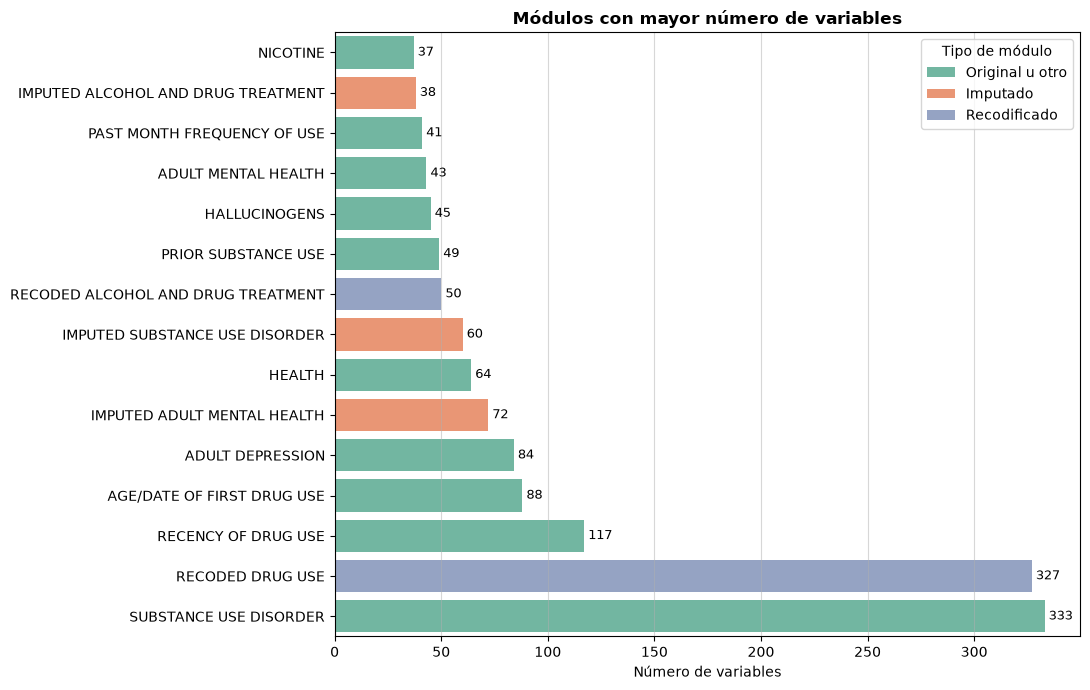

In [21]:
# =============================================================================
# MÓDULOS CON MAYOR NÚMERO DE VARIABLES
# =============================================================================
modulos_grafico = analisis_modulos.nlargest(15, 'variables').sort_values('variables').copy()

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=modulos_grafico, x='variables', y='modulo', hue='tipo_modulo', dodge=False, palette='Set2',
    ax=ax
)

etiquetar_barras(ax, decimales=0, ocultar_ceros=True)
ax.set_title('Módulos con mayor número de variables', weight='bold')
ax.set_xlabel('Número de variables')
ax.set_ylabel('')
ax.legend(title='Tipo de módulo')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True, alpha=0.5)

_ = guardar_figura(fig, '05_variables_por_modulo')

### Resultados

Las 2.393 variables se distribuyen entre 79 módulos oficiales: 50 originales o de otro tipo, 16 recodificados y 13 imputados.

La mayoría de los módulos presenta pocos valores físicamente ausentes. Las variables que superan el 90 % de ausencia física se concentran en cinco módulos relacionados con tratamiento, utilización de servicios, consumo de sustancias e información de la entrevista. Estas ausencias pueden responder al flujo del cuestionario, por lo que no justifican una eliminación automática.

Los seis módulos directamente relacionados con depresión y salud mental adulta contienen 248 variables, de las cuales 240 figuran todavía como predictores candidatos. Requieren una revisión específica porque pueden incluir preguntas utilizadas para construir las variables objetivo, versiones recodificadas o resultados posteriores relacionados con ellas.

Destaca `RECODED ADULT DEPRESSION`, cuyas 15 variables presentan aproximadamente un 80 % de valores físicamente ausentes. Sus criterios de aplicación y significado deberán comprobarse antes de adoptar una decisión.

En esta fase no se eliminan nuevas variables.

## 4.4. Variables relacionadas con las variables objetivo

Se aíslan las variables pertenecientes a los módulos directamente relacionados con depresión y salud mental adulta. Las variables objetivo y sus indicadores de imputación mantienen su función conocida, mientras que las restantes se reservan para una revisión documental prioritaria.

La pertenencia a estos módulos no implica por sí sola fuga de información. El paso siguiente consiste en comprobar cuáles intervienen directa o indirectamente en la construcción de alguna variable objetivo y cuáles se generan posteriormente a partir de ellas.

In [22]:
# =============================================================================
# VARIABLES RELACIONADAS CON LAS VARIABLES OBJETIVO
# =============================================================================
# Se identifican las variables de los módulos directamente relacionados con las variables objetivo
# para revisar posibles fugas de información.
modulos_objetivos = analisis_modulos.loc[analisis_modulos['revision_objetivos'], 'modulo'].tolist()

variables_relacionadas_objetivos = catalogo_eda.loc[
    catalogo_eda['modulo'].isin(modulos_objetivos)
].copy()

resumen_variables_objetivos = variables_relacionadas_objetivos.groupby(
    ['modulo', 'tipo_version'], as_index=False
).agg(
    variables=('variable', 'size'),
    predictores=('rol_provisional', lambda x: x.eq('Predictor candidato').sum()),
    variables_objetivo=('rol_provisional', lambda x: x.eq('Variable objetivo').sum()),
    indicadores_imputacion=(
        'rol_provisional', lambda x: x.eq('Indicador de imputación de variable objetivo').sum()
    ),
    pct_nan_mediana=('pct_nan', 'median'),
    pct_nan_max=('pct_nan', 'max')
)

resumen_variables_objetivos[['pct_nan_mediana', 'pct_nan_max']] = (
    resumen_variables_objetivos[['pct_nan_mediana', 'pct_nan_max']].round(3)
)

objetivos_indicadores = variables_relacionadas_objetivos.loc[
    variables_relacionadas_objetivos['rol_provisional'].ne('Predictor candidato'),
    ['variable', 'modulo', 'rol_provisional', 'tipo_version', 'n_unicos', 'pct_nan']
].copy()

tabla_resumen_objetivos = preparar_tabla(resumen_variables_objetivos)

tabla_objetivos_indicadores = preparar_tabla(objetivos_indicadores, redondeo={'pct_nan': 3})

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VARIABLES RELACIONADAS CON LAS VARIABLES OBJETIVO')
print(f'Módulos revisados: {len(modulos_objetivos):,}')
print(f'Variables totales: {len(variables_relacionadas_objetivos):,}')
print(
    'Predictores pendientes de revisión:',
    f'{variables_relacionadas_objetivos["rol_provisional"].eq("Predictor candidato").sum():,}'
)

print('\nResumen por módulo:')
display(tabla_resumen_objetivos)

print('\nVariables objetivo e indicadores identificados:')
display(tabla_objetivos_indicadores)

VARIABLES RELACIONADAS CON LAS VARIABLES OBJETIVO
Módulos revisados: 6
Variables totales: 248
Predictores pendientes de revisión: 240

Resumen por módulo:


,Módulo,Tipo de versión,Variables,Predictores,Variables objetivo,Indicadores de imputación,Mediana de valores físicamente ausentes (%),Máximo de valores físicamente ausentes (%)
0,ADULT DEPRESSION,Original u otra,84,84,0,0,0.000,89.408
1,ADULT MENTAL HEALTH,Original u otra,43,43,0,0,0.000,67.636
2,IMPUTED ADULT DEPRESSION,Imputada,6,4,1,1,0.000,0.000
3,IMPUTED ADULT MENTAL HEALTH,Imputada,72,66,3,3,0.000,0.000
4,RECODED ADULT DEPRESSION,Recodificada,15,15,0,0,80.376,80.376
5,RECODED ADULT MENTAL HEALTH,Recodificada,28,28,0,0,0.000,66.568



Variables objetivo e indicadores identificados:


,Variable,Módulo,Rol provisional,Tipo de versión,Valores únicos,Valores físicamente ausentes (%)
2035,IRSUICTHNK,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,Imputada,2,0.0
2036,IISUICTHNK,IMPUTED ADULT MENTAL HEALTH,Indicador de imputación de variable objetivo,Imputada,2,0.0
2037,IRSUIPLANYR,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,Imputada,2,0.0
2038,IISUIPLANYR,IMPUTED ADULT MENTAL HEALTH,Indicador de imputación de variable objetivo,Imputada,2,0.0
2039,IRSUITRYYR,IMPUTED ADULT MENTAL HEALTH,Variable objetivo,Imputada,2,0.0
2040,IISUITRYYR,IMPUTED ADULT MENTAL HEALTH,Indicador de imputación de variable objetivo,Imputada,2,0.0
2169,IRAMDEYR,IMPUTED ADULT DEPRESSION,Variable objetivo,Imputada,2,0.0
2170,IIAMDEYR,IMPUTED ADULT DEPRESSION,Indicador de imputación de variable objetivo,Imputada,2,0.0


### Resultados

Se identifican 248 variables pertenecientes a los módulos directamente relacionados con depresión y salud mental adulta. Ocho corresponden a las cuatro variables objetivo y sus indicadores de imputación, mientras que 240 permanecen inicialmente como predictores candidatos.

La pertenencia a estos módulos no confirma por sí sola una fuga de información. En ellos conviven síntomas generales, escalas de malestar psicológico, variables utilizadas para construir las salidas, versiones imputadas, recodificaciones y resultados posteriores.

La revisión siguiente se realiza a nivel de variable mediante las etiquetas y referencias documentales del codebook.

## 4.5. Dependencias documentales de las variables objetivo

A partir de las referencias extraídas del codebook se realizan dos recorridos:

- variables utilizadas directa o indirectamente para construir cada variable objetivo;
- variables generadas posteriormente a partir de alguna de ellas.

Ambos grupos pueden introducir fuga de información. En esta fase únicamente se identifican y documentan las relaciones; la decisión de exclusión se consolida después de revisar los resultados.

In [23]:
# =============================================================================
# DEPENDENCIAS DOCUMENTALES DE LAS VARIABLES OBJETIVO
# =============================================================================
# Se recorren las referencias del codebook para identificar variables de origen
# y variables derivadas relacionadas con las variables objetivo.
mapa_referencias = dict(zip(
    variables_relacionadas_objetivos['variable'],
    variables_relacionadas_objetivos['ref_fuente'].apply(separar_referencias)
))

mapa_dependencias = {}

for variable, referencias in mapa_referencias.items():
    for referencia in referencias:
        mapa_dependencias.setdefault(referencia, []).append(variable)

filas_dependencias = []

for objetivo in targets:
    for variable, nivel in recorrer_grafo(objetivo, mapa_referencias).items():
        filas_dependencias.append({
            'variable_objetivo': objetivo,
            'variable_vinculada': variable,
            'tipo_vinculo': 'Variable de origen',
            'nivel': nivel
        })

    for variable, nivel in recorrer_grafo(objetivo, mapa_dependencias).items():
        filas_dependencias.append({
            'variable_objetivo': objetivo,
            'variable_vinculada': variable,
            'tipo_vinculo': 'Variable derivada',
            'nivel': nivel
        })

columnas_dependencias = [
    'variable_objetivo',
    'variable_vinculada',
    'tipo_vinculo',
    'nivel'
]

dependencias_objetivos = pd.DataFrame(filas_dependencias, columns=columnas_dependencias)

if dependencias_objetivos.empty:
    raise ValueError('No se han generado dependencias.')

dependencias_objetivos = dependencias_objetivos.drop_duplicates(
    ['variable_objetivo', 'variable_vinculada', 'tipo_vinculo']
)

metadatos_variables = catalogo_eda[[
    'variable',
    'modulo',
    'rol_provisional',
    'n_unicos',
    'pct_nan',
    'etiqueta_codebook'
]].copy()

dependencias_objetivos = dependencias_objetivos.merge(
    metadatos_variables, left_on='variable_vinculada', right_on='variable', how='left',
    validate='many_to_one'
).drop(columns='variable')

dependencias_objetivos['presente_eda'] = (
    dependencias_objetivos['variable_vinculada'].isin(df_eda.columns)
)

dependencias_objetivos['predictor_candidato'] = (
    dependencias_objetivos['rol_provisional'].eq('Predictor candidato')
)

dependencias_objetivos = dependencias_objetivos.sort_values([
    'variable_objetivo', 'tipo_vinculo', 'nivel', 'variable_vinculada'
]).reset_index(drop=True)

resumen_dependencias = dependencias_objetivos.groupby(
    ['variable_objetivo', 'tipo_vinculo'], as_index=False
).agg(
    variables=('variable_vinculada', 'nunique'),
    presentes_eda=('presente_eda', 'sum'),
    predictores_candidatos=('predictor_candidato', 'sum'),
    nivel_maximo=('nivel', 'max')
)

variables_revision_dependencias = sorted(
    dependencias_objetivos.loc[
        dependencias_objetivos['presente_eda'] & dependencias_objetivos['predictor_candidato'],
        'variable_vinculada'
    ].unique()
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(dependencias_objetivos, '06_dependencias_variables_objetivo')

dependencias_directas = dependencias_objetivos.loc[
    dependencias_objetivos['presente_eda'] & dependencias_objetivos['nivel'].eq(1),
    [
        'variable_objetivo', 'variable_vinculada', 'tipo_vinculo', 'modulo', 'rol_provisional',
        'etiqueta_codebook'
    ]
].copy()

tabla_resumen_dependencias = preparar_tabla(resumen_dependencias)
tabla_dependencias_directas = preparar_tabla(dependencias_directas)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('DEPENDENCIAS DOCUMENTALES DE LAS VARIABLES OBJETIVO')
print(f'Vínculos identificados: {len(dependencias_objetivos):,}')
print(f'Variables únicas vinculadas: {dependencias_objetivos["variable_vinculada"].nunique():,}')
print(f'Predictores candidatos para revisión: {len(variables_revision_dependencias):,}')

print('\nResumen de dependencias por variable objetivo:')
display(tabla_resumen_dependencias)

print('\nDependencias directas presentes en el EDA:')
display(tabla_dependencias_directas)

DEPENDENCIAS DOCUMENTALES DE LAS VARIABLES OBJETIVO
Vínculos identificados: 66
Variables únicas vinculadas: 47
Predictores candidatos para revisión: 33

Resumen de dependencias por variable objetivo:


,Variable objetivo,Tipo de vínculo,Variables,Presentes en el EDA,Predictores candidatos,Nivel máximo
0,IRAMDEYR,Variable de origen,26,14,14,4
1,IRAMDEYR,Variable derivada,15,15,15,5
2,IRSUICTHNK,Variable de origen,2,1,1,2
3,IRSUICTHNK,Variable derivada,17,17,17,5
4,IRSUIPLANYR,Variable de origen,2,1,1,2
5,IRSUIPLANYR,Variable derivada,2,2,2,1
6,IRSUITRYYR,Variable derivada,2,2,2,1



Dependencias directas presentes en el EDA:


,Variable objetivo,Variable vinculada,Tipo de vínculo,Módulo,Rol provisional,Etiqueta del codebook
0,IRAMDEYR,AMDEYR,Variable de origen,ADULT DEPRESSION,Predictor candidato,ADULT: PAST YEAR MAJOR DEPRESSIVE EPISODE (MDE)
26,IRAMDEYR,SMIPPPY,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,RC-IMP PREDICTED SERIOUS MENTAL ILLNESS PROB PY
41,IRSUICTHNK,SUICTHNK,Variable de origen,ADULT MENTAL HEALTH,Predictor candidato,SERIOUSLY THINK ABOUT KILLING SELF PST 12 MOS
43,IRSUICTHNK,ADSUITPACOM,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,RC-ADULT PY SUICIDE THOUGHTS/PLANS/ATTEMPTS CO...
44,IRSUICTHNK,ADSUITPAYR,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,"RC-ADULT THOUGHT ABOUT, PLANNED, OR ATTEMPTED ..."
45,IRSUICTHNK,SMIPPPY,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,RC-IMP PREDICTED SERIOUS MENTAL ILLNESS PROB PY
60,IRSUIPLANYR,SUIPLANYR,Variable de origen,ADULT MENTAL HEALTH,Predictor candidato,ADULT MAKE PLANS TO KILL SELF PST 12 MOS
62,IRSUIPLANYR,ADSUITPACOM,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,RC-ADULT PY SUICIDE THOUGHTS/PLANS/ATTEMPTS CO...
63,IRSUIPLANYR,ADSUITPAYR,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,"RC-ADULT THOUGHT ABOUT, PLANNED, OR ATTEMPTED ..."
64,IRSUITRYYR,ADSUITPACOM,Variable derivada,RECODED ADULT MENTAL HEALTH,Predictor candidato,RC-ADULT PY SUICIDE THOUGHTS/PLANS/ATTEMPTS CO...


### Resultados

El recorrido documental identifica 66 vínculos de origen o derivación, correspondientes a 47 variables diferentes. De ellas, 33 continúan figurando como predictores candidatos y requieren revisión por posible fuga de información.

La cadena documental más extensa corresponde al episodio depresivo mayor, cuya construcción utiliza varios criterios y variables intermedias. Para ideación y planificación suicida también se localizan sus fuentes originales y distintas recodificaciones posteriores.

`IRSUITRYYR` y `IISUITRYYR` no contienen una referencia explícita entre paréntesis en su entrada del codebook. El recorrido automático debe interpretarse, por tanto, como una detección de relaciones documentadas y no como un inventario necesariamente exhaustivo.

## 4.6. Validación de las fuentes directas de las variables objetivo

Se comprueba la correspondencia entre las variables objetivo imputadas y sus variables originales cuando el indicador de imputación señala que el valor procede directamente del cuestionario.

Esta comprobación permite verificar empíricamente qué variables reproducen una salida y confirmar que deben mantenerse fuera de las variables de entrada.

In [24]:
# =============================================================================
# VALIDACIÓN DE LAS FUENTES DIRECTAS DE LAS VARIABLES OBJETIVO
# =============================================================================
# Se comprueba la relación entre las variables objetivo imputadas y sus fuentes originales cuando
# el indicador señala un valor procedente del cuestionario.
fuentes_objetivos = {
    'IRAMDEYR': ('AMDEYR', 'IIAMDEYR'),
    'IRSUICTHNK': ('SUICTHNK', 'IISUICTHNK'),
    'IRSUIPLANYR': ('SUIPLANYR', 'IISUIPLANYR')
}

filas_validacion = []

for objetivo, (fuente, indicador) in fuentes_objetivos.items():
    mascara = df_eda[indicador].eq(1) & df_eda[fuente].isin([1, 2])

    fuente_binaria = df_eda.loc[mascara, fuente].map({1: 1, 2: 0})
    objetivo_binario = df_eda.loc[mascara, objetivo]

    filas_validacion.append({
        'variable_objetivo': objetivo,
        'descripcion': titulos_targets[objetivo],
        'fuente_directa': fuente,
        'indicador': indicador,
        'casos_cuestionario_validos': mascara.sum(),
        'coincidencias': objetivo_binario.eq(fuente_binaria).sum(),
        'diferencias': objetivo_binario.ne(fuente_binaria).sum(),
        'pct_coincidencia': objetivo_binario.eq(fuente_binaria).mean() * 100
    })

validacion_fuentes = pd.DataFrame(filas_validacion)

validacion_fuentes = pd.concat(
    [
        validacion_fuentes, pd.DataFrame([{
            'variable_objetivo': 'IRSUITRYYR',
            'descripcion': titulos_targets['IRSUITRYYR'],
            'fuente_directa': 'SUI03 (ítem cuestionario)',
            'indicador': 'IISUITRYYR',
            'casos_cuestionario_validos': np.nan,
            'coincidencias': np.nan,
            'diferencias': np.nan,
            'pct_coincidencia': np.nan
        }])
    ], ignore_index=True
)

columnas_conteos = [
    'casos_cuestionario_validos', 'coincidencias', 'diferencias'
]

validacion_fuentes[columnas_conteos] = validacion_fuentes[columnas_conteos].astype('Int64')

patron_suicidio = r'SUIC|KILL(?:ING)? SELF'

variables_revision_suicidio = variables_relacionadas_objetivos.loc[
    variables_relacionadas_objetivos['etiqueta_codebook'].str.contains(
        patron_suicidio, case=False, na=False, regex=True
    )
].copy()
variables_revision_suicidio = variables_revision_suicidio.merge(
    dependencias_objetivos[[
        'variable_vinculada', 'variable_objetivo', 'tipo_vinculo', 'nivel'
    ]].drop_duplicates(), left_on='variable', right_on='variable_vinculada', how='left'
).drop(columns='variable_vinculada')

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(validacion_fuentes, '07_validacion_fuentes_variables_objetivo')
_ = guardar_csv(variables_revision_suicidio, '08_variables_revision_suicidio')

tabla_validacion_fuentes = preparar_tabla(validacion_fuentes, redondeo={'pct_coincidencia': 3})

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VALIDACIÓN DE LAS FUENTES DIRECTAS DE LAS VARIABLES OBJETIVO')
display(tabla_validacion_fuentes)

VALIDACIÓN DE LAS FUENTES DIRECTAS DE LAS VARIABLES OBJETIVO


,Variable objetivo,Descripción,Fuente directa,Indicador,Casos válidos del cuestionario,Coincidencias,Diferencias,Coincidencia (%)
0,IRAMDEYR,Episodio depresivo mayor,AMDEYR,IIAMDEYR,45659,45659,0,100.0
1,IRSUICTHNK,Ideación suicida,SUICTHNK,IISUICTHNK,45906,45906,0,100.0
2,IRSUIPLANYR,Planificación suicida,SUIPLANYR,IISUIPLANYR,45949,45949,0,100.0
3,IRSUITRYYR,Intento suicida,SUI03 (ítem cuestionario),IISUITRYYR,<NA>,<NA>,<NA>,NaN


### Resultados

Las versiones imputadas de episodio depresivo mayor, ideación suicida y planificación suicida coinciden con sus fuentes directas en el 100 % de los registros cuyo valor procede del cuestionario.

Para `IRSUITRYYR`, el ítem original `SUI03` no aparece como una variable pública independiente, por lo que su comprobación se limita a la trazabilidad documental.

## 4.7. Variables con fuga de información confirmada

Se consolidan las variables utilizadas directa o indirectamente para construir alguna variable objetivo y las variables generadas posteriormente a partir de ellas.

Estas relaciones están respaldadas por las referencias documentales del codebook. Las variables identificadas se marcarán para excluirlas de las variables de entrada, aunque todavía se conservarán dentro de `df_eda` como parte de la base auditada de referencia.

In [25]:
# =============================================================================
# VARIABLES CON FUGA DE INFORMACIÓN CONFIRMADA
# =============================================================================
# Se consolidan las variables de origen y derivadas que continúan figurando
# como predictores candidatos.
fugas_confirmadas = dependencias_objetivos.loc[
    dependencias_objetivos['presente_eda'] & dependencias_objetivos['predictor_candidato']
].copy()

resumen_fuga = fugas_confirmadas.groupby('variable_vinculada', as_index=False).agg(
    modulo=('modulo', 'first'),
    etiqueta_codebook=('etiqueta_codebook', 'first'),
    objetivos_afectados=('variable_objetivo', lambda x: ', '.join(sorted(set(x)))),
    tipos_vinculo=('tipo_vinculo', lambda x: ', '.join(sorted(set(x)))),
    nivel_min=('nivel', 'min'),
    nivel_max=('nivel', 'max'),
    n_unicos=('n_unicos', 'first'),
    pct_nan=('pct_nan', 'first')
).rename(columns={'variable_vinculada': 'variable'})

resumen_fuga['decision'] = 'Excluir de las variables de entrada'
resumen_fuga['motivo_decision'] = np.select([
    resumen_fuga['tipos_vinculo'].eq('Variable de origen'),
    resumen_fuga['tipos_vinculo'].eq('Variable derivada')
], [
    'Variable utilizada directa o indirectamente para construir una variable objetivo',
    'Variable derivada directa o indirectamente de una variable objetivo'
], default='Variable de origen y derivada respecto a las variables objetivo'
)

resumen_fuga = resumen_fuga.sort_values([
    'objetivos_afectados', 'tipos_vinculo', 'nivel_min', 'variable'
]).reset_index(drop=True)

variables_fuga_confirmada = resumen_fuga['variable'].tolist()

catalogo_eda.loc[
    catalogo_eda['variable'].isin(variables_fuga_confirmada), 'rol_provisional'
] = 'Excluir por fuga de información'

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_fuga, '09_variables_fuga_confirmada')
_ = guardar_csv(catalogo_eda, '10_catalogo_variables_eda_actualizado')

resumen_fuga_objetivo = fugas_confirmadas.groupby(
    'variable_objetivo'
)['variable_vinculada'].nunique().rename('variables').reset_index()

tabla_fuga_objetivo = preparar_tabla(resumen_fuga_objetivo)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VARIABLES CON FUGA DE INFORMACIÓN CONFIRMADA')
print(f'Variables identificadas: {len(resumen_fuga):,}')
print(
    'Variables de origen:', resumen_fuga['tipos_vinculo'].str.contains('Variable de origen').sum()
)
print(
    'Variables derivadas:', resumen_fuga['tipos_vinculo'].str.contains('Variable derivada').sum()
)
print('\nVariables afectadas por cada variable objetivo:')
display(tabla_fuga_objetivo)

VARIABLES CON FUGA DE INFORMACIÓN CONFIRMADA
Variables identificadas: 33
Variables de origen: 16
Variables derivadas: 17

Variables afectadas por cada variable objetivo:


,Variable objetivo,Variables
0,IRAMDEYR,29
1,IRSUICTHNK,18
2,IRSUIPLANYR,3
3,IRSUITRYYR,2


### Resultados

Se identifican 33 variables con fuga de información confirmada. De ellas, 16 intervienen directa o indirectamente en la construcción de alguna variable objetivo y 17 corresponden a resultados derivados posteriormente de una o varias de ellas.

Las variables originales `AMDEYR`, `SUICTHNK` y `SUIPLANYR` reproducen directamente tres de las salidas. También se identifican recodificaciones como `ADSUITPACOM` y `ADSUITPAYR`, que combinan información de ideación, planificación e intento suicida.

Los recuentos por variable objetivo presentan solapamientos porque una misma variable puede estar vinculada con varias salidas. Dado que el enfoque multisalida utiliza un mismo conjunto de variables de entrada, cualquier variable vinculada con una de las cuatro salidas se excluirá del modelado completo.

Esta revisión recoge únicamente fugas documentales confirmadas. Las variables restantes continuarán sometidas a revisión conceptual y temporal, además del análisis posterior de las relaciones entre variables, antes de considerarse variables de entrada definitivas.

## 4.8. Selección provisional de variables de entrada

Se consolida el rol asignado a cada variable y se genera una primera selección de posibles variables de entrada. Quedan separadas el identificador, las variables del diseño muestral, las cuatro variables objetivo, sus indicadores de imputación y las variables con fuga de información confirmada.

La selección todavía no es definitiva. Las variables conservadas deberán superar posteriormente la revisión conceptual, el tratamiento de códigos especiales, el análisis de valores físicamente ausentes y la selección estadística realizada únicamente con los datos de entrenamiento.

In [26]:
# =============================================================================
# SELECCIÓN PROVISIONAL DE VARIABLES DE ENTRADA
# =============================================================================
# Se consolidan los roles de las variables y se genera la selección provisional
# que continuará en los apartados siguientes.
roles_variables = catalogo_eda[[
    'variable',
    'modulo',
    'rol_provisional',
    'n_unicos',
    'pct_nan'
]].copy()

roles_variables['uso_provisional'] = 'Predictor candidato'
roles_variables['motivo_uso'] = 'Pendiente de revisión conceptual y estadística'
roles_variables.loc[
    roles_variables['variable'].eq('QUESTID2'), ['uso_provisional', 'motivo_uso']
] = ['Excluir de variables de entrada', 'Identificador único del registro']
roles_variables.loc[
    roles_variables['variable'].isin(variables_diseno), ['uso_provisional', 'motivo_uso']
] = ['Uso auxiliar', 'Variable del diseño muestral']
roles_variables.loc[
    roles_variables['variable'].isin(targets), ['uso_provisional', 'motivo_uso']
] = ['Variable objetivo', 'Salida del sistema multisalida']
roles_variables.loc[
    roles_variables['variable'].isin(indicadores_imputacion), ['uso_provisional', 'motivo_uso']
] = ['Uso auxiliar', 'Indicador de imputación de una variable objetivo']
roles_variables.loc[
    roles_variables['variable'].isin(variables_fuga_confirmada), ['uso_provisional', 'motivo_uso']
] = ['Excluir de variables de entrada', 'Fuga de información confirmada documentalmente']

variables_predictoras_provisionales = roles_variables.loc[
    roles_variables['uso_provisional'].eq('Predictor candidato'), 'variable'
].tolist()

predictores_provisionales = pd.DataFrame({'variable': variables_predictoras_provisionales})

variables_no_predictoras = roles_variables.loc[
    roles_variables['uso_provisional'].ne('Predictor candidato'), 'variable'
].tolist()

resumen_uso_provisional = roles_variables[
    'uso_provisional'
].value_counts().rename_axis('uso_provisional').reset_index(name='variables')

tabla_uso_provisional = preparar_tabla(resumen_uso_provisional)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(roles_variables, '11_roles_variables_modelado')
_ = guardar_csv(predictores_provisionales, '12_predictores_provisionales')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('SELECCIÓN PROVISIONAL DE VARIABLES DE ENTRADA')
print(f'Variables totales en el EDA: {df_eda.shape[1]:,}')
print(f'Predictores provisionales: {len(variables_predictoras_provisionales):,}')
print(f'Variables no predictoras: {len(variables_no_predictoras):,}')

print('\nResumen por uso provisional:')
display(tabla_uso_provisional)

print('\nComprobaciones:')
print(
    'Variables objetivo incluidas en los predictores:',
    set(targets).intersection(variables_predictoras_provisionales)
)
print(
    'Indicadores de imputación incluidos en los predictores:',
    set(indicadores_imputacion).intersection(variables_predictoras_provisionales)
)
print(
    'Variables de diseño incluidas en los predictores:',
    set(variables_diseno).intersection(variables_predictoras_provisionales)
)
print(
    'Variables con fuga incluidas en los predictores:',
    set(variables_fuga_confirmada).intersection(variables_predictoras_provisionales)
)
print(
    'Variables predictoras duplicadas:',
    predictores_provisionales['variable'].duplicated().sum()
)
print(
    'Coincide lista y DataFrame:',
    len(variables_predictoras_provisionales) == len(predictores_provisionales)
)

SELECCIÓN PROVISIONAL DE VARIABLES DE ENTRADA
Variables totales en el EDA: 2,393
Predictores provisionales: 2,348
Variables no predictoras: 45

Resumen por uso provisional:


,Uso provisional,Variables
0,Predictor candidato,2348
1,Excluir de variables de entrada,34
2,Uso auxiliar,7
3,Variable objetivo,4



Comprobaciones:
Variables objetivo incluidas en los predictores: set()
Indicadores de imputación incluidos en los predictores: set()
Variables de diseño incluidas en los predictores: set()
Variables con fuga incluidas en los predictores: set()
Variables predictoras duplicadas: 0
Coincide lista y DataFrame: True


### Resultados

La clasificación provisional separa correctamente las 2.393 variables de `df_eda`. Se mantienen 2.348 predictores candidatos, mientras que 45 variables quedan fuera de la selección provisional de entrada.

Entre las variables no predictoras se encuentran las cuatro variables objetivo, sus cuatro indicadores de imputación, las tres variables del diseño muestral, el identificador y las 33 variables con fuga de información confirmada.

Las comprobaciones confirman que ninguna variable objetivo, indicador de imputación, variable del diseño muestral o variable con fuga permanece entre los predictores provisionales. Tampoco existen variables duplicadas y la lista generada coincide con el DataFrame de referencia.

Esta selección todavía es provisional. Las 2.348 variables candidatas deberán continuar la revisión documental y funcional antes de construir la entrada definitiva del modelado.

**Clasificación:** MEMORIA para el criterio de prevención de fuga de información y el resultado de la reducción; ANEXO para los catálogos, dependencias y listados completos de variables.

## Síntesis de la sección 4 (memoria)

Las 2.393 variables conservadas quedan vinculadas con la documentación oficial del NSDUH y ninguna permanece sin identificar. El catálogo incorpora módulos, etiquetas y referencias de construcción, permitiendo diferenciar las variables objetivo, sus indicadores de imputación, el identificador, las variables del diseño muestral y los predictores candidatos.

La revisión de dependencias documentales identifica 66 vínculos correspondientes a 47 variables distintas. Tras validar las fuentes directas disponibles y revisar también variables derivadas, se confirman 33 variables con fuga de información: 16 intervienen directa o indirectamente en la construcción de alguna variable objetivo y 17 se generan posteriormente a partir de ellas.

Estas variables se excluyen de la entrada predictiva, pero permanecen en `df_eda` para conservar la trazabilidad. La selección provisional queda formada por 2.348 predictores candidatos y 45 variables reservadas para otros usos o excluidas del modelado principal.

**Tabla candidata:** resumen de variables con fuga de información y rol provisional.

**Figura candidata:** no; el detalle de módulos y dependencias se reserva para anexos.

**Destino:** MEMORIA + ANEXO.

# 5. Códigos especiales y selección funcional de variables de entrada

Los códigos de no respuesta, saltos legítimos, ausencia de exposición y asignaciones lógicas tienen significados diferentes según la variable. Por este motivo, no se realizará una recodificación global basada únicamente en el valor numérico.

La revisión documental permite interpretar los valores observados y separar variables técnicas, campos residuales de respuesta abierta y variables cuya proximidad temporal con los resultados aconseja analizarlas por separado. La reducción estadística y el tratamiento definitivo de las categorías se realizarán posteriormente utilizando únicamente los datos de entrenamiento.

## 5.1. Catálogo documental de códigos

Se extraen del codebook las categorías declaradas para las 2.348 variables predictoras provisionales y se clasifican como categorías analíticas, rangos válidos, no respuesta, saltos legítimos, ausencia de exposición, asignaciones lógicas o ausencias documentales.

Esta clasificación es descriptiva y no modifica `df_eda`.

In [27]:
# =============================================================================
# CATÁLOGO DOCUMENTAL DE CÓDIGOS
# =============================================================================
# Se extraen las categorías declaradas en el codebook para las variables predictoras provisionales.
# Las frecuencias corresponden al PUF completo.
if len(diccionario_codebook) != len(coincidencias):
    raise ValueError('No coincide el número de entradas del codebook.')

patron_codigo = re.compile(
    r'^\s*(?P<codigo>[^=]*?)\s*=\s*(?P<etiqueta>.*?)\s*'
    r'\.{3,}\s*(?P<frecuencia>[\d,]+)\s+'
    r'(?P<porcentaje><?\d+(?:\.\d+)?)\s*$'
)

variables_predictoras_set = set(variables_predictoras_provisionales)
filas_codigos = []

for i, (variable, coincide) in enumerate(zip(diccionario_codebook['variable'], coincidencias)):
    if variable not in variables_predictoras_set:
        continue

    fin = (coincidencias[i + 1].start() if i + 1 < len(coincidencias) else len(texto_codebook))

    texto_variable = texto_codebook[coincide.end():fin]

    for linea in texto_variable.splitlines():
        codigo = patron_codigo.match(linea)

        if codigo:
            filas_codigos.append({
                'variable': variable,
                'codigo_doc': codigo.group('codigo').strip(),
                'etiqueta_codigo': codigo.group('etiqueta').strip(),
                'frecuencia_codebook': int(codigo.group('frecuencia').replace(',', '')),
                'pct_codebook': codigo.group('porcentaje')
            })

catalogo_codigos = pd.DataFrame(filas_codigos)

metadatos_codigos = catalogo_eda[[
    'variable',
    'etiqueta_codebook',
    'modulo',
    'tipo_version'
]].copy()

catalogo_codigos = catalogo_codigos.merge(
    metadatos_codigos, on='variable', how='left', validate='many_to_one'
)
catalogo_codigos['tipo_codigo_doc'] = [
    clasificar_codigo_documental(codigo, etiqueta)
    for codigo, etiqueta in zip(catalogo_codigos['codigo_doc'], catalogo_codigos['etiqueta_codigo'])
]

catalogo_codigos['codigo_especial'] = ~catalogo_codigos[
    'tipo_codigo_doc'
].isin(['Categoría analítica', 'Rango válido'])

catalogo_codigos = catalogo_codigos[[
    'variable', 'etiqueta_codebook', 'modulo', 'tipo_version', 'codigo_doc', 'etiqueta_codigo',
    'tipo_codigo_doc', 'codigo_especial', 'frecuencia_codebook', 'pct_codebook'
]].sort_values(['variable', 'codigo_doc']).reset_index(drop=True)

variables_con_codigos = set(catalogo_codigos['variable'])

variables_sin_codigos = sorted(variables_predictoras_set.difference(variables_con_codigos))

if variables_sin_codigos:
    raise ValueError(
        f'Variables predictoras sin códigos documentados: {variables_sin_codigos[:10]}'
    )

resumen_codigos = catalogo_codigos.groupby('tipo_codigo_doc', as_index=False).agg(
    codigos=('codigo_doc', 'size'),
    variables=('variable', 'nunique')
).sort_values('codigos', ascending=False).reset_index(drop=True)

categorias_validas_vacias = catalogo_codigos.loc[
    catalogo_codigos['tipo_codigo_doc'].eq('Categoría válida vacía'),
    ['variable', 'codigo_doc', 'etiqueta_codigo', 'frecuencia_codebook', 'pct_codebook']
].copy()

tabla_resumen_codigos = preparar_tabla(resumen_codigos)
tabla_categorias_validas_vacias = preparar_tabla(categorias_validas_vacias)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(catalogo_codigos, '13_catalogo_codigos_predictores')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CATÁLOGO DOCUMENTAL DE CÓDIGOS')
print(f'Variables predictoras provisionales: {len(variables_predictoras_provisionales):,}')
print(f'Variables con códigos documentados: {len(variables_con_codigos):,}')
print(f'Variables sin códigos explícitos: {len(variables_sin_codigos):,}')
print(f'Categorías documentadas: {len(catalogo_codigos):,}')
print(f'Categorías con código especial: {catalogo_codigos["codigo_especial"].sum():,}')

print('\nResumen por tipo documental:')
display(tabla_resumen_codigos)

print('\nCategorías válidas representadas mediante código vacío:')
display(tabla_categorias_validas_vacias)

CATÁLOGO DOCUMENTAL DE CÓDIGOS
Variables predictoras provisionales: 2,348
Variables con códigos documentados: 2,348
Variables sin códigos explícitos: 0
Categorías documentadas: 14,130
Categorías con código especial: 7,562

Resumen por tipo documental:


,Tipo de código documental,Códigos,Variables
0,Categoría analítica,6325,2145
1,No respuesta o ausencia,3248,1228
2,Ausencia de exposición,1890,1132
3,Salto legítimo o no aplicable,1233,1151
4,Asignación lógica,1184,933
5,Rango válido,243,243
6,Ausencia documental,6,6
7,Categoría válida vacía,1,1



Categorías válidas representadas mediante código vacío:


,Variable,Código documental,Etiqueta del código,Frecuencia en codebook,Frecuencia en codebook (%)
3628,GQTYPE2,,Not a Group Quarter,58398,99.60


### Resultados

Las 2.348 variables predictoras provisionales contienen 14.130 categorías documentadas. De ellas, 7.562 requieren una interpretación específica antes del modelado porque representan no respuesta, saltos legítimos, ausencia de exposición, asignaciones lógicas u otras situaciones diferentes de una categoría analítica ordinaria.

La única categoría válida representada mediante un código vacío corresponde a `GQTYPE2`, donde significa `Not a Group Quarter`. pandas la interpreta como un valor físicamente ausente, aunque documentalmente constituye una categoría válida.

Su posterior exclusión de las variables de entrada responde al carácter técnico del módulo y no a la presencia de este valor vacío.

**Clasificación:** ANEXO. La memoria únicamente necesita explicar que los códigos especiales se interpretaron según el codebook y no mediante una recodificación numérica global.

## 5.2. Contraste con los valores observados en adultos

Se comparan las categorías declaradas en el codebook con los valores realmente observados en la población adulta. El objetivo es comprobar qué códigos documentados están presentes, cuáles no aparecen y cómo deben interpretarse los valores físicamente ausentes leídos por pandas.

También se comprueba si existen valores observados que no puedan asociarse con ninguna categoría o rango del codebook. Esta revisión sigue siendo descriptiva y no modifica `df_eda`.

In [28]:
# =============================================================================
# CONTRASTE CON LOS VALORES OBSERVADOS EN ADULTOS
# =============================================================================
# Se normalizan los códigos documentales y los valores leídos por pandas para comprobar
# su presencia sin transformar todavía los datos.
catalogo_contraste = catalogo_codigos.copy()

catalogo_contraste['codigo_normalizado'] = [
    normalizar_codigo(codigo)[0] for codigo in catalogo_contraste['codigo_doc']
]

mascara_duplicados = catalogo_contraste.duplicated(['variable', 'codigo_normalizado'], keep=False)

if mascara_duplicados.any():
    codigos_duplicados = catalogo_contraste.loc[
        mascara_duplicados, ['variable', 'codigo_doc', 'etiqueta_codigo']
    ]

    raise ValueError(f'Se han detectado códigos duplicados:\n {codigos_duplicados.head(20)}')

conteos_documentados = {}
filas_no_documentadas = []
filas_nan = []

for variable in variables_predictoras_provisionales:
    documentacion_variable = catalogo_contraste.loc[catalogo_contraste['variable'].eq(variable)]

    codigos_documentados_set = set(documentacion_variable['codigo_normalizado'])

    documentacion_ausencia = documentacion_variable.loc[
        documentacion_variable['codigo_normalizado'].isin(['__VACIO__', '__PUNTO__'])
    ]

    tiene_rango = '__RANGO__' in codigos_documentados_set
    n_nan = int(df_eda[variable].isna().sum())

    if n_nan:
        if len(documentacion_ausencia) == 1:
            ausencia_documentada = documentacion_ausencia.iloc[0]
            codigo_nan_doc = ausencia_documentada['codigo_doc']
            etiqueta_nan_doc = ausencia_documentada['etiqueta_codigo']
            interpretacion_nan = ausencia_documentada['tipo_codigo_doc']

        elif len(documentacion_ausencia) > 1:
            codigo_nan_doc = 'Múltiple'
            etiqueta_nan_doc = ('Más de una categoría documental compatible con el valor ausente')
            interpretacion_nan = 'Interpretación documental ambigua'

        else:
            codigo_nan_doc = ''
            etiqueta_nan_doc = ''
            interpretacion_nan = ('Valor físicamente ausente sin código documental equivalente')

        filas_nan.append({
            'variable': variable,
            'n_nan_adultos': n_nan,
            'pct_nan_adultos': round(n_nan / len(df_eda) * 100, 3),
            'codigo_nan_doc': codigo_nan_doc,
            'etiqueta_nan_doc': etiqueta_nan_doc,
            'interpretacion_nan': interpretacion_nan
        })

    frecuencias_variable = df_eda[variable].value_counts(dropna=False)

    for valor, frecuencia in frecuencias_variable.items():
        if pd.isna(valor):
            if len(documentacion_ausencia) == 1:
                codigo_observado = documentacion_ausencia.iloc[0]['codigo_normalizado']
            else:
                codigo_observado = '__NA_NO_ASIGNADO__'

            es_numerico = False
            valor_visible = '<AUSENTE>'

        else:
            codigo_observado, es_numerico = normalizar_codigo(valor)
            valor_visible = str(valor)

        if codigo_observado in codigos_documentados_set:
            clave = (variable, codigo_observado)
            conteos_documentados[clave] = conteos_documentados.get(clave, 0) + int(frecuencia)

        elif tiene_rango and es_numerico:
            clave = (variable, '__RANGO__')
            conteos_documentados[clave] = conteos_documentados.get(clave, 0) + int(frecuencia)

        else:
            filas_no_documentadas.append({
                'variable': variable,
                'valor_observado': valor_visible,
                'frecuencia_adultos': int(frecuencia),
                'pct_adultos': round(frecuencia / len(df_eda) * 100, 3),
                'motivo': (
                    'Valor físicamente ausente con interpretación documental ambigua'
                    if codigo_observado == '__NA_NO_ASIGNADO__'
                    else 'Valor observado no localizado en el codebook'
                )
            })

catalogo_contraste['frecuencia_adultos'] = [
    conteos_documentados.get((variable, codigo), 0)
    for variable, codigo in zip(
        catalogo_contraste['variable'], catalogo_contraste['codigo_normalizado']
    )
]
catalogo_contraste['pct_adultos'] = (
    catalogo_contraste['frecuencia_adultos'].div(len(df_eda)).mul(100).round(3)
)
catalogo_contraste['presente_adultos'] = catalogo_contraste['frecuencia_adultos'].gt(0)

valores_no_documentados = pd.DataFrame(
    filas_no_documentadas,
    columns=['variable', 'valor_observado', 'frecuencia_adultos', 'pct_adultos', 'motivo']
)

revision_nan = pd.DataFrame(
    filas_nan,
    columns=[
        'variable', 'n_nan_adultos', 'pct_nan_adultos', 'codigo_nan_doc',
        'etiqueta_nan_doc', 'interpretacion_nan'
    ]
)

total_celdas = len(df_eda) * len(variables_predictoras_provisionales)

celdas_documentadas = int(catalogo_contraste['frecuencia_adultos'].sum())
celdas_no_documentadas = int(valores_no_documentados['frecuencia_adultos'].sum())

if celdas_documentadas + celdas_no_documentadas != total_celdas:
    raise ValueError('El contraste no contabiliza todos los valores de las variables predictoras.')

n_categorias_presentes = int(catalogo_contraste['presente_adultos'].sum())
n_categorias_ausentes = int(catalogo_contraste['presente_adultos'].eq(False).sum())

if n_categorias_presentes + n_categorias_ausentes != len(catalogo_contraste):
    raise ValueError('El recuento de categorías presentes y ausentes no es coherente.')

resumen_codigos_adultos = catalogo_contraste.groupby('tipo_codigo_doc', as_index=False).agg(
    codigos_documentados=('codigo_doc', 'size'),
    codigos_presentes=('presente_adultos', 'sum'),
    variables=('variable', 'nunique'),
    observaciones_adultos=('frecuencia_adultos', 'sum')
).sort_values('observaciones_adultos', ascending=False).reset_index(drop=True)

catalogo_contraste = catalogo_contraste.drop(columns='codigo_normalizado')

resumen_interpretacion_ausencias = revision_nan[
    'interpretacion_nan'
].value_counts(dropna=False).rename_axis('interpretacion_nan').reset_index(name='variables')

categorias_vacias_observadas = revision_nan.loc[
    revision_nan['interpretacion_nan'].eq('Categoría válida vacía')
].copy()

tabla_codigos_adultos = preparar_tabla(resumen_codigos_adultos)
tabla_interpretacion_ausencias = preparar_tabla(resumen_interpretacion_ausencias)
tabla_categorias_vacias = preparar_tabla(categorias_vacias_observadas)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(catalogo_contraste, '14_contraste_codigos_adultos')
_ = guardar_csv(revision_nan, '15_revision_nan_adultos')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CONTRASTE CON LOS VALORES OBSERVADOS EN ADULTOS')
print(f'Variables predictoras contrastadas: {len(variables_predictoras_provisionales):,}')
print(f'Categorías documentadas presentes: {n_categorias_presentes:,}')
print(f'Categorías documentadas ausentes: {n_categorias_ausentes:,}')
print(f'Variables con valores físicamente ausentes: {len(revision_nan):,}')
print(f'Valores observados no documentados: {len(valores_no_documentados):,}')
print(f'Valores no asociados con el codebook: {celdas_no_documentadas:,}')

print('\nResumen por tipo documental:')
display(tabla_codigos_adultos)

print('\nInterpretación documental de los valores físicamente ausentes:')
display(tabla_interpretacion_ausencias)

print('\nCategorías válidas vacías leídas como valores físicamente ausentes:')
display(tabla_categorias_vacias)

CONTRASTE CON LOS VALORES OBSERVADOS EN ADULTOS
Variables predictoras contrastadas: 2,348
Categorías documentadas presentes: 13,850
Categorías documentadas ausentes: 280
Variables con valores físicamente ausentes: 261
Valores observados no documentados: 0
Valores no asociados con el codebook: 0

Resumen por tipo documental:


,Tipo de código documental,Códigos documentados,Códigos observados,Variables,Observaciones en adultos
0,Ausencia de exposición,1890,1890,1132,43534267
1,Categoría analítica,6325,6266,2145,39140552
2,Salto legítimo o no aplicable,1233,1148,1151,24144073
3,Rango válido,243,243,243,2029962
4,No respuesta o ausencia,3248,3187,1228,1844756
5,Ausencia documental,6,6,6,232052
6,Asignación lógica,1184,1109,933,85325
7,Categoría válida vacía,1,1,1,47065



Interpretación documental de los valores físicamente ausentes:


,Interpretación del valor ausente,Variables
0,Salto legítimo o no aplicable,215
1,No respuesta o ausencia,33
2,Ausencia documental,6
3,Ausencia de exposición,6
4,Categoría válida vacía,1



Categorías válidas vacías leídas como valores físicamente ausentes:


,Variable,Valores físicamente ausentes,Valores físicamente ausentes (%),Código documental de ausencia,Etiqueta documental de ausencia,Interpretación del valor ausente
260,GQTYPE2,47065,99.505,,Not a Group Quarter,Categoría válida vacía


### Resultados

Todos los valores observados en las 2.348 variables predictoras provisionales pueden asociarse con el codebook. De las 14.130 categorías documentadas, 13.850 aparecen en la población adulta y 280 no están presentes; no queda ningún valor sin clasificar.

Se identifican 261 variables con valores físicamente ausentes. Según la documentación, 215 corresponden a saltos legítimos o situaciones no aplicables, 33 a no respuesta, 6 a ausencia documental, 6 a ausencia de exposición y una a la categoría válida vacía de `GQTYPE2`.

Por tanto, la presencia física de un valor ausente no equivale directamente a falta de información analítica y su tratamiento posterior debe respetar la interpretación específica de cada variable.

**Clasificación:** ANEXO. Este contraste respalda el tratamiento de códigos especiales utilizado posteriormente.

## 5.3. Clasificación funcional de variables de entrada

Se separan las variables técnicas, los indicadores de edición o imputación y los campos residuales de respuesta abierta. Las variables de tratamiento y utilización de servicios se reservan para un análisis de sensibilidad por su posible proximidad temporal con los resultados.

Para identificar campos residuales se calcula la proporción de registros que contienen categorías analíticas, rangos válidos, ausencia de exposición o categorías vacías con significado documental. Esta medida se utiliza únicamente como apoyo a la revisión funcional.

No se seleccionan variables por su asociación con las variables objetivo ni se aplican transformaciones aprendidas antes de la partición destinada al modelado.

In [29]:
# =============================================================================
# CLASIFICACIÓN FUNCIONAL DE VARIABLES DE ENTRADA
# =============================================================================
# Se separan variables técnicas, campos residuales y variables asistenciales.
# La decisión no utiliza asociaciones con las variables objetivo.

tipos_informativos = [
    'Categoría analítica',
    'Rango válido',
    'Ausencia de exposición',
    'Categoría válida vacía'
]

resumen_valores_informativos = catalogo_contraste.assign(
    n_informativos=np.where(
        catalogo_contraste['tipo_codigo_doc'].isin(tipos_informativos),
        catalogo_contraste['frecuencia_adultos'], 0
    )
).groupby('variable', as_index=False)['n_informativos'].sum()

resumen_valores_informativos['pct_valores_informativos'] = (
    resumen_valores_informativos['n_informativos'].div(len(df_eda)).mul(100).round(3)
)

clasificacion_funcional = catalogo_eda.loc[
    catalogo_eda['variable'].isin(variables_predictoras_provisionales),
    ['variable', 'etiqueta_codebook', 'modulo', 'tipo_version']
].merge(resumen_valores_informativos, on='variable', how='left', validate='one_to_one')

nombres_variables = clasificacion_funcional['variable'].str.upper()

etiquetas_variables = clasificacion_funcional['etiqueta_codebook'].fillna('').str.upper()

modulos_variables = clasificacion_funcional['modulo'].fillna('').str.upper()

patron_tecnico = (
    r'EDITING INDICATOR|TRIMMING INDICATOR|REVISION INDICATOR|'
    r'IMPUTATION INDICATOR|\bIMP IND\b|EDITING FLAG|'
    r'INCONSISTENCY FLAG|INCONSISTENCY BETW|INCONSISTENCY BETWEEN|'
    r'\bFLAG IF\b|\bFLAG FOR\b|\bTRIMMED\b|DATA QUALITY'
)
patron_residual = r'\bSPECIFY\b|WRITE[- ]?IN|VERBATIM|OPEN[- ]?ENDED|OTHER .* TEXT'
patron_servicios = r'TREATMENT|MENTAL HEALTH SERVICES UTILIZATION'

es_indicador_imputacion = (
    nombres_variables.str.startswith('II') &
    etiquetas_variables.str.contains(r'IMPUTATION INDICATOR|\bIMP IND\b', regex=True)
)

clasificacion_funcional['es_tecnica'] = (
    etiquetas_variables.str.contains(patron_tecnico, regex=True) | es_indicador_imputacion
)

clasificacion_funcional['es_residual'] = (
    etiquetas_variables.str.contains(patron_residual, regex=True)
    & clasificacion_funcional['pct_valores_informativos'].lt(5)
)

clasificacion_funcional['es_sensibilidad'] = (
    modulos_variables.str.contains(patron_servicios, regex=True)
)

condiciones = [
    clasificacion_funcional['es_tecnica'],
    clasificacion_funcional['es_residual'],
    clasificacion_funcional['es_sensibilidad']
]

decisiones = [
    'Excluir: variable técnica o de control',
    'Excluir: campo residual de respuesta abierta',
    'Sensibilidad: tratamiento o utilización de servicios'
]

clasificacion_funcional['decision_funcional'] = np.select(
    condiciones,
    decisiones,
    default='Conservar como predictor principal'
)

variables_excluir_funcional = sorted(
    clasificacion_funcional.loc[
        clasificacion_funcional['decision_funcional'].str.startswith('Excluir'), 'variable'
    ].tolist()
)

variables_sensibilidad_funcional = sorted(
    clasificacion_funcional.loc[
        clasificacion_funcional['decision_funcional'].str.startswith('Sensibilidad'), 'variable'
    ].tolist()
)

variables_predictoras_funcionales = sorted(
    set(variables_predictoras_provisionales).difference(variables_excluir_funcional)
    .difference(variables_sensibilidad_funcional)
)

variables_fuera_seleccion_funcional = clasificacion_funcional.loc[
    clasificacion_funcional['variable'].isin(
        variables_excluir_funcional + variables_sensibilidad_funcional
    )
].sort_values(['decision_funcional', 'modulo', 'variable']).reset_index(drop=True)

predictores_funcionales = clasificacion_funcional.loc[
    clasificacion_funcional['variable'].isin(variables_predictoras_funcionales)
].sort_values(['modulo', 'variable']).reset_index(drop=True)

if (set(variables_excluir_funcional) & set(variables_sensibilidad_funcional)):
    raise ValueError('Existen variables excluidas y reservadas simultáneamente.')

union_variables = (
    set(variables_excluir_funcional) | set(variables_sensibilidad_funcional) |
    set(variables_predictoras_funcionales)
)

if union_variables != set(variables_predictoras_provisionales):
    raise ValueError('La clasificación no contiene todas las variables predictoras provisionales.')

indicadores_imputacion_funcionales = predictores_funcionales.loc[
    predictores_funcionales['variable'].str.startswith('II') &
    predictores_funcionales['etiqueta_codebook'].str.upper().str.contains(
        r'IMPUTATION INDICATOR|\bIMP IND\b', regex=True, na=False
    )
]

if not indicadores_imputacion_funcionales.empty:
    raise ValueError('Permanecen indicadores de imputación entre los predictores principales.')

resumen_funcional = clasificacion_funcional.groupby('decision_funcional', as_index=False).agg(
    variables=('variable', 'size'),
    modulos=('modulo', 'nunique')
).sort_values('variables', ascending=False).reset_index(drop=True)

resumen_modulos_fuera_seleccion = variables_fuera_seleccion_funcional.groupby(
    ['modulo', 'decision_funcional'], as_index=False
).agg(
    variables=('variable', 'size')
).sort_values(['variables', 'modulo'], ascending=[False, True]).reset_index(drop=True)

pct_reduccion_funcional = round(
    (1 - len(variables_predictoras_funcionales) / len(variables_predictoras_provisionales)) * 100, 2
)

tabla_resumen_funcional = preparar_tabla(resumen_funcional)

tabla_modulos_fuera = preparar_tabla(resumen_modulos_fuera_seleccion.head(15))

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(clasificacion_funcional, '16_clasificacion_funcional')
_ = guardar_csv(variables_fuera_seleccion_funcional, '17_variables_fuera_seleccion_funcional')
_ = guardar_csv(predictores_funcionales, '18_predictores_funcionales')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CLASIFICACIÓN FUNCIONAL DE VARIABLES DE ENTRADA')
print(f'Variables predictoras provisionales: {len(variables_predictoras_provisionales):,}')
print(f'Variables excluidas: {len(variables_excluir_funcional):,}')
print(f'Variables de sensibilidad: {len(variables_sensibilidad_funcional):,}')
print(f'Predictores conservados: {len(variables_predictoras_funcionales):,}')
print(f'Reducción funcional: {pct_reduccion_funcional:.2f} %')

print('\nResumen de decisiones:')
display(tabla_resumen_funcional)

print('\nMódulos con más variables apartadas de la selección principal:')
display(tabla_modulos_fuera)

CLASIFICACIÓN FUNCIONAL DE VARIABLES DE ENTRADA
Variables predictoras provisionales: 2,348
Variables excluidas: 303
Variables de sensibilidad: 169
Predictores conservados: 1,876
Reducción funcional: 20.10 %

Resumen de decisiones:


,Decisión funcional,Variables,Módulos
0,Conservar como predictor principal,1876,71
1,Excluir: variable técnica o de control,297,29
2,Sensibilidad: tratamiento o utilización de ser...,169,6
3,Excluir: campo residual de respuesta abierta,6,2



Módulos con más variables apartadas de la selección principal:


,Módulo,Decisión funcional,Variables
0,RECENCY OF DRUG USE,Excluir: variable técnica o de control,63
1,RECODED ALCOHOL AND DRUG TREATMENT,Sensibilidad: tratamiento o utilización de ser...,50
2,AGE/DATE OF FIRST DRUG USE,Excluir: variable técnica o de control,44
3,ALCOHOL AND DRUG TREATMENT,Sensibilidad: tratamiento o utilización de ser...,33
4,IMPUTED ADULT MENTAL HEALTH,Excluir: variable técnica o de control,33
5,RECODED MENTAL HEALTH SERVICES UTILIZATION,Sensibilidad: tratamiento o utilización de ser...,31
6,IMPUTED SUBSTANCE USE DISORDER,Excluir: variable técnica o de control,30
7,PAST MONTH FREQUENCY OF USE,Excluir: variable técnica o de control,24
8,MENTAL HEALTH SERVICES UTILIZATION,Sensibilidad: tratamiento o utilización de ser...,20
9,IMPUTED ALCOHOL AND DRUG TREATMENT,Excluir: variable técnica o de control,19


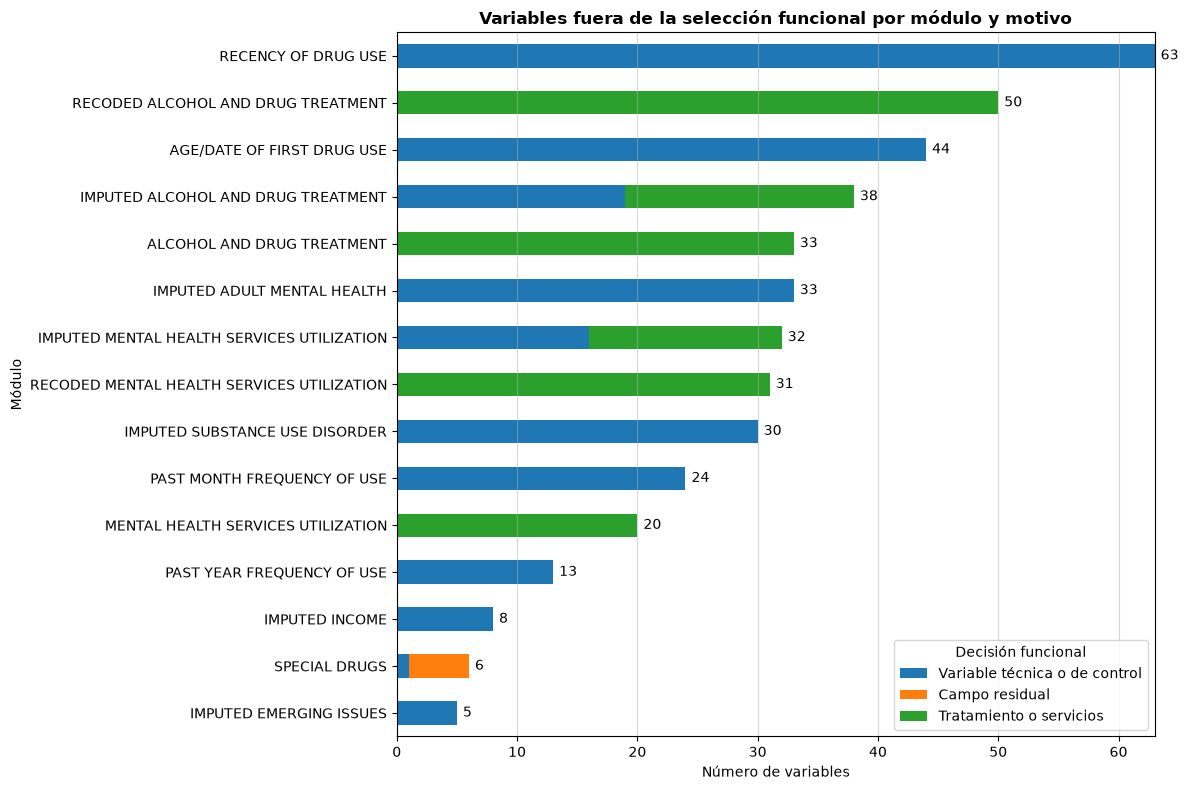

In [30]:
# =============================================================================
# VARIABLES FUERA DE LA SELECCIÓN FUNCIONAL POR MÓDULO Y DECISIÓN
# =============================================================================
orden_decisiones = [
    'Excluir: variable técnica o de control',
    'Excluir: campo residual de respuesta abierta',
    'Sensibilidad: tratamiento o utilización de servicios'
]

modulos_grafico = (
    resumen_modulos_fuera_seleccion.groupby('modulo')['variables'].sum().nlargest(15).index
)

datos_reduccion_modulos = resumen_modulos_fuera_seleccion.loc[
    resumen_modulos_fuera_seleccion['modulo'].isin(modulos_grafico)
].pivot_table(
    index='modulo', columns='decision_funcional', values='variables', aggfunc='sum', fill_value=0
).reindex(columns=orden_decisiones, fill_value=0)

datos_reduccion_modulos = datos_reduccion_modulos.loc[
    datos_reduccion_modulos.sum(axis=1).sort_values().index
]

datos_reduccion_modulos = datos_reduccion_modulos.rename(columns={
    orden_decisiones[0]: 'Variable técnica o de control',
    orden_decisiones[1]: 'Campo residual',
    orden_decisiones[2]: 'Tratamiento o servicios'
})

fig, ax = plt.subplots(figsize=(12, 8))

datos_reduccion_modulos.plot(kind='barh', stacked=True, ax=ax)

for posicion, total in enumerate(datos_reduccion_modulos.sum(axis=1)):
    ax.text(total + 0.5, posicion, str(int(total)), va='center')

ax.set_title('Variables fuera de la selección funcional por módulo y motivo', weight='bold')
ax.set_xlabel('Número de variables')
ax.set_ylabel('Módulo')
ax.legend(title='Decisión funcional')
ax.grid(axis='x', visible=True, alpha=0.5)

_ = guardar_figura(fig, '06_variables_fuera_seleccion_funcional_por_modulo')

### Resultados

La clasificación funcional excluye 303 variables técnicas o residuales y reserva 169 variables de tratamiento o utilización de servicios para un análisis de sensibilidad. Permanecen 1.876 predictores principales, lo que supone una reducción del 20,10 % respecto a las 2.348 variables predictoras provisionales.

Los indicadores de imputación, edición, recorte e inconsistencia se excluyen porque no describen características sustantivas de la persona encuestada. Las variables asistenciales se mantienen separadas por su posible proximidad temporal con los resultados.

Esta reducción se basa exclusivamente en criterios documentales y funcionales, sin utilizar asociaciones con las variables objetivo.

**Clasificación:** MEMORIA para el criterio general de exclusión; ANEXO para los listados detallados.

## 5.4. Selección conceptual por módulos

La selección funcional todavía contiene 1.876 predictores, por lo que se realiza una segunda reducción basada en los módulos oficiales del NSDUH.

Se priorizan las versiones analíticas resumidas y se evitan, cuando existe una alternativa recodificada o imputada adecuada, los bloques originales formados por preguntas detalladas, procesos de edición o múltiples medidas de un mismo consumo.

Los módulos se clasifican como predictores principales, exclusión, sensibilidad o revisión específica. Los módulos de salud mental contemporánea se reservan para sensibilidad por su proximidad con las variables objetivo, mientras que los bloques detallados de consumo se sustituyen preferentemente por sus versiones recodificadas o resumidas.

Esta decisión es conceptual y reproducible: no utiliza asociaciones con las variables objetivo ni información aprendida sobre el conjunto completo.

In [31]:
# =============================================================================
# SELECCIÓN CONCEPTUAL POR MÓDULOS
# =============================================================================
# Se sustituyen bloques detallados de consumo por versiones resumidas y se separa la salud mental
# contemporánea para el análisis de sensibilidad.

modulos_detalle_consumo = [
    'SUBSTANCE USE DISORDER',
    'RECENCY OF DRUG USE',
    'AGE/DATE OF FIRST DRUG USE',
    'PAST MONTH FREQUENCY OF USE',
    'PAST YEAR FREQUENCY OF USE',
    'ALCOHOL',
    'CONSUMPTION OF ALCOHOL',
    'MARIJUANA',
    'BLUNTS',
    'NICOTINE',
    'HALLUCINOGENS',
    'COCAINE',
    'CRACK',
    'HEROIN',
    'INHALANTS',
    'METHAMPHETAMINE',
    'PAIN RELIEVERS',
    'SEDATIVES',
    'STIMULANTS',
    'TRANQUILIZERS',
    'SPECIAL DRUGS',
    'PAIN RELIEVERS SCREENER',
    'SEDATIVES SCREENER',
    'STIMULANTS SCREENER',
    'TRANQUILIZERS SCREENER',
    'MARKET INFORMATION FOR MARIJUANA'
]

modulos_salud_mental = [
    'ADULT DEPRESSION',
    'IMPUTED ADULT DEPRESSION',
    'RECODED ADULT DEPRESSION',
    'ADULT MENTAL HEALTH',
    'IMPUTED ADULT MENTAL HEALTH',
    'RECODED ADULT MENTAL HEALTH'
]

modulos_revision = [
    'SPECIAL TOPICS',
    'RECODED SPECIAL TOPICS',
    'EMERGING ISSUES',
    'RECODED EMERGING ISSUES',
    'IMPUTED EMERGING ISSUES'
]

modulos_tecnicos = [
    'COUNTY',
    'BLOCK',
    'SEGMENT',
    'PROXY INFORMATION',
    'INTERVIEW INFORMATION'
]

grupos_modulos = [
    set(modulos_detalle_consumo),
    set(modulos_salud_mental),
    set(modulos_revision),
    set(modulos_tecnicos)
]

for i, grupo_1 in enumerate(grupos_modulos):
    for grupo_2 in grupos_modulos[i + 1:]:
        if grupo_1 & grupo_2:
            raise ValueError('Existen módulos asignados a más de una decisión.')

modulos_presentes = set(predictores_funcionales['modulo'])
modulos_definidos = set().union(*grupos_modulos)

modulos_no_localizados = sorted(modulos_definidos - modulos_presentes)

if modulos_no_localizados:
    raise ValueError(
        f'Módulos no localizados entre los predictores funcionales: {modulos_no_localizados}')

clasificacion_modulos = predictores_funcionales.groupby('modulo', as_index=False).agg(
    variables=('variable', 'size')
)

clasificacion_modulos['decision_modulo'] = np.select(
    [
        clasificacion_modulos['modulo'].isin(modulos_detalle_consumo),
        clasificacion_modulos['modulo'].isin(modulos_salud_mental),
        clasificacion_modulos['modulo'].isin(modulos_revision),
        clasificacion_modulos['modulo'].isin(modulos_tecnicos)
    ],
    [
        'Excluir: detalle sustituido por versiones resumidas',
        'Sensibilidad: salud mental próxima a variables objetivo',
        'Revisión específica: módulo mixto',
        'Excluir: contexto técnico o de entrevista'
    ], default='Conservar como predictor principal'
)

clasificacion_modulos['justificacion'] = np.select(
    [
        clasificacion_modulos['modulo'].isin(modulos_detalle_consumo),
        clasificacion_modulos['modulo'].isin(modulos_salud_mental),
        clasificacion_modulos['modulo'].isin(modulos_revision),
        clasificacion_modulos['modulo'].isin(modulos_tecnicos)
    ],
    [
        'Sustituido por variables recodificadas, imputadas o resumidas',
        'Temporalidad contemporánea y proximidad conceptual con los resultados',
        'Contenido heterogéneo pendiente de revisión documental',
        'Información geográfica, auxiliar o propia de la entrevista'
    ], default='Dominio contextual, antecedente o versión analítica resumida'
)

clasificacion_conceptual = predictores_funcionales.merge(
    clasificacion_modulos[['modulo', 'decision_modulo', 'justificacion']], on='modulo', how='left',
    validate='many_to_one'
)

variables_excluir_modulos = sorted(
    clasificacion_conceptual.loc[
        clasificacion_conceptual['decision_modulo'].str.startswith('Excluir'), 'variable'
    ].tolist()
)

variables_sensibilidad_modulos = sorted(
    clasificacion_conceptual.loc[
        clasificacion_conceptual['decision_modulo'].str.startswith('Sensibilidad'), 'variable'
    ].tolist()
)

variables_revision_modulos = sorted(
    clasificacion_conceptual.loc[
        clasificacion_conceptual['decision_modulo'].str.startswith('Revisión'), 'variable'
    ].tolist()
)

variables_predictoras_conceptuales = sorted(
    clasificacion_conceptual.loc[
        clasificacion_conceptual['decision_modulo'].eq('Conservar como predictor principal'),
        'variable'
    ].tolist()
)

variables_sensibilidad_total = sorted(
    set(variables_sensibilidad_funcional) | set(variables_sensibilidad_modulos)
)

predictores_conceptuales = clasificacion_conceptual.loc[
    clasificacion_conceptual['variable'].isin(variables_predictoras_conceptuales)
].sort_values(['modulo', 'variable']).reset_index(drop=True)

variables_fuera_seleccion_conceptual = clasificacion_conceptual.loc[
    ~clasificacion_conceptual['variable'].isin(variables_predictoras_conceptuales)
].sort_values(['decision_modulo', 'modulo', 'variable']).reset_index(drop=True)

union_conceptual = (
    set(variables_excluir_modulos) | set(variables_sensibilidad_modulos) |
    set(variables_revision_modulos) | set(variables_predictoras_conceptuales)
)

if union_conceptual != set(predictores_funcionales['variable']):
    raise ValueError('La selección conceptual no contiene todas las variables funcionales.')

resumen_seleccion_modulos = clasificacion_modulos.groupby('decision_modulo', as_index=False).agg(
    modulos=('modulo', 'size'),
    variables=('variables', 'sum')
).sort_values('variables', ascending=False).reset_index(drop=True)

pct_reduccion_conceptual = round(
    (1 - len(variables_predictoras_conceptuales) / len(predictores_funcionales)) * 100, 2
)

pct_reduccion_acumulada = round(
    (1 - len(variables_predictoras_conceptuales) / len(variables_predictoras_provisionales)) * 100,
    2
)

detalle_modulos_fuera = clasificacion_modulos.loc[
    clasificacion_modulos['decision_modulo'].ne('Conservar como predictor principal')
].sort_values(['decision_modulo', 'variables'], ascending=[True, False])

detalle_modulos_fuera = detalle_modulos_fuera.groupby('decision_modulo', group_keys=False).head(5)

tabla_seleccion_modulos = preparar_tabla(resumen_seleccion_modulos)
tabla_detalle_modulos = preparar_tabla(detalle_modulos_fuera)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(clasificacion_modulos, '19_clasificacion_modulos')
_ = guardar_csv(variables_fuera_seleccion_conceptual, '20_variables_fuera_seleccion_conceptual')
_ = guardar_csv(predictores_conceptuales, '21_predictores_conceptuales')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('SELECCIÓN CONCEPTUAL POR MÓDULOS')
print(f'Predictores funcionales: {len(predictores_funcionales):,}')
print(f'Variables excluidas por módulos: {len(variables_excluir_modulos):,}')
print(f'Variables nuevas de sensibilidad: {len(variables_sensibilidad_modulos):,}')
print(f'Variables pendientes de revisión: {len(variables_revision_modulos):,}')
print(f'Predictores conceptuales: {len(variables_predictoras_conceptuales):,}')
print(f'Variables de sensibilidad totales: {len(variables_sensibilidad_total):,}')
print(f'Reducción sobre la selección funcional: {pct_reduccion_conceptual:.2f} %')
print(f'Reducción acumulada desde las variables provisionales: {pct_reduccion_acumulada:.2f} %')

print('\nResumen de decisiones:')
display(tabla_seleccion_modulos)

print('\nMódulos apartados de la selección conceptual principal:')
display(tabla_detalle_modulos)

SELECCIÓN CONCEPTUAL POR MÓDULOS
Predictores funcionales: 1,876
Variables excluidas por módulos: 890
Variables nuevas de sensibilidad: 172
Variables pendientes de revisión: 81
Predictores conceptuales: 733
Variables de sensibilidad totales: 341
Reducción sobre la selección funcional: 60.93 %
Reducción acumulada desde las variables provisionales: 68.78 %

Resumen de decisiones:


,Decisión del módulo,Módulos,Variables
0,Excluir: detalle sustituido por versiones resu...,26,882
1,Conservar como predictor principal,29,733
2,Sensibilidad: salud mental próxima a variables...,6,172
3,Revisión específica: módulo mixto,5,81
4,Excluir: contexto técnico o de entrevista,5,8



Módulos apartados de la selección conceptual principal:


,Módulo,Variables,Decisión del módulo,Justificación
8,COUNTY,2,Excluir: contexto técnico o de entrevista,"Información geográfica, auxiliar o propia de l..."
32,INTERVIEW INFORMATION,2,Excluir: contexto técnico o de entrevista,"Información geográfica, auxiliar o propia de l..."
43,PROXY INFORMATION,2,Excluir: contexto técnico o de entrevista,"Información geográfica, auxiliar o propia de l..."
4,BLOCK,1,Excluir: contexto técnico o de entrevista,"Información geográfica, auxiliar o propia de l..."
62,SEGMENT,1,Excluir: contexto técnico o de entrevista,"Información geográfica, auxiliar o propia de l..."
68,SUBSTANCE USE DISORDER,333,Excluir: detalle sustituido por versiones resu...,"Sustituido por variables recodificadas, imputa..."
44,RECENCY OF DRUG USE,54,Excluir: detalle sustituido por versiones resu...,"Sustituido por variables recodificadas, imputa..."
2,AGE/DATE OF FIRST DRUG USE,44,Excluir: detalle sustituido por versiones resu...,"Sustituido por variables recodificadas, imputa..."
14,HALLUCINOGENS,43,Excluir: detalle sustituido por versiones resu...,"Sustituido por variables recodificadas, imputa..."
36,NICOTINE,37,Excluir: detalle sustituido por versiones resu...,"Sustituido por variables recodificadas, imputa..."


### Resultados

La selección por módulos separa 890 variables: 882 pertenecen a bloques detallados de consumo sustituidos por versiones recodificadas o resumidas y ocho corresponden a información técnica o propia de la entrevista. Otras 172 variables de salud mental contemporánea se incorporan al grupo de sensibilidad.

Después de esta clasificación permanecen 733 predictores conceptuales y 81 variables pertenecientes a cinco módulos especiales o emergentes pendientes de una decisión final.

La reducción acumulada respecto a las 2.348 variables predictoras provisionales alcanza el 68,78 % antes de resolver estos módulos mixtos.

**Clasificación:** MEMORIA para el criterio de selección conceptual; ANEXO para la clasificación completa de módulos.

## 5.5. Cierre de la selección conceptual de variables de entrada

Las variables pertenecientes a los módulos especiales y emergentes se incorporan provisionalmente a los predictores principales porque contienen exposiciones y factores contextuales potencialmente relevantes y no existe una justificación documental para excluirlas en bloque.

La clasificación final mantiene separados los predictores principales, las variables de sensibilidad y las exclusiones documentales o funcionales. La posible eliminación por baja varianza, relaciones muy elevadas entre variables o selección supervisada se realizará posteriormente utilizando únicamente los datos de entrenamiento.

In [32]:
# =============================================================================
# CIERRE DE LA SELECCIÓN CONCEPTUAL DE VARIABLES DE ENTRADA
# =============================================================================
# Los módulos especiales y emergentes se conservan provisionalmente entre los
# predictores principales.

variables_excluir_total = sorted(
    set(variables_excluir_funcional) | set(variables_excluir_modulos)
)

variables_predictoras_finales = sorted(
    set(variables_predictoras_conceptuales) | set(variables_revision_modulos)
)

clasificacion_modulos_final = clasificacion_modulos.copy()

mascara_revision = clasificacion_modulos_final['decision_modulo'].str.startswith('Revisión')

clasificacion_modulos_final.loc[mascara_revision, 'decision_modulo'] = (
    'Conservar como predictor principal'
)

clasificacion_modulos_final.loc[mascara_revision, 'justificacion'] = (
    'Tema especial o emergente relevante conservado provisionalmente'
)

roles_predictores_finales = clasificacion_funcional[[
    'variable', 'etiqueta_codebook', 'modulo', 'tipo_version', 'pct_valores_informativos'
]].copy()

roles_predictores_finales['rol_final_eda'] = np.select(
    [
        roles_predictores_finales['variable'].isin(variables_predictoras_finales),
        roles_predictores_finales['variable'].isin(variables_sensibilidad_total),
        roles_predictores_finales['variable'].isin(variables_excluir_total)
    ],
    [
        'Predictor principal', 'Variable de sensibilidad', 'Excluir de variables de entrada'
    ], default='Sin clasificar'
)

predictores_finales = roles_predictores_finales.loc[
    roles_predictores_finales['variable'].isin(variables_predictoras_finales)
].sort_values(['modulo', 'variable']).reset_index(drop=True)

conjuntos_finales = [
    set(variables_predictoras_finales), set(variables_sensibilidad_total),
    set(variables_excluir_total)
]

for i, conjunto_1 in enumerate(conjuntos_finales):
    for conjunto_2 in conjuntos_finales[i + 1:]:
        if conjunto_1 & conjunto_2:
            raise ValueError('La clasificación final contiene solapamientos.')

union_final = set().union(*conjuntos_finales)

if union_final != set(variables_predictoras_provisionales):
    raise ValueError('La clasificación final no contiene todas las variables predictoras.')

if roles_predictores_finales['rol_final_eda'].eq('Sin clasificar').any():
    raise ValueError('Existen variables predictoras sin un rol final asignado.')

resumen_roles_finales = roles_predictores_finales.groupby('rol_final_eda', as_index=False).agg(
    variables=('variable', 'size'),
    modulos=('modulo', 'nunique')
).sort_values('variables', ascending=False).reset_index(drop=True)

pct_reduccion_final = round(
    (1 - len(variables_predictoras_finales) / len(variables_predictoras_provisionales)) * 100, 2
)

resumen_predictores_modulo = predictores_finales.groupby('modulo', as_index=False).agg(
    variables=('variable', 'size')
).sort_values('variables', ascending=False).reset_index(drop=True)

tabla_roles_finales = preparar_tabla(resumen_roles_finales)

tabla_predictores_modulo = preparar_tabla(resumen_predictores_modulo.head(15))

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(clasificacion_modulos_final, '22_clasificacion_modulos_final')
_ = guardar_csv(roles_predictores_finales, '23_roles_predictores_finales')
_ = guardar_csv(predictores_finales, '24_predictores_finales_eda')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CIERRE DE LA SELECCIÓN CONCEPTUAL DE VARIABLES DE ENTRADA')
print(f'Variables predictoras provisionales: {len(variables_predictoras_provisionales):,}')
print(f'Variables excluidas: {len(variables_excluir_total):,}')
print(f'Variables de sensibilidad: {len(variables_sensibilidad_total):,}')
print(f'Predictores principales: {len(variables_predictoras_finales):,}')
print(f'Reducción conceptual total: {pct_reduccion_final:.2f} %')

print('\nResumen de roles finales:')
display(tabla_roles_finales)

print('\nPredictores principales por módulo:')
display(tabla_predictores_modulo)

CIERRE DE LA SELECCIÓN CONCEPTUAL DE VARIABLES DE ENTRADA
Variables predictoras provisionales: 2,348
Variables excluidas: 1,193
Variables de sensibilidad: 341
Predictores principales: 814
Reducción conceptual total: 65.33 %

Resumen de roles finales:


,Rol final EDA,Variables,Módulos
0,Excluir de variables de entrada,1193,46
1,Predictor principal,814,34
2,Variable de sensibilidad,341,12



Predictores principales por módulo:


,Módulo,Variables
0,RECODED DRUG USE,327
1,HEALTH,64
2,PRIOR SUBSTANCE USE,49
3,RECODED SUBSTANCE USE DISORDER,36
4,IMPUTED SUBSTANCE USE DISORDER,30
5,RECODED EMERGING ISSUES,29
6,SPECIAL TOPICS,26
7,RECODED CONSUMPTION OF ALCOHOL,24
8,NICOTINE DEPENDENCE,23
9,RISK/AVAILABILITY,21


### Resultados

Las 81 variables pertenecientes a los módulos especiales y emergentes se incorporan provisionalmente a los predictores principales.

La clasificación final de las 2.348 variables predictoras provisionales queda formada por 814 predictores principales, 341 variables de sensibilidad y 1.193 exclusiones.

La reducción conceptual alcanza el 65,33 %. Esta cifra no representa todavía una selección estadística definitiva: la baja varianza, las relaciones muy elevadas entre variables y la relación con las variables objetivo se evaluarán posteriormente utilizando únicamente los datos de entrenamiento.

El punto 5 deja así cerrada la selección documental y conceptual previa al EDA selectivo, manteniendo separadas las decisiones que pueden adoptarse con el conjunto completo de aquellas que deben aprenderse exclusivamente a partir de TRAIN.

**Clasificación:** MEMORIA. La reducción conceptual de variables y sus criterios constituyen una parte relevante de la metodología; los listados detallados se conservan como ANEXO.

## Síntesis de la sección 5 (memoria)

La revisión documental de los 2.348 predictores provisionales identifica 14.130 categorías, de las cuales 7.562 corresponden a códigos que requieren interpretación específica. Todos los valores observados en adultos pueden asociarse con la documentación oficial, por lo que no queda ningún valor sin clasificar por el codebook.

La selección funcional excluye 303 variables técnicas o residuales y reserva 169 variables de tratamiento o utilización de servicios para sensibilidad. Posteriormente, la selección conceptual por módulos sustituye bloques detallados por versiones recodificadas o resumidas cuando existe una alternativa adecuada, aparta información técnica adicional y reserva para sensibilidad los módulos de salud mental contemporánea próximos a las variables objetivo.

El cierre de esta fase clasifica las 2.348 variables provisionales en 814 predictores principales, 341 variables de sensibilidad y 1.193 variables excluidas. Esta reducción se basa en criterios documentales, funcionales y conceptuales; la baja variabilidad, las relaciones entre variables y la selección supervisada quedan pospuestas al Notebook 02 y se aprenderán únicamente con TRAIN.

**Tabla candidata:** distribución final de los 2.348 predictores provisionales entre predictores principales, sensibilidad y exclusión.

**Figura candidata:** variables apartadas de la selección funcional por módulo y motivo, prioritariamente para anexos.

**Destino:** MEMORIA + ANEXO.

# 6. Diseño muestral, ponderación y EDA selectivo

El análisis exploratorio de este bloque tiene carácter descriptivo. Ninguna agrupación de categorías, imputación, transformación, escalado, eliminación por baja varianza o selección supervisada se aprende utilizando la población adulta completa; todas las decisiones dependientes de los datos se ajustarán posteriormente utilizando únicamente el conjunto de entrenamiento.

El peso muestral se utiliza para describir la población representada por NSDUH, mientras que la estructura de las variables principales se analiza sin modificar los valores originales que serán transferidos al modelado.

## 6.1. Validación de las variables del diseño muestral

NSDUH utiliza `ANALWT2_C` como peso individual de análisis, `VESTR_C` como pseudoestrato de varianza y `VEREP` para identificar las réplicas de varianza dentro de cada pseudoestrato. Estas variables permanecen separadas de las variables de entrada del modelado.

En este apartado se comprueban su integridad y estructura y se comparan las prevalencias ponderadas y no ponderadas de las cuatro variables objetivo. Las estimaciones son descriptivas; los errores estándar, intervalos de confianza y contrastes requerirían considerar conjuntamente la estratificación, la agrupación muestral y la ponderación.

In [33]:
# =============================================================================
# VALIDACIÓN DEL DISEÑO MUESTRAL Y LA PONDERACIÓN
# =============================================================================
# Se comprueba la integridad de las variables del diseño y se comparan las
# prevalencias ponderadas y no ponderadas de las variables objetivo.
variables_diseno_faltantes = [
    variable for variable in variables_diseno if variable not in df_adultos.columns
]

if variables_diseno_faltantes:
    raise ValueError(f'Variables de diseño no localizadas: {variables_diseno_faltantes}')

resumen_diseno = pd.DataFrame({
    'variable': variables_diseno,
    'n_presentes': [df_adultos[variable].notna().sum() for variable in variables_diseno],
    'n_nan': [df_adultos[variable].isna().sum() for variable in variables_diseno],
    'n_unicos': [df_adultos[variable].nunique(dropna=True) for variable in variables_diseno],
    'minimo': [df_adultos[variable].min() for variable in variables_diseno],
    'maximo': [df_adultos[variable].max() for variable in variables_diseno]
})

if resumen_diseno['n_nan'].ne(0).any():
    raise ValueError('Existen valores físicamente ausentes en las variables de diseño.')

peso_muestral = df_adultos['ANALWT2_C'].astype(float)

if peso_muestral.le(0).any():
    raise ValueError('El peso muestral contiene valores nulos o negativos.')

estructura_diseno = pd.crosstab(df_adultos['VESTR_C'], df_adultos['VEREP'])

n_estratos = df_adultos['VESTR_C'].nunique()
n_codigos_verep = df_adultos['VEREP'].nunique()
n_pares_diseno = (df_adultos[['VESTR_C', 'VEREP']].drop_duplicates().shape[0])

estratos_completos = estructura_diseno.gt(0).sum(axis=1).eq(n_codigos_verep).sum()

suma_pesos = peso_muestral.sum()
n_efectivo_pesos = suma_pesos ** 2 / peso_muestral.pow(2).sum()
efecto_desigual_pesos = len(peso_muestral) / n_efectivo_pesos

filas_prevalencias = []

for objetivo in targets:
    valores = df_adultos[objetivo].astype(float)
    mascara = valores.notna() & peso_muestral.notna()

    pct_no_ponderado = valores.loc[mascara].mean() * 100
    pct_ponderado = np.average(valores.loc[mascara], weights=peso_muestral.loc[mascara]) * 100

    filas_prevalencias.append({
        'variable_objetivo': objetivo,
        'descripcion': titulos_targets[objetivo],
        'n_presentes': int(mascara.sum()),
        'n_positivos': int(valores.loc[mascara].sum()),
        'pct_no_ponderado': round(pct_no_ponderado, 3),
        'pct_ponderado': round(pct_ponderado, 3),
        'diferencia_pp': round(pct_ponderado - pct_no_ponderado, 3)
    })

prevalencias_ponderadas = pd.DataFrame(filas_prevalencias)

tabla_diseno = preparar_tabla(resumen_diseno, redondeo={'minimo': 3, 'maximo': 3})

tabla_prevalencias_ponderadas = preparar_tabla(prevalencias_ponderadas)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_diseno, '25_validacion_diseno_muestral')
_ = guardar_csv(prevalencias_ponderadas, '26_prevalencia_objetivos_ponderada')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VALIDACIÓN DEL DISEÑO MUESTRAL Y LA PONDERACIÓN')
print(f'Registros adultos: {len(df_adultos):,}')
print(f'Pseudoestratos de varianza: {n_estratos:,}')
print(f'Códigos de VEREP por estrato: {n_codigos_verep:,}')
print(f'Combinaciones VESTR_C-VEREP: {n_pares_diseno:,}')
print(f'Estratos completos: {estratos_completos:,}')
print(f'Suma de pesos: {suma_pesos:,.0f}')
print(f'Tamaño efectivo por desigualdad de pesos: {n_efectivo_pesos:,.0f}')
print(f'Efecto aproximado de pesos desiguales: {efecto_desigual_pesos:.3f}')

print('\nVariables del diseño muestral:')
display(tabla_diseno)

print('\nPrevalencias ponderadas y no ponderadas:')
display(tabla_prevalencias_ponderadas)

VALIDACIÓN DEL DISEÑO MUESTRAL Y LA PONDERACIÓN
Registros adultos: 47,299
Pseudoestratos de varianza: 50
Códigos de VEREP por estrato: 2
Combinaciones VESTR_C-VEREP: 100
Estratos completos: 50
Suma de pesos: 262,290,886
Tamaño efectivo por desigualdad de pesos: 14,420
Efecto aproximado de pesos desiguales: 3.280

Variables del diseño muestral:


,Variable,Valores presentes,Valores físicamente ausentes,Valores únicos,Mínimo,Máximo
0,ANALWT2_C,47299,0,47267,2.634,147492.591
1,VESTR_C,47299,0,50,40001.000,40050.000
2,VEREP,47299,0,2,1.000,2.000



Prevalencias ponderadas y no ponderadas:


,Variable objetivo,Descripción,Valores presentes,Positivos,Prevalencia no ponderada (%),Prevalencia ponderada (%),Diferencia (pp)
0,IRAMDEYR,Episodio depresivo mayor,47299,5205,11.004,8.237,-2.767
1,IRSUICTHNK,Ideación suicida,47299,3489,7.376,5.502,-1.874
2,IRSUIPLANYR,Planificación suicida,47299,1170,2.474,1.816,-0.657
3,IRSUITRYYR,Intento suicida,47299,525,1.110,0.845,-0.264


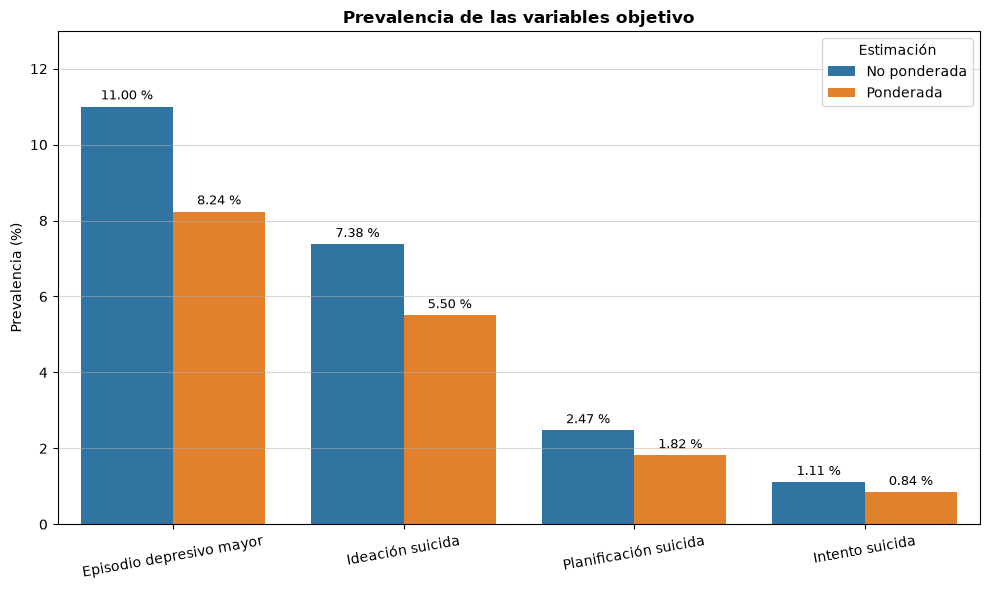

In [34]:
# =============================================================================
# PREVALENCIAS PONDERADAS Y NO PONDERADAS
# =============================================================================
datos_grafico_pesos = prevalencias_ponderadas.melt(
    id_vars='descripcion', value_vars=['pct_no_ponderado', 'pct_ponderado'],
    var_name='estimacion', value_name='prevalencia'
)

datos_grafico_pesos['estimacion'] = datos_grafico_pesos['estimacion'].map(
    {'pct_no_ponderado': 'No ponderada', 'pct_ponderado': 'Ponderada'}
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=datos_grafico_pesos, x='descripcion', y='prevalencia', hue='estimacion', ax=ax)

etiquetar_barras(ax, decimales=2, porcentaje=True)
ax.set_title('Prevalencia de las variables objetivo', weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Prevalencia (%)')
ax.set_ylim(0, datos_grafico_pesos['prevalencia'].max() * 1.18)
ax.legend(title='Estimación')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', visible=True, alpha=0.5)

_ = guardar_figura(fig, '07_prevalencias_objetivos_ponderadas')

### Resultados

Las variables del diseño muestral están completas y presentan 50 pseudoestratos y 100 combinaciones `VESTR_C–VEREP`, con los dos códigos de `VEREP` presentes en cada estrato. La suma de `ANALWT2_C` representa aproximadamente 262,3 millones de personas adultas de la población objetivo del NSDUH.

Las prevalencias ponderadas son inferiores a las observadas directamente en la muestra: 8,24 % para episodio depresivo mayor, 5,50 % para ideación suicida, 1,82 % para planificación suicida y 0,85 % para intento suicida.

El tamaño efectivo aproximado asociado únicamente a la desigualdad de los pesos es de 14.420 observaciones. Esta cifra no incorpora el efecto completo de la estratificación y de la agrupación muestral, por lo que no sustituye una estimación formal de la precisión del diseño complejo.

**Clasificación:** MEMORIA para las prevalencias ponderadas y la justificación del uso de `ANALWT2_C`; ANEXO para las comprobaciones detalladas del diseño.

## 6.2. Estructura de los predictores principales

Antes del modelado se resume la estructura de los 814 predictores principales. Las variables se clasifican como binarias, categóricas con pocas categorías, categóricas con un número moderado de categorías o numéricas con rango documentado.

También se cuantifican los valores físicamente ausentes, la concentración del valor más frecuente y la presencia de códigos documentales especiales. Esta información orientará el tratamiento posterior sin aplicar todavía imputación, transformación, escalado, eliminación por baja varianza ni selección estadística.

In [35]:
# =============================================================================
# ESTRUCTURA DE LOS PREDICTORES PRINCIPALES
# =============================================================================
# Se describe la estructura de las variables sin aprender transformaciones ni
# utilizar su asociación con las variables objetivo.
variables_rango = set(catalogo_codigos.loc[catalogo_codigos['codigo_doc'].eq('RANGE'), 'variable'])

filas_estructura = []

metadatos_predictores = predictores_finales.set_index('variable')

for variable in variables_predictoras_finales:
    serie = df_eda[variable]
    frecuencias = serie.value_counts(dropna=False)

    n_unicos = serie.nunique(dropna=True)
    n_nan = int(serie.isna().sum())
    pct_nan = n_nan / len(serie) * 100
    pct_dominante = frecuencias.iloc[0] / len(serie) * 100

    if variable in variables_rango:
        tipo_variable = 'Numérica con rango documentado'
    elif n_unicos == 2:
        tipo_variable = 'Binaria'
    elif n_unicos <= 10:
        tipo_variable = 'Categórica con pocas categorías'
    elif n_unicos <= 30:
        tipo_variable = 'Categórica con número moderado de categorías'
    else:
        tipo_variable = 'Categórica con muchas categorías'

    filas_estructura.append({
        'variable': variable,
        'modulo': metadatos_predictores.at[variable, 'modulo'],
        'tipo_version': metadatos_predictores.at[variable, 'tipo_version'],
        'tipo_variable': tipo_variable,
        'n_unicos': n_unicos,
        'n_nan': n_nan,
        'pct_nan': round(pct_nan, 3),
        'pct_dominante': round(pct_dominante, 3)
    })

estructura_predictores = pd.DataFrame(filas_estructura)

tipos_ausencia_modelado = ['No respuesta o ausencia', 'Ausencia documental']

ausencias_documentales_predictores = catalogo_contraste.loc[
    catalogo_contraste['variable'].isin(variables_predictoras_finales)
    & catalogo_contraste['presente_adultos']
    & catalogo_contraste['tipo_codigo_doc'].isin(tipos_ausencia_modelado)
].groupby('variable', as_index=False).agg(
    n_ausencia_documental=('frecuencia_adultos', 'sum'),
    tipos_ausencia=('tipo_codigo_doc', lambda x: ' | '.join(sorted(set(x))))
)

ausencias_documentales_predictores['pct_ausencia_documental'] = ausencias_documentales_predictores[
    'n_ausencia_documental'
].div(len(df_eda)).mul(100).round(3)

estructura_predictores = estructura_predictores.merge(
    ausencias_documentales_predictores, on='variable', how='left', validate='one_to_one'
)
estructura_predictores['n_ausencia_documental'] = estructura_predictores[
    'n_ausencia_documental'
].fillna(0).astype(int)
estructura_predictores['pct_ausencia_documental'] = estructura_predictores[
    'pct_ausencia_documental'
].fillna(0)
estructura_predictores['tipos_ausencia'] = (
    estructura_predictores['tipos_ausencia'].fillna('Sin ausencia documental observada')
)

resumen_tipos_variables = estructura_predictores.groupby('tipo_variable', as_index=False).agg(
    variables=('variable', 'size'),
    modulos=('modulo', 'nunique'),
    mediana_valores_unicos=('n_unicos', 'median'),
    pct_nan_mediana=('pct_nan', 'median'),
    mediana_dominante=('pct_dominante', 'median')
).sort_values('variables', ascending=False).reset_index(drop=True)

resumen_variables_modulos = estructura_predictores.groupby(
    ['modulo', 'tipo_variable'], as_index=False
).agg(
    variables=('variable', 'size')
).sort_values(['variables', 'modulo'], ascending=[False, True]).reset_index(drop=True)

resumen_codigos_especiales = catalogo_contraste.loc[
    catalogo_contraste['variable'].isin(variables_predictoras_finales) &
    catalogo_contraste['presente_adultos'] &
    ~catalogo_contraste['tipo_codigo_doc'].isin(['Categoría analítica', 'Rango válido'])
].groupby('tipo_codigo_doc', as_index=False).agg(
    variables=('variable', 'nunique'),
    celdas=('frecuencia_adultos', 'sum')
).sort_values('celdas', ascending=False).reset_index(drop=True)

total_celdas_predictores = len(df_eda) * len(variables_predictoras_finales)

resumen_codigos_especiales['pct_celdas_predictores'] = (
    resumen_codigos_especiales['celdas'].div(total_celdas_predictores).mul(100).round(2)
)

if len(estructura_predictores) != len(variables_predictoras_finales):
    raise ValueError('La estructura no contiene todos los predictores principales.')

if estructura_predictores['variable'].duplicated().any():
    raise ValueError('Existen variables duplicadas en la estructura de predictores.')

tabla_tipos_variables = preparar_tabla(resumen_tipos_variables)
tabla_codigos_especiales = preparar_tabla(resumen_codigos_especiales)
tabla_variables_modulos = preparar_tabla(resumen_variables_modulos.head(15))

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(estructura_predictores, '27_estructura_predictores')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('ESTRUCTURA DE LOS PREDICTORES PRINCIPALES')
print(f'Predictores analizados: {len(estructura_predictores):,}')
print(
    'Variables con rango numérico documentado:',
    estructura_predictores['tipo_variable'].eq('Numérica con rango documentado').sum()
)
print('Variables con valores físicamente ausentes:', estructura_predictores['pct_nan'].gt(0).sum())
print('Variables con valor dominante ≥ 99 %:', estructura_predictores['pct_dominante'].ge(99).sum())
print(
    'Variables con no respuesta o ausencia documental observada:',
    estructura_predictores['n_ausencia_documental'].gt(0).sum()
)

print('\nResumen por tipo de variable:')
display(tabla_tipos_variables)

print('\nCódigos especiales observados entre los predictores:')
display(tabla_codigos_especiales)

print('\nPrincipales combinaciones de módulo y tipo:')
display(tabla_variables_modulos)

ESTRUCTURA DE LOS PREDICTORES PRINCIPALES
Predictores analizados: 814
Variables con rango numérico documentado: 59
Variables con valores físicamente ausentes: 172
Variables con valor dominante ≥ 99 %: 188
Variables con no respuesta o ausencia documental observada: 293

Resumen por tipo de variable:


,Tipo de variable,Variables,Módulos,Mediana de valores únicos,Mediana de valores físicamente ausentes (%),Mediana del valor dominante (%)
0,Binaria,404,16,2.0,0.0,97.285
1,Categórica con pocas categorías,329,30,7.0,0.0,89.905
2,Numérica con rango documentado,59,9,46.0,0.0,85.998
3,Categórica con número moderado de categorías,22,7,19.0,0.0,85.929



Códigos especiales observados entre los predictores:


,Tipo de código documental,Variables,Celdas,Celdas de los predictores (%)
0,Ausencia de exposición,288,11454636,29.75
1,Salto legítimo o no aplicable,359,7243837,18.81
2,No respuesta o ausencia,287,418823,1.09
3,Ausencia documental,6,232052,0.60
4,Asignación lógica,216,13228,0.03



Principales combinaciones de módulo y tipo:


,Módulo,Tipo de variable,Variables
0,RECODED DRUG USE,Binaria,278
1,HEALTH,Categórica con pocas categorías,49
2,RECODED DRUG USE,Categórica con pocas categorías,47
3,PRIOR SUBSTANCE USE,Numérica con rango documentado,30
4,RECODED EMERGING ISSUES,Binaria,29
5,SPECIAL TOPICS,Categórica con pocas categorías,26
6,NICOTINE DEPENDENCE,Categórica con pocas categorías,22
7,RECODED SUBSTANCE USE DISORDER,Categórica con pocas categorías,21
8,RISK/AVAILABILITY,Categórica con pocas categorías,21
9,DEMOGRAPHICS,Categórica con pocas categorías,20


### Resultados

Los 814 predictores principales incluyen 404 variables binarias, 329 categóricas con pocas categorías, 22 categóricas con un número moderado de categorías y 59 numéricas con rango documentado. No permanece ninguna variable categórica con muchas categorías.

Un total de 172 variables presenta algún valor físicamente ausente y 188 concentran al menos el 99 % de los registros en un mismo valor. Los códigos especiales observados representan situaciones diferentes: ausencia de exposición, saltos legítimos, no respuesta, ausencia documental y asignaciones lógicas.

Por tanto, estas situaciones no recibirán un tratamiento único. La no respuesta o ausencia documental se evaluará posteriormente según el significado de cada variable, mientras que los saltos legítimos y la ausencia de exposición se mantendrán como estados diferenciados cuando corresponda.

**Clasificación:** MEMORIA para la estructura general de los 814 predictores; ANEXO para el detalle por módulos y códigos.

## 6.3. Construcción de la base premodelado

Se construye una base reproducible que conecta el EDA con la fase de modelado. Incluye el identificador, las variables del diseño muestral, las cuatro variables objetivo, sus indicadores de imputación, los 814 predictores principales y las 341 variables reservadas para sensibilidad.

La base conserva los valores originales del PUF adulto. No se aplican imputación, transformación, escalado, agrupación de categorías ni selección estadística que deba aprenderse exclusivamente con el conjunto de entrenamiento.

In [36]:
# =============================================================================
# CONSTRUCCIÓN DE LA BASE PREMODELADO
# =============================================================================
# Se conservan los valores originales y se asigna un rol explícito a cada variable
# antes de transferir la base al notebook de modelado.
variable_id = 'QUESTID2'

set_predictores_finales = set(variables_predictoras_finales)
set_sensibilidad = set(variables_sensibilidad_total)

variables_predictoras_orden = [
    variable for variable in df_eda.columns if variable in set_predictores_finales
]

variables_sensibilidad_orden = [
    variable for variable in df_eda.columns if variable in set_sensibilidad
]

columnas_base = (
    [variable_id] + variables_diseno + targets + indicadores_imputacion +
    variables_predictoras_orden + variables_sensibilidad_orden
)

columnas_no_localizadas = [
    variable for variable in columnas_base if variable not in df_eda.columns
]

if len(columnas_base) != len(set(columnas_base)):
    raise ValueError('La base premodelado contiene variables duplicadas.')

if columnas_no_localizadas:
    raise ValueError(f'Variables no localizadas: {columnas_no_localizadas}')

df_premodelado = df_eda[columnas_base].copy()

valores_objetivos = set(np.unique(df_premodelado[targets].to_numpy()))

if len(df_premodelado) != len(df_adultos):
    raise ValueError('La base premodelado no conserva todos los registros adultos.')

if df_premodelado[variable_id].duplicated().any():
    raise ValueError('El identificador QUESTID2 contiene duplicados.')

if df_premodelado[targets].isna().any().any():
    raise ValueError('Existen valores físicamente ausentes en las variables objetivo.')

if not valores_objetivos.issubset({0, 1}):
    raise ValueError(
        f'Las variables objetivo contienen valores no binarios: {sorted(valores_objetivos)}'
    )

roles_base = pd.DataFrame({'variable': columnas_base})

roles_base['rol_base'] = np.select(
    [
        roles_base['variable'].eq(variable_id),
        roles_base['variable'].isin(variables_diseno),
        roles_base['variable'].isin(targets),
        roles_base['variable'].isin(indicadores_imputacion),
        roles_base['variable'].isin(variables_predictoras_finales),
        roles_base['variable'].isin(variables_sensibilidad_total)
    ],
    [
        'Identificador',
        'Diseño muestral',
        'Variable objetivo',
        'Indicador de imputación de variable objetivo',
        'Predictor principal',
        'Variable de sensibilidad'
    ], default='Sin clasificar'
)

if roles_base['rol_base'].eq('Sin clasificar').any():
    raise ValueError('Existen variables sin un rol asignado en la base.')

metadatos_base = catalogo_eda[[
    'variable',
    'etiqueta_codebook',
    'modulo',
    'tipo_version',
    'n_unicos',
    'pct_nan'
]].drop_duplicates('variable')

roles_base = roles_base.merge(metadatos_base, on='variable', how='left', validate='one_to_one')

resumen_base = roles_base.groupby('rol_base', as_index=False).agg(
    variables=('variable', 'size'),
    modulos=('modulo', 'nunique')
).sort_values('variables', ascending=False).reset_index(drop=True)

tabla_resumen_base = preparar_tabla(resumen_base)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
df_premodelado.to_parquet(ruta_base, index=False)

_ = guardar_csv(roles_base, '28_roles_base_premodelado')

tamano_base_mb = ruta_base.stat().st_size / 1024 ** 2

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('CONSTRUCCIÓN DE LA BASE PREMODELADO')
print(f'Registros: {len(df_premodelado):,}')
print(f'Variables totales: {df_premodelado.shape[1]:,}')
print(f'Predictores principales: {len(variables_predictoras_orden):,}')
print(f'Variables de sensibilidad: {len(variables_sensibilidad_orden):,}')
print(f'Variables objetivo: {len(targets):,}')
print(f'Indicadores de imputación: {len(indicadores_imputacion):,}')
print(f'Tamaño del archivo: {tamano_base_mb:.1f} MB')
print(f'Archivo: {ruta_base}')

print('\nVariables por rol:')
display(tabla_resumen_base)

CONSTRUCCIÓN DE LA BASE PREMODELADO
Registros: 47,299
Variables totales: 1,167
Predictores principales: 814
Variables de sensibilidad: 341
Variables objetivo: 4
Indicadores de imputación: 4
Tamaño del archivo: 11.0 MB
Archivo: /home/cam/BD/TFM_NSDUH/data/interim/NSDUH_2024_adultos_premodelado.parquet

Variables por rol:


,Rol,Variables,Módulos
0,Predictor principal,814,34
1,Variable de sensibilidad,341,12
2,Indicador de imputación de variable objetivo,4,2
3,Variable objetivo,4,2
4,Diseño muestral,3,1
5,Identificador,1,1


### Resultados

La base premodelado contiene 47.299 registros y 1.167 variables. Conserva 814 predictores principales y 341 variables de sensibilidad, además de las cuatro variables objetivo, sus cuatro indicadores de imputación, las tres variables del diseño muestral y `QUESTID2`.

El archivo ocupa aproximadamente 11 MB y mantiene los valores originales del PUF adulto. No se han aplicado transformaciones, agrupaciones ni selecciones aprendidas utilizando la población completa.

**Clasificación:** MEMORIA. Esta base constituye la salida principal del notebook y la entrada reproducible para la fase de modelado.

## 6.4. Diagnóstico de los predictores principales

Se representan conjuntamente el tipo de variable, la presencia de valores físicamente ausentes y la concentración del valor más frecuente de los 814 predictores principales.

El objetivo es resumir la estructura general antes del modelado sin eliminar variables ni aprender transformaciones. Los valores físicamente ausentes y los valores dominantes se interpretan junto con la documentación y se conservan para su tratamiento posterior.

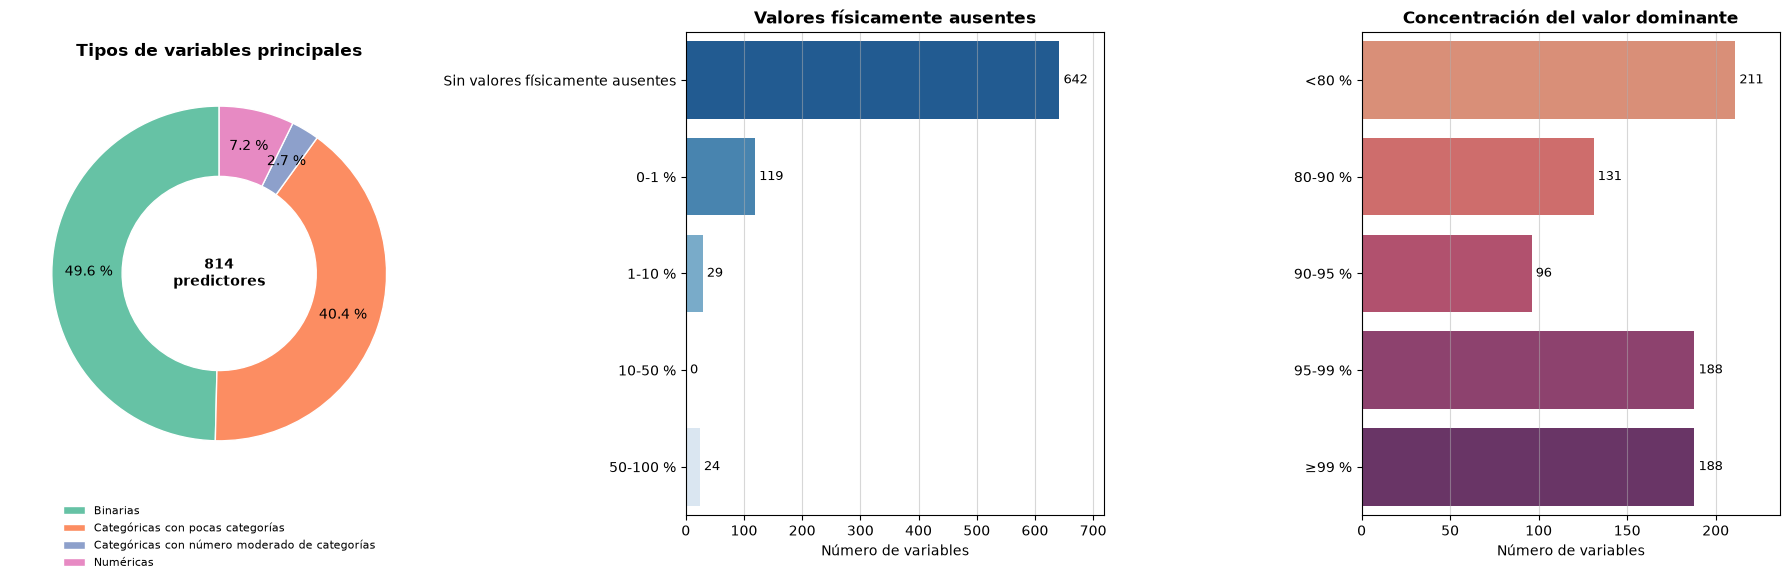

In [37]:
# =============================================================================
# DIAGNÓSTICO DE LOS PREDICTORES PRINCIPALES
# =============================================================================
mapa_tipos = {
    'Binaria': 'Binarias',
    'Categórica con pocas categorías': 'Categóricas con pocas categorías',
    'Categórica con número moderado de categorías': 'Categóricas con número moderado de categorías',
    'Numérica con rango documentado': 'Numéricas'
}

orden_tipos = [
    'Binarias',
    'Categóricas con pocas categorías',
    'Categóricas con número moderado de categorías',
    'Numéricas'
]

resumen_tipos_grafico = (
    estructura_predictores.assign(
        grupo=estructura_predictores['tipo_variable'].map(mapa_tipos)
    )['grupo'].value_counts().reindex(orden_tipos, fill_value=0)
    .rename_axis('grupo').reset_index(name='variables')
)

orden_ausencia_fisica = [
    'Sin valores físicamente ausentes',
    '0-1 %',
    '1-10 %',
    '10-50 %',
    '50-100 %'
]

estructura_predictores['tramo_nan'] = pd.cut(
    estructura_predictores['pct_nan'], bins=[-0.001, 0, 1, 10, 50, 100],
    labels=orden_ausencia_fisica, include_lowest=True
)

resumen_ausencia_grafico = estructura_predictores['tramo_nan'].value_counts().reindex(
    orden_ausencia_fisica, fill_value=0
).rename_axis('grupo').reset_index(name='variables')

orden_dominante = [
    '<80 %',
    '80-90 %',
    '90-95 %',
    '95-99 %',
    '≥99 %'
]

estructura_predictores['tramo_dominante'] = pd.cut(
    estructura_predictores['pct_dominante'], bins=[-0.001, 80, 90, 95, 99, 100.001],
    labels=orden_dominante, include_lowest=True, right=False
)

resumen_dominante_grafico = estructura_predictores['tramo_dominante'].value_counts().reindex(
    orden_dominante, fill_value=0
).rename_axis('grupo').reset_index(name='variables')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

grafico_anillo(
    axes[0], resumen_tipos_grafico['variables'], resumen_tipos_grafico['grupo'],
    f'{len(estructura_predictores)}\npredictores', paleta='Set2', leyenda=True
)
axes[0].set_title('Tipos de variables principales', weight='bold')

sns.barplot(
    data=resumen_ausencia_grafico, y='grupo', x='variables', hue='grupo',
    palette='Blues_r', legend=False, ax=axes[1]
)
etiquetar_barras(axes[1], decimales=0)
axes[1].set_title('Valores físicamente ausentes', weight='bold')
axes[1].set_xlabel('Número de variables')
axes[1].set_ylabel('')
axes[1].set_xlim(0, resumen_ausencia_grafico['variables'].max() * 1.12)
axes[1].grid(axis='x', visible=True, alpha=0.5)

sns.barplot(
    data=resumen_dominante_grafico, y='grupo', x='variables', hue='grupo',
    palette='flare', legend=False, ax=axes[2]
)
etiquetar_barras(axes[2], decimales=0)
axes[2].set_title('Concentración del valor dominante', weight='bold')
axes[2].set_xlabel('Número de variables')
axes[2].set_ylabel('')
axes[2].set_xlim(0, resumen_dominante_grafico['variables'].max() * 1.12)
axes[2].grid(axis='x', visible=True, alpha=0.5)

_ = guardar_figura(fig, '08_estructura_predictores_principales')

### Resultados

Los predictores principales están formados por un 49,6 % de variables binarias, un 40,4 % de variables categóricas con pocas categorías, un 7,2 % de variables numéricas y un 2,7 % de variables categóricas con un número moderado de categorías.

Un total de 642 predictores no presenta valores físicamente ausentes y 172 contienen alguno, aunque la mayoría se mantiene por debajo del 10 %. Asimismo, 188 variables concentran al menos el 99 % de sus registros en un mismo valor.

Estas características se revisarán posteriormente utilizando los datos de entrenamiento, pero no justifican por sí solas la eliminación de una variable.

**Clasificación:** MEMORIA como descripción general de la estructura de las variables de entrada.

## 6.5. Revisión documental de las variables numéricas

Las 59 variables numéricas contienen un rango cuantitativo documentado y, en algunos casos, códigos especiales que representan no respuesta, saltos legítimos, ausencia de exposición o asignaciones lógicas.

Antes de representar distribuciones o identificar valores alejados de la zona central se distinguen los valores comprendidos dentro del rango oficial de los códigos especiales del cuestionario.

Esta revisión es descriptiva y no modifica la base premodelado.

In [38]:
# =============================================================================
# REVISIÓN DOCUMENTAL DE LAS VARIABLES NUMÉRICAS
# =============================================================================
# Se identifican los rangos válidos y los códigos especiales antes de analizar
# distribuciones o valores alejados de la zona central.
variables_numericas = estructura_predictores.loc[
    estructura_predictores['tipo_variable'].eq('Numérica con rango documentado'), 'variable'
].tolist()

rangos_documentados = catalogo_codigos.loc[
    catalogo_codigos['variable'].isin(variables_numericas) &
    catalogo_codigos['codigo_doc'].eq('RANGE'), ['variable', 'etiqueta_codigo']
].rename(columns={'etiqueta_codigo': 'rango_documentado'}).reset_index(drop=True)

if rangos_documentados['variable'].duplicated().any():
    raise ValueError('Existen varias definiciones de rango para una variable.')

if set(rangos_documentados['variable']) != set(variables_numericas):
    variables_sin_rango = sorted(set(variables_numericas) - set(rangos_documentados['variable']))

    raise ValueError(f'Variables sin rango documentado: {variables_sin_rango}')

codigos_fuera_rango = catalogo_contraste.loc[
    catalogo_contraste['variable'].isin(variables_numericas) &
    catalogo_contraste['tipo_codigo_doc'].ne('Rango válido')
].groupby('variable', as_index=False).agg(
    frecuencia_fuera_rango=('frecuencia_adultos', 'sum'),
    tipos_fuera_rango=('tipo_codigo_doc', lambda x: ' | '.join(sorted(set(x))))
)

codigos_fuera_rango['pct_fuera_rango'] = (
    codigos_fuera_rango['frecuencia_fuera_rango'].div(len(df_eda)).mul(100).round(3)
)

revision_numericas = estructura_predictores.loc[
    estructura_predictores['variable'].isin(variables_numericas)
].merge(
    rangos_documentados, on='variable', how='left', validate='one_to_one'
).merge(
    codigos_fuera_rango, on='variable', how='left', validate='one_to_one'
)

revision_numericas[['frecuencia_fuera_rango', 'pct_fuera_rango']] = (
    revision_numericas[['frecuencia_fuera_rango', 'pct_fuera_rango']].fillna(0)
)

revision_numericas['tipos_fuera_rango'] = (
    revision_numericas['tipos_fuera_rango'].fillna('Sin códigos especiales')
)

resumen_numericas_modulo = revision_numericas.groupby('modulo', as_index=False).agg(
    variables=('variable', 'size'),
    mediana_valores_unicos=('n_unicos', 'median'),
    pct_nan_mediana=('pct_nan', 'median'),
    mediana_fuera_rango=('pct_fuera_rango', 'median')
).sort_values('variables', ascending=False).reset_index(drop=True)

tabla_numericas_modulo = preparar_tabla(resumen_numericas_modulo)
tabla_fuera_rango = preparar_tabla(
    revision_numericas.sort_values('pct_fuera_rango', ascending=False).head(15),
    columnas=['variable', 'modulo', 'rango_documentado', 'pct_fuera_rango', 'tipos_fuera_rango']
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(revision_numericas, '29_revision_variables_numericas')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('REVISIÓN DOCUMENTAL DE LAS VARIABLES NUMÉRICAS')
print(f'Variables numéricas: {len(revision_numericas):,}')
print('Variables con códigos fuera del rango:', revision_numericas['pct_fuera_rango'].gt(0).sum())
print('Variables con valores físicamente ausentes:', revision_numericas['pct_nan'].gt(0).sum())

print('\nVariables numéricas por módulo:')
display(tabla_numericas_modulo)

print('\nVariables con mayor presencia de códigos fuera del rango:')
display(tabla_fuera_rango)

REVISIÓN DOCUMENTAL DE LAS VARIABLES NUMÉRICAS
Variables numéricas: 59
Variables con códigos fuera del rango: 59
Variables con valores físicamente ausentes: 4

Variables numéricas por módulo:


,Módulo,Variables,Mediana de valores únicos,Mediana de valores físicamente ausentes (%),Mediana fuera de rango (%)
0,PRIOR SUBSTANCE USE,30,30.5,0.000,95.4765
1,HEALTH,14,78.5,0.000,92.4215
2,EMPLOYMENT,5,46.0,0.000,82.7800
3,EDUCATION,4,27.5,0.000,94.3140
4,RECODED DRUG USE,2,170.5,69.215,69.2150
5,HOUSEHOLD COMPOSITION (ROSTER),1,4.0,3.592,9.6940
6,HEALTH INSURANCE,1,16.0,0.000,94.7190
7,IMPUTED INCOME,1,13.0,0.000,95.9720
8,RECODED HEALTH,1,3067.0,4.757,4.7570



Variables con mayor presencia de códigos fuera del rango:


,Variable,Módulo,Rango documentado,Valores fuera de rango (%),Tipos fuera de rango
50,PCPYLU,PRIOR SUBSTANCE USE,2022 - 2024,99.949,Asignación lógica | Ausencia de exposición | N...
29,HERYLU,PRIOR SUBSTANCE USE,2022 - 2024,99.822,Asignación lógica | Ausencia de exposición | N...
17,CRKYLU,PRIOR SUBSTANCE USE,2022 - 2024,99.774,Asignación lógica | Ausencia de exposición | N...
31,HIVAIDSAG,HEALTH,1 - 59,99.761,Asignación lógica | No respuesta o ausencia | ...
12,CIRROSAGE,HEALTH,1 - 77,99.757,Asignación lógica | No respuesta o ausencia | ...
42,METHYRLST,PRIOR SUBSTANCE USE,2022 - 2024,99.427,Asignación lógica | Ausencia de exposición | N...
40,LSDYLU,PRIOR SUBSTANCE USE,2022 - 2024,99.085,Asignación lógica | Ausencia de exposición | N...
27,HEPBCAGE,HEALTH,1 - 75,99.051,Asignación lógica | No respuesta o ausencia | ...
36,INHLYRLST,PRIOR SUBSTANCE USE,2022 - 2024,99.049,Asignación lógica | Ausencia de exposición | N...
20,ECSTMOYLU,PRIOR SUBSTANCE USE,2022 - 2024,98.989,Asignación lógica | Ausencia de exposición | N...


### Resultados

Las 59 variables numéricas presentan códigos documentales fuera de su rango cuantitativo. Estos códigos no representan necesariamente información perdida, ya que incluyen saltos legítimos, ausencia de exposición, asignaciones lógicas y categorías de no respuesta.

La proporción de valores comprendidos dentro del rango es especialmente reducida en variables condicionadas a enfermedades poco frecuentes o al consumo de sustancias concretas. Por este motivo, las distribuciones numéricas se calcularán únicamente con los valores incluidos en el rango oficial, sin modificar las variables originales ni excluirlas por presentar pocos valores cuantitativos aplicables.

## 6.6. Extracción de valores numéricos válidos

Se extraen los límites inferior y superior de los rangos documentados y se construye una serie cuantitativa válida para cada variable. Los códigos situados fuera de esos límites se excluyen únicamente de los cálculos numéricos, pero permanecen intactos en la base premodelado.

La proporción de registros comprendidos dentro del rango permite diferenciar medidas generales de preguntas aplicables únicamente a situaciones específicas. La regla del rango intercuartílico se utiliza exclusivamente para describir valores alejados de la zona central; estos valores pueden seguir siendo válidos según el codebook y no se eliminan ni transforman en esta fase.

EXTRACCIÓN DE VALORES NUMÉRICOS VÁLIDOS
Variables procesadas: 59
Variables sin observaciones válidas: 0
Variables con menos del 1 % de valores dentro del rango: 9
Variables con al menos el 25 % de valores dentro del rango: 12

Distribución de valores numéricos válidos:


,Tramo de valores válidos,Variables
0,<1 %,9
1,1-5 %,15
2,5-25 %,23
3,25-75 %,6
4,≥75 %,6



Variables con mayor proporción de valores válidos:


,Variable,Módulo,Rango documentado,Valores válidos,Valores válidos (%),Mediana
45,NMERTMT2,HEALTH,0 - 30,45858,96.953,0.000
34,HTINCHE2,HEALTH,55 - 75,45450,96.091,67.000
58,WTPOUND2,HEALTH,75 - 295,45427,96.042,175.000
4,BMI2,RECODED HEALTH,9.3733333333 - 68.557024793,45049,95.243,27.259
47,NMVSOPT2,HEALTH,0 - 15,44329,93.721,2.000
48,NRCH17_2,HOUSEHOLD COMPOSITION (ROSTER),0 - 2,42714,90.306,0.000
53,WRKDHRSWK2,EMPLOYMENT,1 - 60,25692,54.318,40.000
1,ALCNUMDKPM,RECODED DRUG USE,1 - 2040,22586,47.752,10.000
6,CIGAGLST,PRIOR SUBSTANCE USE,2 - 88,16737,35.386,25.000
43,MRJAGLST,PRIOR SUBSTANCE USE,2 - 94,14906,31.514,25.000



Variables con mayor proporción de valores alejados según IQR:


,Variable,Módulo,Valores válidos,Valores alejados según IQR (%),Mínimo válido,Máximo válido
21,EDUSCKCOM,EDUCATION,4189,13.488,0.0,30.0
53,WRKDHRSWK2,EMPLOYMENT,25692,11.077,1.0,60.0
1,ALCNUMDKPM,RECODED DRUG USE,22586,10.130,1.0,2040.0
3,ASTHMAAGE,HEALTH,5309,9.361,1.0,85.0
57,WRKSKIPMO,EMPLOYMENT,4138,9.328,1.0,30.0
54,WRKLASTYR2,EMPLOYMENT,13444,8.814,1986.0,2024.0
56,WRKSICKMO,EMPLOYMENT,8145,8.300,1.0,30.0
31,HIVAIDSAG,HEALTH,113,7.965,1.0,59.0
46,NMNGTHS2,HEALTH,3312,7.397,1.0,30.0
22,EDUSCKMON,EDUCATION,1192,6.460,1.0,30.0


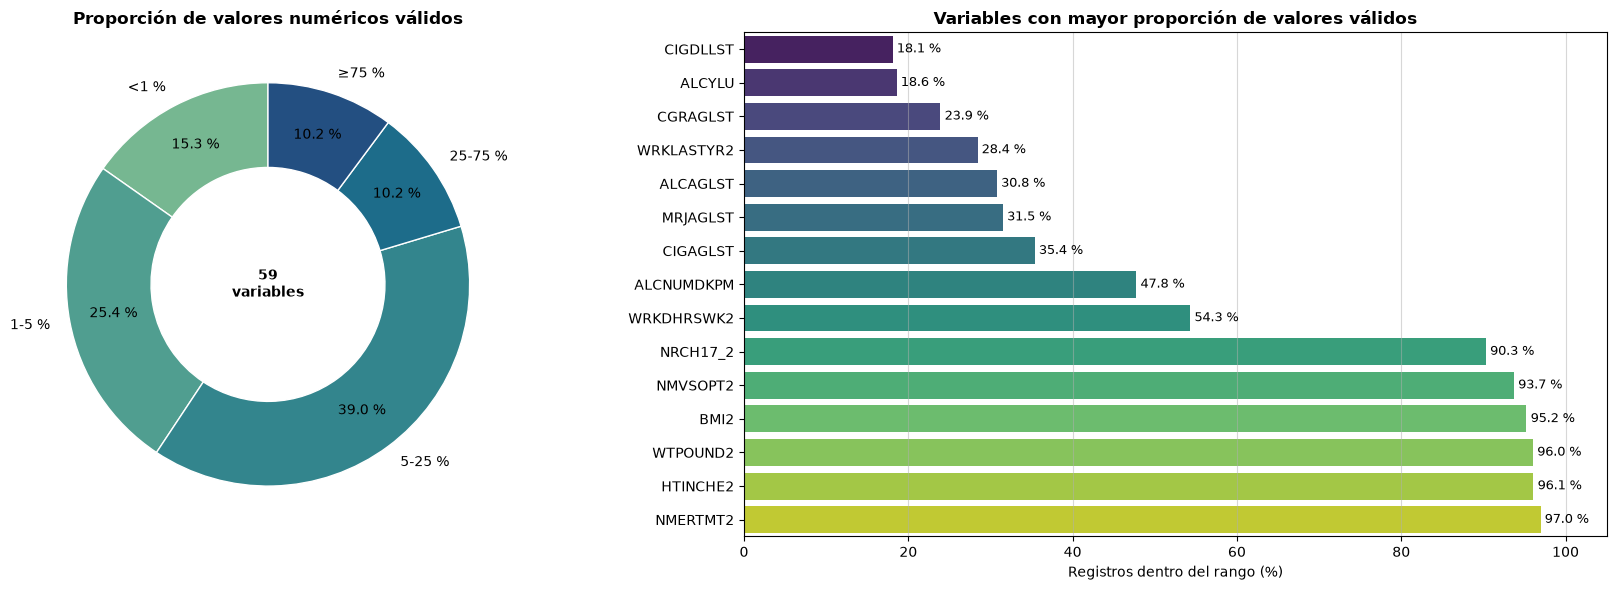

In [39]:
# =============================================================================
# EXTRACCIÓN DE VALORES NUMÉRICOS VÁLIDOS
# =============================================================================
# Se consideran cuantitativos únicamente los valores incluidos en el rango
# oficial. Los códigos especiales permanecen intactos en df_premodelado.
limites = revision_numericas['rango_documentado'].apply(extraer_limites)

revision_numericas[['limite_inferior', 'limite_superior']] = pd.DataFrame(
    limites.tolist(), index=revision_numericas.index
)

rangos_no_interpretados = revision_numericas.loc[
    revision_numericas[['limite_inferior', 'limite_superior']].isna().any(axis=1),
    ['variable', 'rango_documentado']
]

if not rangos_no_interpretados.empty:
    raise ValueError(f'Existen rangos que no se han podido interpretar:\n{rangos_no_interpretados}')

series_numericas_validas = {}
filas_numericas_validas = []

for fila in revision_numericas.itertuples(index=False):
    serie = pd.to_numeric(df_eda[fila.variable], errors='coerce')

    mascara_valida = serie.between(fila.limite_inferior, fila.limite_superior)

    serie_valida = serie.where(mascara_valida)
    valores_validos = serie_valida.dropna()

    q1 = valores_validos.quantile(0.25)
    q3 = valores_validos.quantile(0.75)
    iqr = q3 - q1

    if iqr > 0:
        limite_iqr_inf = q1 - 1.5 * iqr
        limite_iqr_sup = q3 + 1.5 * iqr

        mascara_alejados = valores_validos.lt(limite_iqr_inf) | valores_validos.gt(limite_iqr_sup)
        n_alejados_iqr = int(mascara_alejados.sum())
        pct_alejados_iqr = n_alejados_iqr / len(valores_validos) * 100

    else:
        limite_iqr_inf = np.nan
        limite_iqr_sup = np.nan
        n_alejados_iqr = 0
        pct_alejados_iqr = 0

    series_numericas_validas[fila.variable] = serie_valida

    filas_numericas_validas.append({
        'variable': fila.variable,
        'modulo': fila.modulo,
        'rango_documentado': fila.rango_documentado,
        'limite_inferior': fila.limite_inferior,
        'limite_superior': fila.limite_superior,
        'n_validos': len(valores_validos),
        'pct_validos': round(mascara_valida.mean() * 100, 3),
        'n_unicos_validos': valores_validos.nunique(),
        'minimo_valido': valores_validos.min(),
        'maximo_valido': valores_validos.max(),
        'mediana': valores_validos.median(),
        'media': valores_validos.mean(),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_iqr_inf': limite_iqr_inf,
        'limite_iqr_sup': limite_iqr_sup,
        'n_alejados_iqr': n_alejados_iqr,
        'pct_alejados_iqr': round(pct_alejados_iqr, 3)
    })

resumen_numericas_validas = pd.DataFrame(filas_numericas_validas)

orden_valores_validos = [
    '<1 %',
    '1-5 %',
    '5-25 %',
    '25-75 %',
    '≥75 %'
]

resumen_numericas_validas['tramo_valores_validos'] = pd.cut(
    resumen_numericas_validas['pct_validos'], bins=[0, 1, 5, 25, 75, 100.001],
    labels=orden_valores_validos, include_lowest=True, right=False
)

resumen_tramos_validos = resumen_numericas_validas['tramo_valores_validos'].value_counts().reindex(
    orden_valores_validos, fill_value=0
).rename_axis('tramo_valores_validos').reset_index(name='variables')

numericas_mayor_porcentaje = resumen_numericas_validas.sort_values(
    'pct_validos', ascending=False
).head(15).sort_values('pct_validos').copy()

tabla_tramos_validos = preparar_tabla(resumen_tramos_validos)
tabla_numericas_validas = preparar_tabla(
    resumen_numericas_validas.sort_values('pct_validos', ascending=False).head(10),
    columnas=['variable', 'modulo', 'rango_documentado', 'n_validos', 'pct_validos', 'mediana'],
    redondeo={'pct_validos': 3, 'mediana': 3}
)

tabla_valores_alejados = preparar_tabla(
    resumen_numericas_validas.loc[
        resumen_numericas_validas['iqr'].gt(0)
    ].sort_values('pct_alejados_iqr', ascending=False).head(10),
    columnas=[
        'variable', 'modulo', 'n_validos', 'pct_alejados_iqr', 'minimo_valido', 'maximo_valido'
    ]
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_numericas_validas, '30_resumen_numericas_validas')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('EXTRACCIÓN DE VALORES NUMÉRICOS VÁLIDOS')
print(f'Variables procesadas: {len(resumen_numericas_validas):,}')
print('Variables sin observaciones válidas:', resumen_numericas_validas['n_validos'].eq(0).sum())
print(
    'Variables con menos del 1 % de valores dentro del rango:',
    resumen_numericas_validas['pct_validos'].lt(1).sum()
)
print(
    'Variables con al menos el 25 % de valores dentro del rango:',
    resumen_numericas_validas['pct_validos'].ge(25).sum()
)

print('\nDistribución de valores numéricos válidos:')
display(tabla_tramos_validos)

print('\nVariables con mayor proporción de valores válidos:')
display(tabla_numericas_validas)

print('\nVariables con mayor proporción de valores alejados según IQR:')
display(tabla_valores_alejados)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grafico_anillo(
    axes[0], resumen_tramos_validos['variables'], resumen_tramos_validos['tramo_valores_validos'],
    '59\nvariables', paleta='crest'
)
axes[0].set_title('Proporción de valores numéricos válidos', weight='bold')

sns.barplot(
    data=numericas_mayor_porcentaje, y='variable', x='pct_validos', hue='variable',
    palette='viridis', legend=False, ax=axes[1]
)
etiquetar_barras(axes[1], decimales=1, porcentaje=True)
axes[1].set_title('Variables con mayor proporción de valores válidos', weight='bold')
axes[1].set_xlabel('Registros dentro del rango (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, min(105, numericas_mayor_porcentaje['pct_validos'].max() * 1.12))
axes[1].grid(axis='x', visible=True, alpha=0.5)

_ = guardar_figura(fig, '09_valores_validos_variables_numericas')

### Resultados

Las 59 variables numéricas contienen observaciones válidas dentro de sus rangos documentados. Sin embargo, 47 presentan menos del 25 % de registros dentro del rango, debido principalmente a preguntas condicionadas al consumo de determinadas sustancias, enfermedades concretas o situaciones laborales y educativas específicas.

Doce variables alcanzan al menos el 25 % de registros con valores cuantitativos válidos y seis alcanzan al menos el 75 %. Entre estas últimas aparecen medidas generales de salud, como el IMC, la altura y el peso, junto con determinadas variables sanitarias o de composición del hogar.

La menor proporción de valores dentro del rango no implica por sí sola que una variable deba eliminarse, ya que la ausencia de exposición o la falta de aplicación de una pregunta también puede aportar información.

Como descripción adicional, la regla IQR identifica las mayores proporciones de valores alejados de la zona central en `EDUSCKCOM` (13,49 %), `WRKDHRSWK2` (11,08 %) y `ALCNUMDKPM` (10,13 %). Esta clasificación no implica que sean datos incorrectos ni justifica su eliminación.

## 6.7. Distribuciones numéricas representativas

Se representan tres variables pertenecientes a ámbitos diferentes y con una proporción suficiente de valores dentro de su rango documentado: salud física, empleo y consumo de alcohol.

Para cada una se utilizan exclusivamente los valores cuantitativos válidos y se muestran su distribución y su diagrama de caja. El objetivo es describir asimetrías, concentración y valores extremos válidos sin eliminar observaciones.

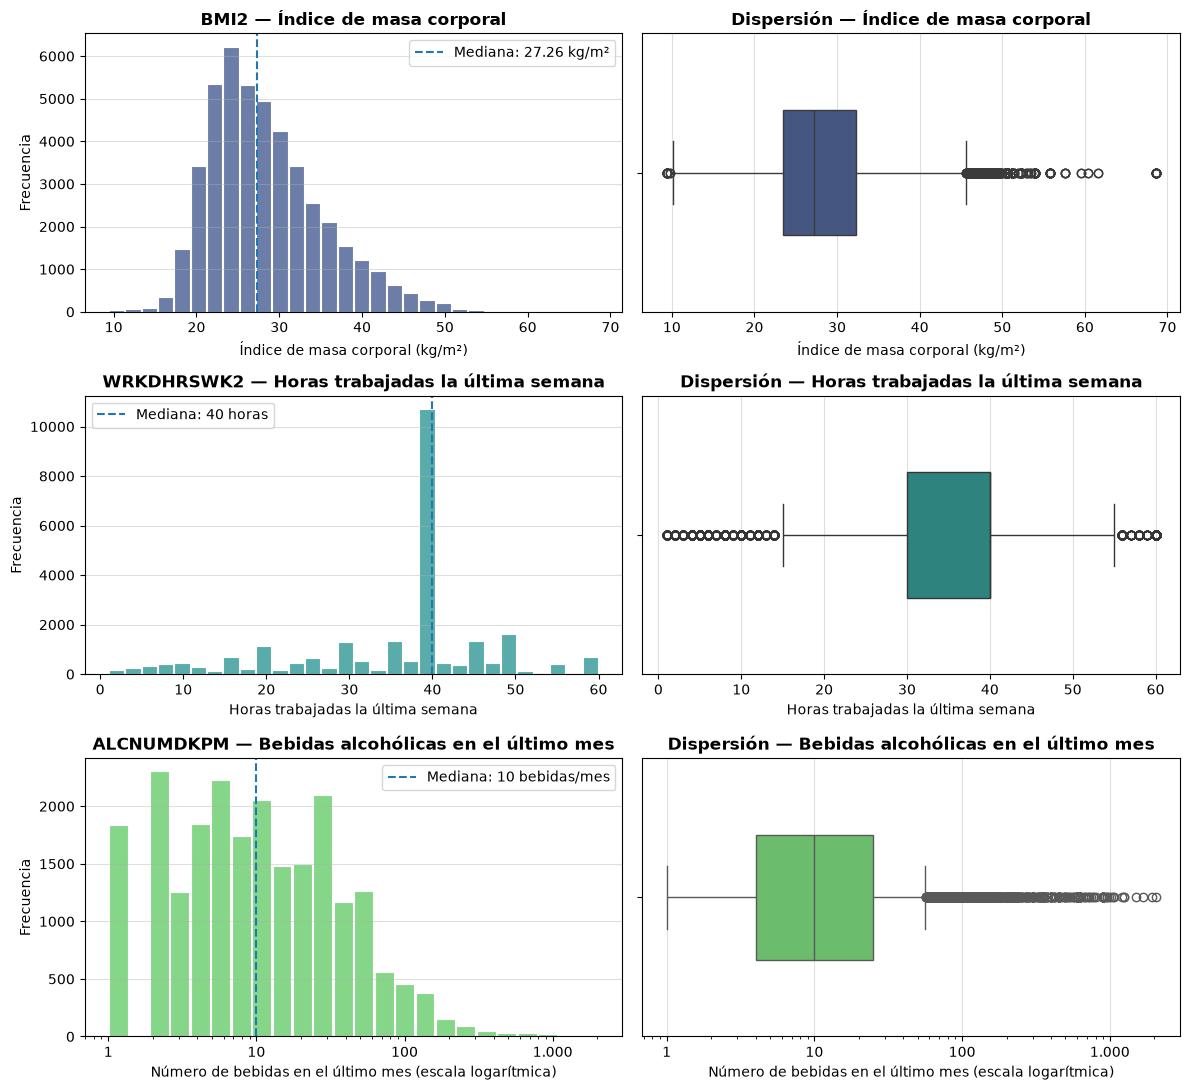

DISTRIBUCIONES NUMÉRICAS REPRESENTATIVAS


,Variable,Módulo,Valores válidos,Valores válidos (%),Media,Mediana,Primer cuartil,Tercer cuartil
0,BMI2,RECODED HEALTH,45049,95.243,28.431,27.259,23.401,32.281
1,WRKDHRSWK2,EMPLOYMENT,25692,54.318,35.860,40.000,30.000,40.000
2,ALCNUMDKPM,RECODED DRUG USE,22586,47.752,25.026,10.000,4.000,25.000


In [40]:
# =============================================================================
# DISTRIBUCIONES NUMÉRICAS REPRESENTATIVAS
# =============================================================================
# Se muestran histogramas y boxplots utilizando solo valores válidos según el
# rango oficial del codebook.
variables_numericas_representativas = [
    'BMI2',
    'WRKDHRSWK2',
    'ALCNUMDKPM'
]

variables_numericas_faltantes = [
    v for v in variables_numericas_representativas if v not in series_numericas_validas]

if variables_numericas_faltantes:
    raise ValueError(f'Variables numéricas no localizadas: {variables_numericas_faltantes}')

resumen_numericas_representativas = resumen_numericas_validas.loc[
    resumen_numericas_validas['variable'].isin(variables_numericas_representativas),
    ['variable', 'modulo', 'n_validos', 'pct_validos', 'media', 'mediana', 'q1', 'q3']
].set_index('variable').loc[variables_numericas_representativas].reset_index()

fig, axes = plt.subplots(len(variables_numericas_representativas), 2, figsize=(12, 11))

config_numericas = {
    'BMI2': {
        'titulo': 'BMI2 — Índice de masa corporal',
        'eje': 'Índice de masa corporal (kg/m²)',
        'unidad_mediana': 'kg/m²',
        'decimales': 2,
        'log': False
    },
    'WRKDHRSWK2': {
        'titulo': 'WRKDHRSWK2 — Horas trabajadas la última semana',
        'eje': 'Horas trabajadas la última semana',
        'unidad_mediana': 'horas',
        'decimales': 0,
        'log': False
    },
    'ALCNUMDKPM': {
        'titulo': 'ALCNUMDKPM — Bebidas alcohólicas en el último mes',
        'eje': 'Número de bebidas en el último mes',
        'unidad_mediana': 'bebidas/mes',
        'decimales': 0,
        'log': True
    }
}

colores_numericas = sns.color_palette('viridis', len(variables_numericas_representativas))

for f, v in enumerate(variables_numericas_representativas):
    serie = series_numericas_validas[v].dropna()
    config = config_numericas[v]
    color = colores_numericas[f]

    if config['log']:
        bins = np.logspace(np.log10(serie.min()), np.log10(serie.max()), 25)
    else:
        bins = 30

    sns.histplot(
        serie, bins=bins, color=color, edgecolor='white', linewidth=0.8, shrink=0.93,
        ax=axes[f, 0]
    )

    mediana = serie.median()
    etiqueta_mediana = (f"Mediana: {mediana:.{config['decimales']}f} {config['unidad_mediana']}")

    axes[f, 0].axvline(mediana, linestyle='--', linewidth=1.5, label=etiqueta_mediana)
    axes[f, 0].set_title(config['titulo'], weight='bold')
    axes[f, 0].set_xlabel(config['eje'])
    axes[f, 0].set_ylabel('Frecuencia')
    axes[f, 0].grid(axis='y', visible=True, alpha=0.4)
    axes[f, 0].legend()

    sns.boxplot(x=serie, color=color, width=0.45, linewidth=1, ax=axes[f, 1])

    axes[f, 1].set_title(f"Dispersión — {config['titulo'].split(' — ')[1]}", weight='bold')
    axes[f, 1].set_xlabel(config['eje'])
    axes[f, 1].set_ylabel('')
    axes[f, 1].grid(axis='x', visible=True, alpha=0.4)

    if config['log']:
        for ax in axes[f]:
            ax.set_xscale('log')
            ax.set_xticks([1, 10, 100, 1000])
            ax.set_xticklabels(['1', '10', '100', '1.000'])
            ax.set_xlabel(f"{config['eje']} (escala logarítmica)")

_ = guardar_figura(fig, '10_distribuciones_numericas_representativas')

tabla_numericas_representativas = preparar_tabla(
    resumen_numericas_representativas,
    redondeo={'pct_validos': 3, 'media': 3, 'mediana': 3, 'q1': 3, 'q3': 3}
)

print('DISTRIBUCIONES NUMÉRICAS REPRESENTATIVAS')
display(tabla_numericas_representativas)

### Resultados

El índice de masa corporal dispone de 45.049 valores cuantitativos válidos (95,24 % de los adultos). Presenta una mediana de 27,26 kg/m² y una media de 28,43 kg/m², con asimetría hacia valores elevados y algunas observaciones alejadas de la zona central que permanecen dentro del rango documentado.

Las horas trabajadas durante la última semana están cuantificadas para 25.692 adultos (54,32 %). La distribución se concentra claramente alrededor de las 40 horas semanales, que constituye también la mediana, aunque aparecen otras jornadas laborales frecuentes y valores extremos válidos.

El consumo mensual de alcohol dispone de 22.586 valores cuantitativos válidos (47,75 %). Entre los adultos con consumo mensual cuantificado, la mediana es de 10 bebidas en el último mes y la media alcanza 25,03, debido a una distribución fuertemente asimétrica y una cola derecha prolongada. Por este motivo se representa en escala logarítmica, lo que permite visualizar simultáneamente los consumos bajos y los valores elevados sin modificar los datos originales.

## 6.8. Asociación entre variables numéricas

Se analiza la relación entre las variables numéricas mediante la correlación de Spearman y un mínimo de observaciones válidas comunes. Este coeficiente resulta adecuado para distribuciones asimétricas, valores discretos y relaciones monotónicas que no tienen que ser estrictamente lineales.

El análisis permite identificar parejas con asociaciones muy elevadas, pero no elimina variables. Cualquier decisión posterior se adoptará únicamente utilizando los datos de entrenamiento.

ASOCIACIÓN ENTRE VARIABLES NUMÉRICAS
Parejas con al menos 500 observaciones comunes: 670
Parejas con correlación absoluta ≥ 0.80: 6
Variables incluidas en la representación: 12

Correlaciones de mayor magnitud:


,Variable 1,Variable 2,Observaciones comunes,Correlación de Spearman,Correlación absoluta
0,EDUSCKCOM,EDUSCKMON,1192,1.000,1.000
1,EDUSKPCOM,EDUSKPMON,1025,1.000,1.000
2,CIGAGLST,CIGDLLST,6809,0.879,0.879
3,BMI2,WTPOUND2,45049,0.864,0.864
4,ECSTMOAGL,HALLAGLST,3562,0.838,0.838
5,COCAGLST,CRKAGLST,1262,0.826,0.826
6,HALLAGLST,LSDAGLST,4232,0.777,0.777
7,HERAGLST,METHAGLST,512,0.734,0.734
8,ECSTMOAGL,LSDAGLST,2184,0.684,0.684
9,CRKAGLST,METHAGLST,699,0.676,0.676


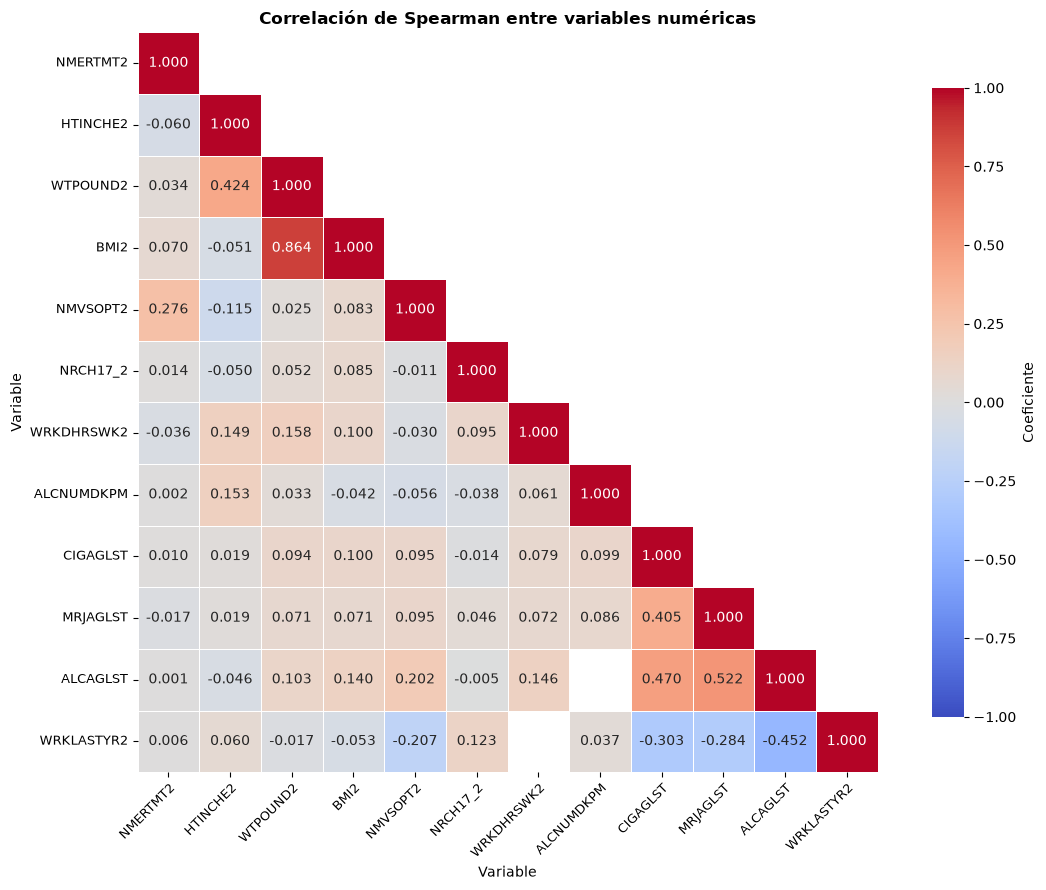

In [41]:
# =============================================================================
# ASOCIACIÓN ENTRE VARIABLES NUMÉRICAS
# =============================================================================
# Se utilizan valores válidos y un mínimo de 500 observaciones comunes.
datos_numericos_validos = pd.DataFrame(series_numericas_validas)

min_observaciones_comunes = 500
umbral_correlacion = 0.80

matriz_corr_numericas = datos_numericos_validos.corr(
    method='spearman', min_periods=min_observaciones_comunes
)

filas_correlaciones = []

for i, variable_1 in enumerate(matriz_corr_numericas.columns):
    for variable_2 in matriz_corr_numericas.columns[i + 1:]:
        correlacion = matriz_corr_numericas.loc[variable_1, variable_2]

        if pd.isna(correlacion):
            continue

        n_comunes = datos_numericos_validos[[variable_1, variable_2]].notna().all(axis=1).sum()

        filas_correlaciones.append({
            'variable_1': variable_1,
            'variable_2': variable_2,
            'n_comunes': int(n_comunes),
            'correlacion_spearman': round(correlacion, 3),
            'correlacion_absoluta': round(abs(correlacion), 3)
        })

correlaciones_numericas = pd.DataFrame(
    filas_correlaciones
).sort_values('correlacion_absoluta', ascending=False).reset_index(drop=True)

correlaciones_altas = correlaciones_numericas.loc[
    correlaciones_numericas['correlacion_absoluta'].ge(umbral_correlacion)
].copy()

variables_correlacion_grafico = resumen_numericas_validas.loc[
    resumen_numericas_validas['pct_validos'].ge(25)
].sort_values('pct_validos', ascending=False)['variable'].tolist()

matriz_corr_grafico = matriz_corr_numericas.loc[
    variables_correlacion_grafico, variables_correlacion_grafico
]

tabla_correlaciones_numericas = preparar_tabla(correlaciones_numericas.head(15))

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(correlaciones_numericas, '31_correlaciones_numericas')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('ASOCIACIÓN ENTRE VARIABLES NUMÉRICAS')
print(f'Parejas con al menos 500 observaciones comunes: {len(correlaciones_numericas):,}')
print(f'Parejas con correlación absoluta ≥ 0.80: {len(correlaciones_altas):,}')
print(f'Variables incluidas en la representación: {len(variables_correlacion_grafico):,}')

print('\nCorrelaciones de mayor magnitud:')
display(tabla_correlaciones_numericas)

matriz_correlacion(
    matriz_corr_grafico, 'Correlación de Spearman entre variables numéricas',
    '11_correlacion_variables_numericas', xlabel='Variable', ylabel='Variable', triangular=True,
    figsize=(12, 9), rotacion_x=45, tam_etiqueta=9
)

### Resultados

Se analizan 670 parejas de variables numéricas con al menos 500 observaciones válidas comunes. Solo seis presentan una correlación de Spearman absoluta igual o superior a 0,80, por lo que las asociaciones de gran magnitud se concentran en un número reducido de parejas. Las celdas sin coeficiente en la matriz corresponden a parejas que no alcanzan el mínimo de 500 observaciones válidas comunes.

Las relaciones más elevadas aparecen entre medidas educativas muy próximas, edades relacionadas con el consumo y variables antropométricas. La relación entre `BMI2` y `WTPOUND2` alcanza 0,864, mientras que dos parejas educativas presentan correlación perfecta.

Estas parejas se mantendrán identificadas para la fase posterior, pero cualquier eliminación se decidirá exclusivamente utilizando los datos de entrenamiento.

## 6.9. Análisis de las variables categóricas

Se analiza la estructura de las variables binarias y categóricas mediante el número de categorías observadas, la presencia de categorías minoritarias y la proporción conjunta que representan. Los códigos documentales se mantienen diferenciados aunque presenten frecuencias reducidas.

Este análisis no agrupa categorías ni modifica la base premodelado. Las posibles reglas de agrupación se definirán posteriormente utilizando únicamente el conjunto de entrenamiento.

In [42]:
# =============================================================================
# ANÁLISIS DE LAS VARIABLES CATEGÓRICAS
# =============================================================================
tipos_categoricos = [
    'Binaria',
    'Categórica con pocas categorías',
    'Categórica con número moderado de categorías'
]

variables_categoricas = estructura_predictores.loc[
    estructura_predictores['tipo_variable'].isin(tipos_categoricos), 'variable'
].tolist()

detalle_categorias = catalogo_contraste.loc[
    catalogo_contraste['variable'].isin(variables_categoricas)
    & catalogo_contraste['presente_adultos']
].copy()

resumen_minoritarias = detalle_categorias.groupby('variable', as_index=False).agg(
    n_categorias_observadas=('codigo_doc', 'size'),
    n_categorias_minoritarias_1=('pct_adultos', lambda x: x.lt(1).sum()),
    n_categorias_minoritarias_01=('pct_adultos', lambda x: x.lt(0.1).sum()),
    pct_acum_minoritarias_1=('pct_adultos', lambda x: x[x.lt(1)].sum()),
    pct_acum_minoritarias_01=('pct_adultos', lambda x: x[x.lt(0.1)].sum())
)

resumen_categoricas = estructura_predictores.loc[
    estructura_predictores['variable'].isin(variables_categoricas),
    ['variable', 'modulo', 'tipo_variable', 'n_unicos', 'pct_nan', 'pct_dominante']
].merge(resumen_minoritarias, on='variable', how='left', validate='one_to_one')

columnas_recuento = [
    'n_categorias_observadas',
    'n_categorias_minoritarias_1',
    'n_categorias_minoritarias_01'
]
columnas_pct = ['pct_acum_minoritarias_1', 'pct_acum_minoritarias_01']

resumen_categoricas[columnas_recuento] = (
    resumen_categoricas[columnas_recuento].fillna(0).astype(int)
)
resumen_categoricas[columnas_pct] = resumen_categoricas[columnas_pct].fillna(0).round(3)

if len(resumen_categoricas) != len(variables_categoricas):
    raise ValueError('El resumen no contiene todas las variables categóricas.')
if resumen_categoricas['variable'].duplicated().any():
    raise ValueError('Existen variables duplicadas en el resumen categórico.')

resumen_categoricas_tipo = resumen_categoricas.groupby('tipo_variable', as_index=False).agg(
    variables=('variable', 'size'),
    mediana_categorias=('n_categorias_observadas', 'median'),
    variables_con_minoritarias_1=('n_categorias_minoritarias_1', lambda x: x.gt(0).sum()),
    variables_con_minoritarias_01=('n_categorias_minoritarias_01', lambda x: x.gt(0).sum()),
    mediana_pct_minoritarias_1=('pct_acum_minoritarias_1', 'median'),
    mediana_dominante=('pct_dominante', 'median')
).sort_values('variables', ascending=False).reset_index(drop=True)

variables_con_minoritarias_1 = resumen_categoricas['n_categorias_minoritarias_1'].gt(0).sum()
variables_con_minoritarias_01 = resumen_categoricas['n_categorias_minoritarias_01'].gt(0).sum()

tabla_resumen_categoricas = preparar_tabla(resumen_categoricas_tipo)
tabla_categorias_minoritarias = preparar_tabla(
    resumen_categoricas.sort_values(
        ['n_categorias_minoritarias_1', 'pct_acum_minoritarias_1'], ascending=False
    ).head(15),
    columnas=[
        'variable', 'modulo', 'tipo_variable', 'n_categorias_observadas',
        'n_categorias_minoritarias_1', 'pct_acum_minoritarias_1', 'pct_dominante'
    ]
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(resumen_categoricas, '32_resumen_variables_categoricas')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('ANÁLISIS DE LAS VARIABLES CATEGÓRICAS')
print(f'Variables categóricas: {len(resumen_categoricas):,}')
print(f'Categorías observadas: {resumen_categoricas["n_categorias_observadas"].sum():,}')
print(f'Variables con alguna categoría < 1 %: {variables_con_minoritarias_1:,}')
print(f'Variables con alguna categoría < 0,1 %: {variables_con_minoritarias_01:,}')
print(
    f'Variables con valor dominante ≥ 99 %: {resumen_categoricas["pct_dominante"].ge(99).sum():,}'
)

print('\nResumen por tipo de variable:')
display(tabla_resumen_categoricas)

print('\nVariables con mayor número de categorías minoritarias:')
display(tabla_categorias_minoritarias)

ANÁLISIS DE LAS VARIABLES CATEGÓRICAS
Variables categóricas: 755
Categorías observadas: 3,433
Variables con alguna categoría < 1 %: 500
Variables con alguna categoría < 0,1 %: 350
Variables con valor dominante ≥ 99 %: 188

Resumen por tipo de variable:


,Tipo de variable,Variables,Mediana de categorías,Variables con categorías < 1 %,"Variables con categorías < 0,1 %",Mediana acumulada de categorías < 1 %,Mediana del valor dominante (%)
0,Binaria,404,2.0,189,100,0.0000,97.285
1,Categórica con pocas categorías,329,7.0,289,233,0.5990,89.905
2,Categórica con número moderado de categorías,22,19.0,22,17,2.1805,85.929



Variables con mayor número de categorías minoritarias:


,Variable,Módulo,Tipo de variable,Categorías observadas,Categorías < 1 %,Categorías < 1 % acumuladas,Valor dominante (%)
100,CIGDLMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,3.471,48.794
628,SMKMOLAST,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,2.771,85.998
408,LSDMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,2.185,89.061
177,ECSTMOMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,2.173,90.475
422,METHMOLST,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,1.282,94.444
142,CRKMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,0.742,96.567
267,HERMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,17,0.571,97.488
110,CIGMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,16,6.362,48.794
95,CIGARMLU,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,16,5.733,69.498
256,HALLMOLST,PRIOR SUBSTANCE USE,Categórica con número moderado de categorías,19,16,4.900,79.991


### Resultados

De las 755 variables categóricas, 500 contienen al menos una categoría con una frecuencia inferior al 1 % y 350 presentan alguna categoría por debajo del 0,1 %. Esta situación aparece especialmente en variables relacionadas con consumo, fuentes de obtención y motivos específicos.

Las variables binarias presentan una mediana del valor dominante del 97,29 %, mientras que 188 predictores concentran al menos el 99 % de los registros en un mismo valor.

No se eliminan ni agrupan categorías en esta fase, ya que una categoría poco frecuente puede representar una exposición válida y potencialmente informativa. Las reglas de agrupación se ajustarán exclusivamente con el conjunto de entrenamiento.

## 6.10. Distribución de las categorías minoritarias

Se resume la presencia de categorías con frecuencias inferiores al 1 % y al 0,1 %, así como la proporción acumulada que representan dentro de cada variable. Esto permite diferenciar la existencia puntual de una categoría minoritaria de situaciones en las que varias categorías pequeñas alcanzan conjuntamente una proporción relevante.

En esta fase no se establece ningún criterio de agrupación ni se crea una categoría adicional.

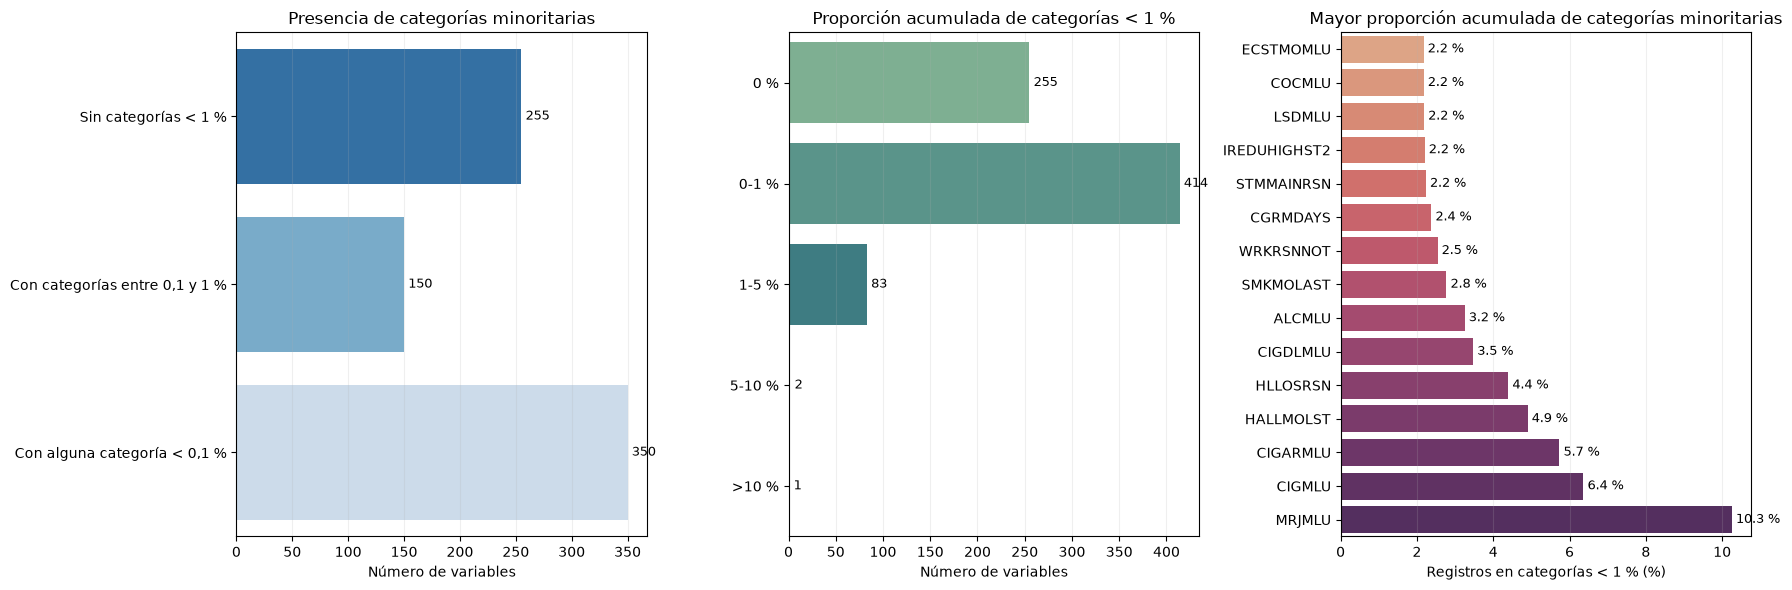

In [43]:
# =============================================================================
# DISTRIBUCIÓN DE LAS CATEGORÍAS MINORITARIAS
# =============================================================================
resumen_presencia_minoritarias = pd.DataFrame({
    'grupo': [
        'Sin categorías < 1 %',
        'Con categorías entre 0,1 y 1 %',
        'Con alguna categoría < 0,1 %'
    ],
    'variables': [
        resumen_categoricas['n_categorias_minoritarias_1'].eq(0).sum(),
        (
            resumen_categoricas['n_categorias_minoritarias_1'].gt(0)
            & resumen_categoricas['n_categorias_minoritarias_01'].eq(0)
        ).sum(),
        resumen_categoricas['n_categorias_minoritarias_01'].gt(0).sum()
    ]
})

orden_peso_minoritarias = ['0 %', '0-1 %', '1-5 %', '5-10 %', '>10 %']

resumen_peso_minoritarias = resumen_categoricas.assign(
    tramo=pd.cut(
        resumen_categoricas['pct_acum_minoritarias_1'], bins=[-0.001, 0, 1, 5, 10, 100],
        labels=orden_peso_minoritarias, include_lowest=True
    )
)['tramo'].value_counts().reindex(
    orden_peso_minoritarias, fill_value=0
).rename_axis('grupo').reset_index(name='variables')

categorias_minoritarias_mayor_peso = resumen_categoricas.loc[
    resumen_categoricas['n_categorias_minoritarias_1'].gt(0)
].nlargest(15, 'pct_acum_minoritarias_1').sort_values('pct_acum_minoritarias_1')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(
    data=resumen_presencia_minoritarias, y='grupo', x='variables', hue='grupo',
    palette='Blues_r', legend=False, ax=axes[0]
)
etiquetar_barras(axes[0], decimales=0)
axes[0].set(title='Presencia de categorías minoritarias', xlabel='Número de variables', ylabel='')
axes[0].grid(axis='x', visible=True, alpha=0.2)

sns.barplot(
    data=resumen_peso_minoritarias, y='grupo', x='variables', hue='grupo',
    palette='crest', legend=False, ax=axes[1]
)
etiquetar_barras(axes[1], decimales=0)
axes[1].set(
    title='Proporción acumulada de categorías < 1 %', xlabel='Número de variables', ylabel=''
)
axes[1].grid(axis='x', visible=True, alpha=0.2)

sns.barplot(
    data=categorias_minoritarias_mayor_peso, y='variable', x='pct_acum_minoritarias_1',
    hue='variable', palette='flare', legend=False, ax=axes[2]
)
etiquetar_barras(axes[2], decimales=1, porcentaje=True, fontsize=9)
axes[2].set(
    title='Mayor proporción acumulada de categorías minoritarias',
    xlabel='Registros en categorías < 1 % (%)', ylabel=''
)
axes[2].grid(axis='x', visible=True, alpha=0.2)

_ = guardar_figura(fig, '12_distribucion_categorias_minoritarias')

### Resultados

De las 755 variables categóricas, 255 no contienen categorías inferiores al 1 %, 150 presentan categorías entre el 0,1 % y el 1 %, y 350 incluyen al menos una categoría con una frecuencia inferior al 0,1 %.

En 414 variables, las categorías inferiores al 1 % representan conjuntamente menos del 1 % de los registros, mientras que en 83 acumulan entre el 1 % y el 5 %. Solo tres variables superan el 5 % y `MRJMLU` alcanza el valor máximo, con un 10,25 %.

Las categorías minoritarias aparecen, por tanto, en una parte importante de las variables, aunque su proporción conjunta suele ser reducida.

## 6.11. Distribuciones categóricas representativas

Se describen cuatro variables sociodemográficas incluidas entre los predictores principales: edad, sexo, raza u origen étnico y nivel educativo. Las proporciones se calculan utilizando `ANALWT2_C` para aproximar la estructura de la población adulta representada por la encuesta.

Las categorías se muestran mediante las etiquetas oficiales del codebook. Este análisis no agrupa niveles ni utiliza su relación con las variables objetivo para adoptar decisiones de selección.

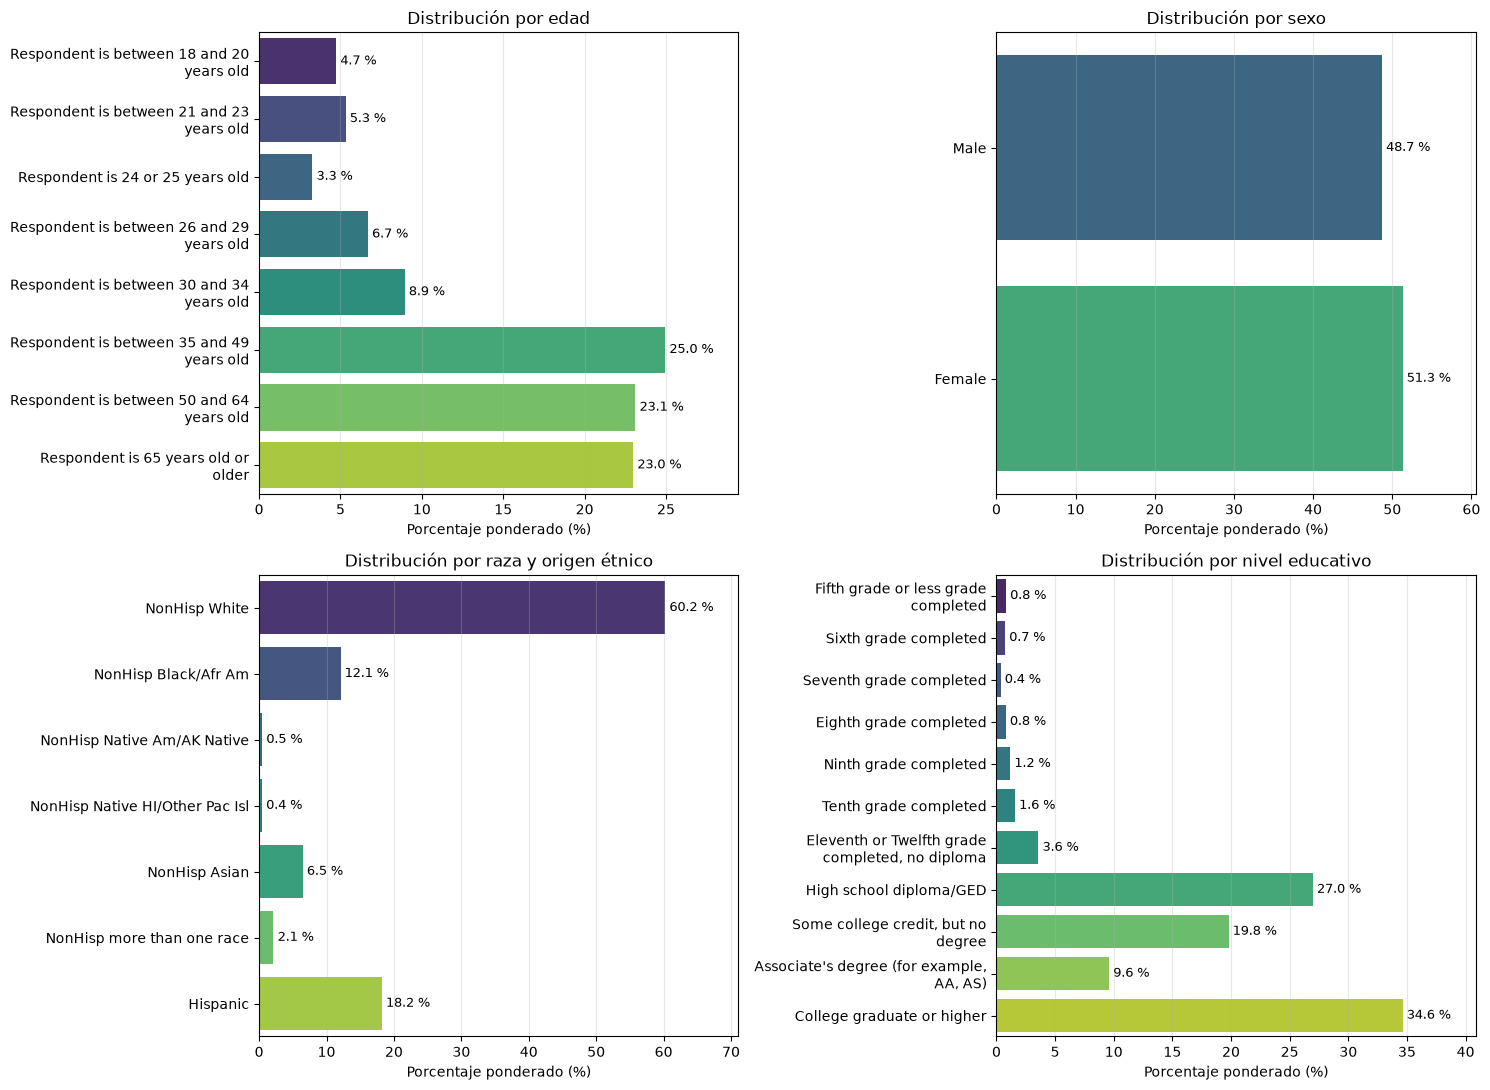

DISTRIBUCIONES CATEGÓRICAS REPRESENTATIVAS


,Variable,Registros,Porcentaje muestral (%),Porcentaje ponderado (%)
0,AGE3,47299,100.001,100.000
1,IREDUHIGHST2,47299,100.000,99.999
2,IRSEX,47299,100.000,100.000
3,NEWRACE2,47299,100.000,100.001


In [44]:
# =============================================================================
# DISTRIBUCIONES CATEGÓRICAS REPRESENTATIVAS
# =============================================================================
variables_categoricas_representativas = ['AGE3', 'IRSEX', 'NEWRACE2', 'IREDUHIGHST2']

variables_categoricas_faltantes = [
    v for v in variables_categoricas_representativas if v not in variables_predictoras_finales
]

if variables_categoricas_faltantes:
    raise ValueError(
        f'Variables categóricas no localizadas entre los predictores principales: '
        f'{variables_categoricas_faltantes}'
    )

filas_categorias_ponderadas = []

for variable in variables_categoricas_representativas:
    catalogo_variable = catalogo_codigos.loc[
        catalogo_codigos['variable'].eq(variable), ['codigo_doc', 'etiqueta_codigo']
    ].copy()

    catalogo_variable['codigo_normalizado'] = [
        normalizar_codigo(codigo)[0] for codigo in catalogo_variable['codigo_doc']
    ]
    catalogo_variable['orden'] = pd.to_numeric(catalogo_variable['codigo_doc'], errors='coerce')

    datos_variable = pd.DataFrame({
        'codigo_normalizado': [normalizar_codigo(valor)[0] for valor in df_eda[variable]],
        'peso': df_eda['ANALWT2_C']
    })

    distribucion_variable = datos_variable.groupby(
        'codigo_normalizado', dropna=False, as_index=False
    ).agg(
        frecuencia=('peso', 'size'),
        suma_pesos=('peso', 'sum')
    ).merge(
        catalogo_variable[['codigo_normalizado', 'codigo_doc', 'etiqueta_codigo', 'orden']],
        on='codigo_normalizado', how='left', validate='one_to_one'
    )

    distribucion_variable['porcentaje_muestral'] = (
        distribucion_variable['frecuencia'] / len(df_eda) * 100
    )
    distribucion_variable['porcentaje_ponderado'] = (
        distribucion_variable['suma_pesos'] / df_eda['ANALWT2_C'].sum() * 100
    )
    distribucion_variable['variable'] = variable
    filas_categorias_ponderadas.append(distribucion_variable)

distribuciones_categoricas_ponderadas = pd.concat(filas_categorias_ponderadas, ignore_index=True)
distribuciones_categoricas_ponderadas[['porcentaje_muestral', 'porcentaje_ponderado']] = (
    distribuciones_categoricas_ponderadas[['porcentaje_muestral', 'porcentaje_ponderado']].round(3)
)

if distribuciones_categoricas_ponderadas['etiqueta_codigo'].isna().any():
    categorias_sin_etiqueta = distribuciones_categoricas_ponderadas.loc[
        distribuciones_categoricas_ponderadas['etiqueta_codigo'].isna(),
        ['variable', 'codigo_normalizado']
    ]
    raise ValueError(f'Existen categorías sin etiqueta documental:\n{categorias_sin_etiqueta}')

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(
    distribuciones_categoricas_ponderadas, '33_distribuciones_categoricas_representativas'
)

titulos_categoricas = {
    'AGE3': 'Distribución por edad',
    'IRSEX': 'Distribución por sexo',
    'NEWRACE2': 'Distribución por raza y origen étnico',
    'IREDUHIGHST2': 'Distribución por nivel educativo'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, variable in zip(axes.flat, variables_categoricas_representativas):
    datos_grafico = distribuciones_categoricas_ponderadas.loc[
        distribuciones_categoricas_ponderadas['variable'].eq(variable)
    ].sort_values(['orden', 'codigo_normalizado'], na_position='last').copy()

    datos_grafico['etiqueta_grafico'] = datos_grafico['etiqueta_codigo'].astype(str).str.wrap(32)

    sns.barplot(
        data=datos_grafico, y='etiqueta_grafico', x='porcentaje_ponderado',
        hue='etiqueta_grafico', palette='viridis', legend=False, ax=ax
    )
    etiquetar_barras(ax, decimales=1, porcentaje=True, fontsize=9)
    ax.set(title=titulos_categoricas[variable], xlabel='Porcentaje ponderado (%)', ylabel='')
    ax.set_xlim(0, datos_grafico['porcentaje_ponderado'].max() * 1.18)
    ax.grid(axis='x', visible=True, alpha=0.3)

_ = guardar_figura(fig, '13_distribuciones_categoricas_representativas')

comprobacion_categoricas = distribuciones_categoricas_ponderadas.groupby(
    'variable', as_index=False
).agg(
    registros=('frecuencia', 'sum'),
    porcentaje_muestral=('porcentaje_muestral', 'sum'),
    porcentaje_ponderado=('porcentaje_ponderado', 'sum')
).round(3)

tabla_comprobacion_categoricas = preparar_tabla(comprobacion_categoricas)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('DISTRIBUCIONES CATEGÓRICAS REPRESENTATIVAS')
display(tabla_comprobacion_categoricas)

### Resultados

La ponderación modifica especialmente la distribución por edad: las personas de 50 años o más representan el 46,1 % de la población adulta, aunque constituyen una proporción considerablemente menor de la muestra. La distribución por sexo es más estable, con un 51,3 % de mujeres y un 48,7 % de hombres.

La población blanca no hispana representa el 60,2 %, seguida de la población hispana, con un 18,2 %, y de la población negra no hispana, con un 12,1 %. Respecto al nivel educativo, el 34,6 % posee titulación universitaria o superior, el 27,0 % dispone de un diploma de secundaria o GED y el 19,8 % ha cursado estudios universitarios sin obtener un título.

Las diferencias entre la distribución muestral y la ponderada respaldan el uso de `ANALWT2_C` para las descripciones poblacionales.

**Clasificación:** MEMORIA para las distribuciones sociodemográficas principales; ANEXO para las tablas detalladas.

## 6.12. Prevalencias ponderadas por grupos sociodemográficos

Se comparan las prevalencias ponderadas de las cuatro variables objetivo por edad, sexo, raza u origen étnico y nivel educativo. Los mapas de calor permiten identificar diferencias entre subgrupos sin utilizar estas asociaciones para seleccionar variables.

El análisis es descriptivo y las categorías con pocos registros deben interpretarse con cautela.

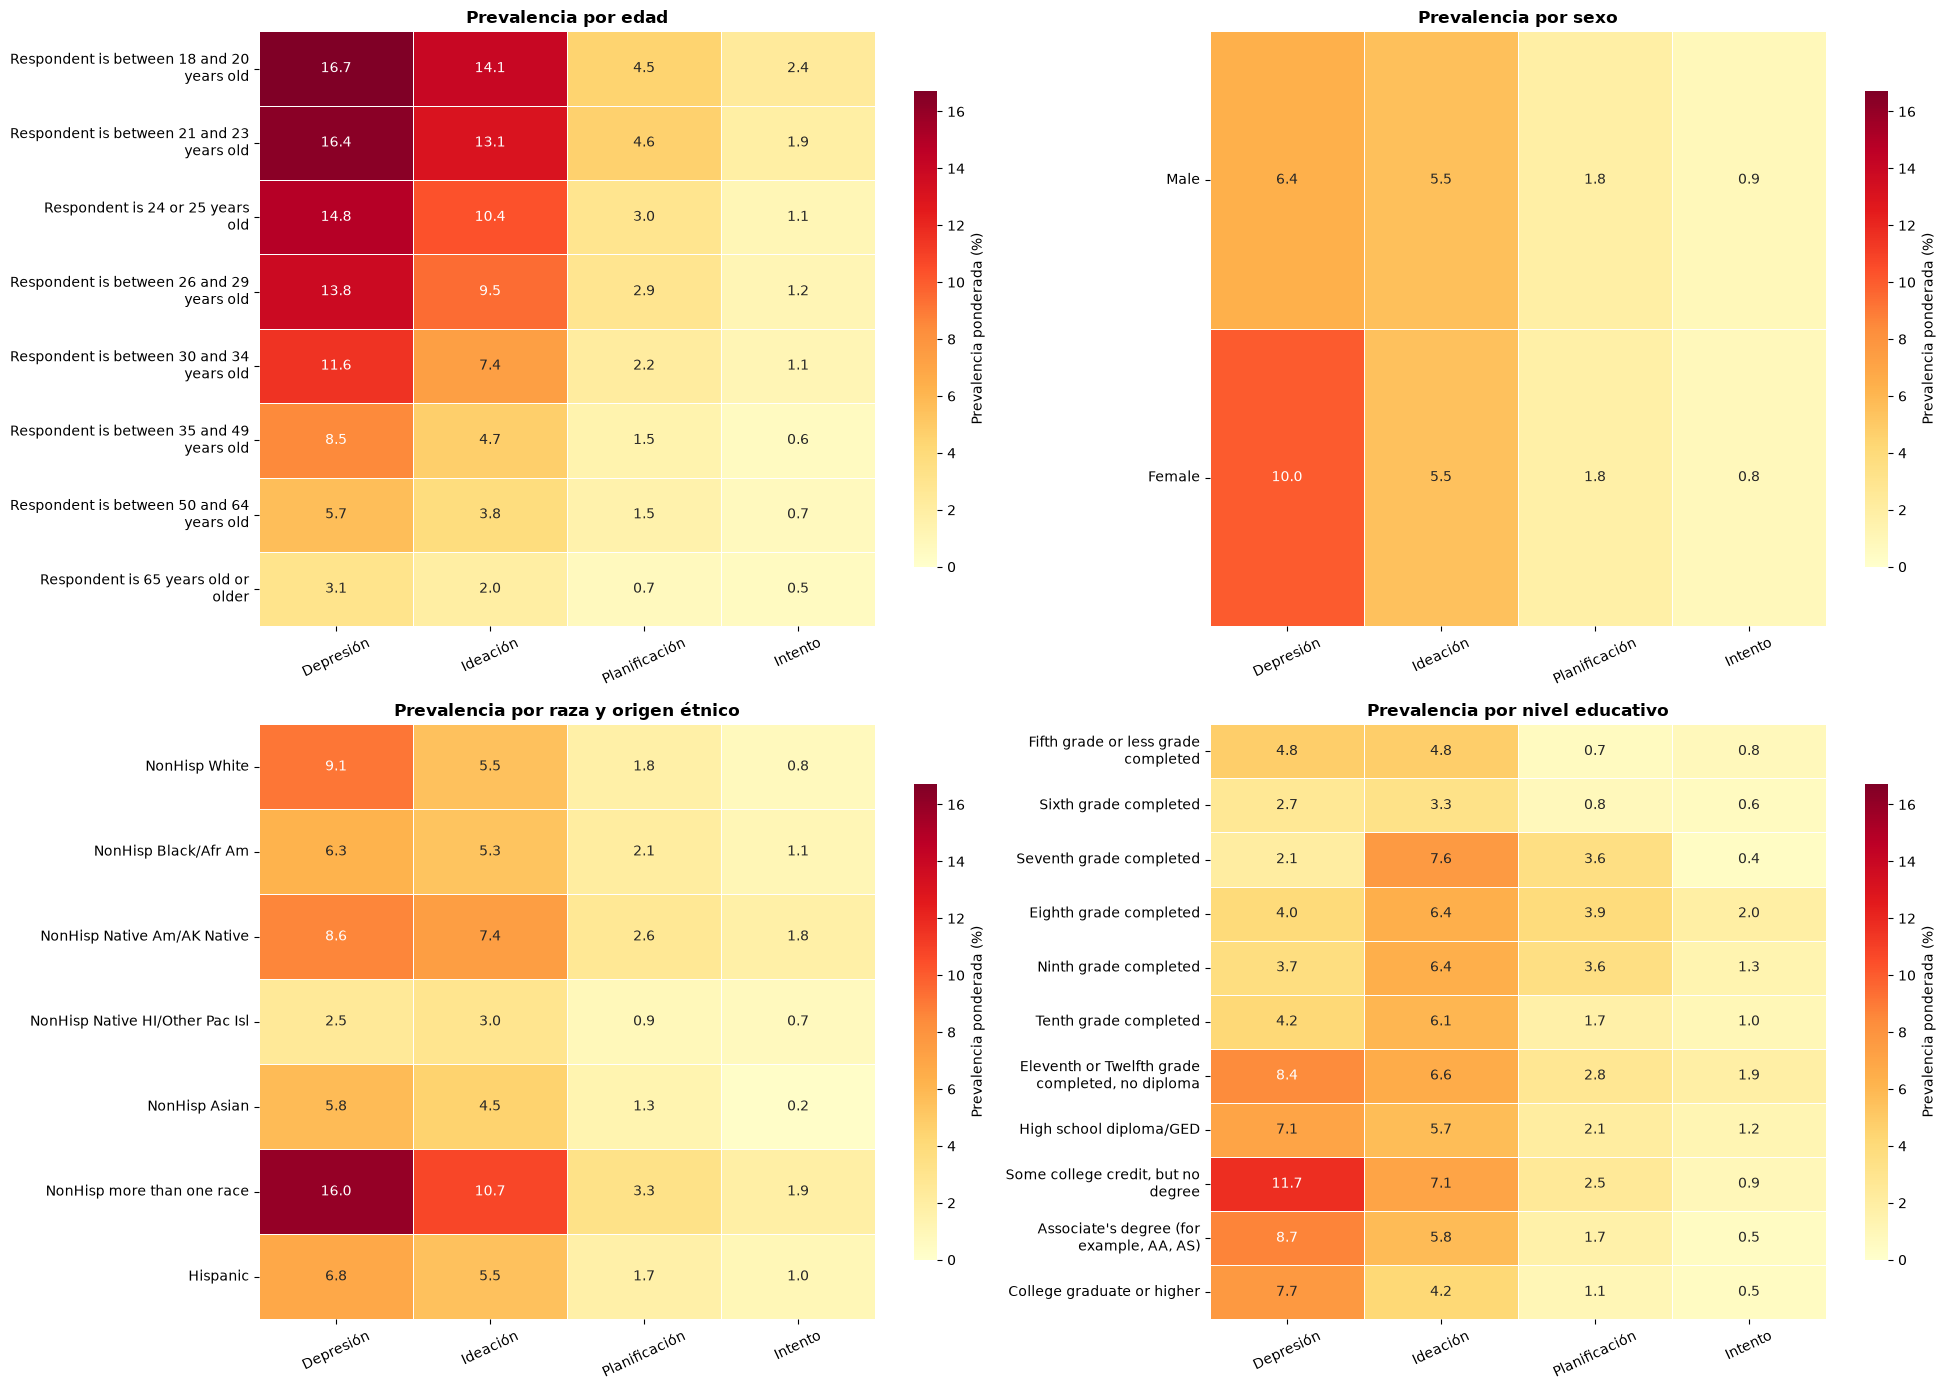

PREVALENCIAS PONDERADAS POR GRUPOS SOCIODEMOGRÁFICOS
Variables de agrupación: 4
Variables objetivo analizadas: 4

Grupo con mayor prevalencia para cada variable objetivo:


,Variable de agrupación,Descripción,Etiqueta del código,Registros,Prevalencia ponderada (%)
0,AGE3,Episodio depresivo mayor,Respondent is between 18 and 20 years old,5024,16.725
1,AGE3,Ideación suicida,Respondent is between 18 and 20 years old,5024,14.099
2,AGE3,Planificación suicida,Respondent is between 21 and 23 years old,5401,4.595
3,AGE3,Intento suicida,Respondent is between 18 and 20 years old,5024,2.358
4,IREDUHIGHST2,Episodio depresivo mayor,"Some college credit, but no degree",9357,11.700
5,IREDUHIGHST2,Ideación suicida,Seventh grade completed,131,7.629
6,IREDUHIGHST2,Planificación suicida,Eighth grade completed,327,3.909
7,IREDUHIGHST2,Intento suicida,Eighth grade completed,327,1.955
8,IRSEX,Episodio depresivo mayor,Female,26062,9.998
9,IRSEX,Ideación suicida,Male,21237,5.546


In [45]:
# =============================================================================
# PREVALENCIAS PONDERADAS POR GRUPOS SOCIODEMOGRÁFICOS
# =============================================================================
# Se calculan prevalencias descriptivas ponderadas para las cuatro variables
# objetivo.
etiquetas_grupos = distribuciones_categoricas_ponderadas[[
    'variable',
    'codigo_normalizado',
    'etiqueta_codigo',
    'orden'
]].drop_duplicates(
    ['variable', 'codigo_normalizado']
).rename(columns={'variable': 'variable_grupo'})

filas_prevalencias_grupos = []

for variable in variables_categoricas_representativas:
    datos_grupo = pd.DataFrame({
        'codigo_normalizado': [normalizar_codigo(valor)[0] for valor in df_eda[variable]],
        'peso': df_eda['ANALWT2_C']
    })

    for objetivo in targets:
        datos_grupo[objetivo] = df_eda[objetivo]

    for codigo, grupo in datos_grupo.groupby('codigo_normalizado', dropna=False):
        for objetivo in targets:
            prevalencia = np.average(grupo[objetivo], weights=grupo['peso']) * 100

            filas_prevalencias_grupos.append({
                'variable_grupo': variable,
                'codigo_normalizado': codigo,
                'variable_objetivo': objetivo,
                'n_registros': len(grupo),
                'prevalencia_ponderada': round(prevalencia, 3)
            })

prevalencias_grupos = pd.DataFrame(filas_prevalencias_grupos).merge(
    etiquetas_grupos, on=['variable_grupo', 'codigo_normalizado'], how='left',
    validate='many_to_one'
)

if prevalencias_grupos['etiqueta_codigo'].isna().any():
    raise ValueError('Existen grupos sin etiqueta documental.')

prevalencias_grupos['descripcion'] = prevalencias_grupos['variable_objetivo'].map(titulos_targets)

prevalencias_grupos['objetivo_etiqueta'] = (
    prevalencias_grupos['variable_objetivo'].map(titulos_targets_red)
)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(prevalencias_grupos, '34_prevalencias_objetivos_por_grupos')

maximos_prevalencia_grupos = prevalencias_grupos.sort_values(
    'prevalencia_ponderada', ascending=False
).groupby(['variable_grupo', 'variable_objetivo'], as_index=False).first()

vmax_prevalencias = prevalencias_grupos['prevalencia_ponderada'].max()

titulos_prevalencia = {
    'AGE3': 'Prevalencia por edad',
    'IRSEX': 'Prevalencia por sexo',
    'NEWRACE2': 'Prevalencia por raza y origen étnico',
    'IREDUHIGHST2': 'Prevalencia por nivel educativo'
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for ax, variable in zip(axes.flat, variables_categoricas_representativas):
    datos_variable = prevalencias_grupos.loc[
        prevalencias_grupos['variable_grupo'].eq(variable)
    ].copy()

    orden_etiquetas = datos_variable[['etiqueta_codigo', 'orden']].drop_duplicates().sort_values(
        ['orden', 'etiqueta_codigo'], na_position='last'
    )['etiqueta_codigo'].tolist()

    matriz_grafico = datos_variable.pivot(
        index='etiqueta_codigo', columns='objetivo_etiqueta', values='prevalencia_ponderada'
    ).reindex(index=orden_etiquetas, columns=list(titulos_targets_red.values()))

    matriz_grafico.index = matriz_grafico.index.astype(str).str.wrap(31)

    sns.heatmap(
        matriz_grafico, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=vmax_prevalencias,
        linewidths=0.5, cbar_kws={'label': 'Prevalencia ponderada (%)', 'shrink': 0.8}, ax=ax
    )

    ax.set_title(titulos_prevalencia[variable], weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=25)
    ax.tick_params(axis='y', labelrotation=0)

_ = guardar_figura(fig, '14_prevalencias_objetivos_por_grupos')

tabla_maximos_prevalencia = preparar_tabla(
    maximos_prevalencia_grupos, columnas=[
        'variable_grupo', 'descripcion', 'etiqueta_codigo', 'n_registros', 'prevalencia_ponderada'
    ]
)

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('PREVALENCIAS PONDERADAS POR GRUPOS SOCIODEMOGRÁFICOS')
print('Variables de agrupación:', len(variables_categoricas_representativas))
print('Variables objetivo analizadas:', len(targets))

print('\nGrupo con mayor prevalencia para cada variable objetivo:')
display(tabla_maximos_prevalencia)

### Resultados

Las prevalencias ponderadas muestran un marcado gradiente por edad. El episodio depresivo mayor desciende del 16,7 % entre 18 y 20 años al 3,1 % entre las personas de 65 años o más, mientras que la ideación suicida pasa del 14,1 % al 2,0 %. La planificación suicida alcanza su máximo entre 21 y 23 años y el intento suicida entre 18 y 20 años.

El episodio depresivo mayor es más frecuente en mujeres, con un 10,0 % frente al 6,4 % en hombres, mientras que las restantes variables objetivo presentan diferencias menores por sexo. La población no hispana de más de una raza presenta las prevalencias más elevadas de las cuatro variables objetivo.

Algunos máximos educativos corresponden a grupos con pocos registros, como séptimo y octavo curso, por lo que no deben interpretarse como estimaciones estables ni utilizarse para establecer conclusiones inferenciales.

Estas comparaciones son descriptivas, no incluyen intervalos de confianza y no implican relaciones causales. Tampoco se han aplicado en este apartado las reglas oficiales de supresión por precisión ni se han estimado los errores estándar completos del diseño muestral, por lo que los subgrupos pequeños no se presentarán como estimaciones poblacionales definitivas.

**Clasificación:** MEMORIA para los principales patrones sociodemográficos ponderados; ANEXO para las tablas detalladas por grupo.

## Síntesis de la sección 6 (memoria)

Las variables del diseño muestral se encuentran completas y conservan la estructura esperada: 50 pseudoestratos, dos códigos de `VEREP` por estrato y 100 combinaciones `VESTR_C–VEREP`. La suma de `ANALWT2_C` representa aproximadamente 262,3 millones de personas adultas. Al aplicar el peso, las prevalencias descriptivas de episodio depresivo mayor, ideación, planificación e intento suicida se sitúan en 8,24 %, 5,50 %, 1,82 % y 0,85 %, respectivamente.

Los 814 predictores principales están formados por 404 variables binarias, 329 variables categóricas con pocas categorías, 22 variables categóricas con un número moderado de categorías y 59 variables numéricas con rango documentado. El análisis de valores físicamente ausentes, códigos especiales, concentración, rangos, categorías minoritarias y correlaciones se mantiene como diagnóstico descriptivo y no elimina ni transforma variables.

La base premodelado queda construida con 47.299 registros y 1.167 variables, integrando el identificador, el diseño muestral, las cuatro variables objetivo, sus indicadores de imputación, los 814 predictores principales y las 341 variables de sensibilidad. Las distribuciones ponderadas confirman diferencias descriptivas por edad, sexo, raza u origen étnico y nivel educativo, que no se interpretan como relaciones causales ni como estimaciones inferenciales completas del diseño complejo.

**Tablas candidatas:** estructura de los 814 predictores y comparación entre prevalencias ponderadas y no ponderadas.

**Figuras candidatas:** prevalencias ponderadas de las variables objetivo y distribuciones/prevalencias sociodemográficas seleccionadas. Las figuras diagnósticas detalladas se reservan principalmente para anexos.

**Destino:** MEMORIA + ANEXO.

# 7. Cierre del EDA y transferencia al modelado

La fase de datos y EDA finaliza con una base adulta auditada, cuatro variables objetivo validadas, 814 predictores principales y 341 variables reservadas para el análisis de sensibilidad. Los valores originales del PUF adulto se conservan sin aplicar transformaciones aprendidas a partir del conjunto completo.

Antes de iniciar el modelado se comprueban la lectura del archivo Parquet, sus dimensiones, el orden de las variables, el identificador, las cuatro variables objetivo y el archivo que recoge el rol asignado a cada variable. También se registran las huellas SHA-256 de las dos entradas principales y de la base premodelado.

## 7.1. Validación final y transferencia al modelado

La validación final comprueba que los archivos guardados reproducen la estructura construida durante el EDA. El siguiente notebook deberá seleccionar las variables de entrada mediante el rol `Predictor principal` registrado en `28_roles_base_premodelado.csv`, manteniendo separadas las variables de sensibilidad, los indicadores de imputación y las variables del diseño muestral.

La partición de los datos, el preprocesamiento, la reducción estadística de variables y cualquier transformación dependiente de los datos se realizarán posteriormente utilizando únicamente el conjunto de entrenamiento y, cuando corresponda, dentro de cada partición de la validación cruzada.

In [46]:
# =============================================================================
# VALIDACIÓN FINAL Y TRANSFERENCIA AL MODELADO
# =============================================================================
# Se comprueba que la base premodelado y el archivo de roles conservan la
# estructura necesaria para iniciar el notebook de modelado.
df_premodelado_leido = pd.read_parquet(ruta_base, engine='pyarrow')
roles_base_leidos = pd.read_csv(
    ruta_tablas / '28_roles_base_premodelado.csv', encoding=encoding_csv
)

columnas_esperadas = df_premodelado.columns.tolist()
columnas_leidas = df_premodelado_leido.columns.tolist()

id_conservado = np.array_equal(
    df_premodelado_leido[variable_id].astype('string').to_numpy(),
    df_premodelado[variable_id].astype('string').to_numpy()
)

objetivos_conservados = np.array_equal(
    df_premodelado_leido[targets].to_numpy(dtype=np.int8),
    df_premodelado[targets].to_numpy(dtype=np.int8)
)

objetivos_binarios = set(np.unique(df_premodelado_leido[targets].to_numpy())).issubset({0, 1})

roles_esperados = {
    'Predictor principal': len(variables_predictoras_finales),
    'Variable de sensibilidad': len(variables_sensibilidad_total),
    'Variable objetivo': len(targets),
    'Indicador de imputación de variable objetivo': len(indicadores_imputacion),
    'Diseño muestral': len(variables_diseno),
    'Identificador': 1
}

roles_observados = roles_base['rol_base'].value_counts().to_dict()

roles_archivo_conservados = roles_base_leidos[['variable', 'rol_base']].equals(
    roles_base[['variable', 'rol_base']].reset_index(drop=True)
)

comprobaciones_cierre = pd.DataFrame({
    'comprobacion': [
        'Dimensiones conservadas',
        'Orden de variables conservado',
        'Identificador conservado',
        'Variables objetivo conservadas',
        'Variables objetivo sin valores físicamente ausentes',
        'Variables objetivo binarias',
        'Roles sin duplicados',
        'Roles para todas las variables',
        'Distribución de roles correcta',
        'Archivo de roles conservado'
    ],
    'resultado': [
        df_premodelado_leido.shape == df_premodelado.shape,
        columnas_leidas == columnas_esperadas,
        id_conservado,
        objetivos_conservados,
        not df_premodelado_leido[targets].isna().any().any(),
        objetivos_binarios,
        not roles_base['variable'].duplicated().any(),
        roles_base['variable'].tolist() == columnas_leidas,
        roles_observados == roles_esperados,
        roles_archivo_conservados
    ]
})

if not comprobaciones_cierre['resultado'].all():
    errores_cierre = comprobaciones_cierre.loc[
        ~comprobaciones_cierre['resultado'], 'comprobacion'
    ].tolist()
    raise ValueError(f'Comprobaciones finales no superadas: {errores_cierre}')

with ruta_datos.open('rb') as archivo:
    hash_datos = hashlib.file_digest(archivo, 'sha256').hexdigest()

with ruta_zip_doc.open('rb') as archivo:
    hash_documentacion = hashlib.file_digest(archivo, 'sha256').hexdigest()

with ruta_base.open('rb') as archivo:
    hash_base = hashlib.file_digest(archivo, 'sha256').hexdigest()

tamano_base_mb = ruta_base.stat().st_size / 1024 ** 2

resumen_entrega_modelado = pd.DataFrame({
    'elemento': [
        'Registros adultos',
        'Variables totales',
        'Predictores principales',
        'Variables de sensibilidad',
        'Variables objetivo',
        'Indicadores de imputación',
        'Variables del diseño muestral',
        'Identificador',
        'Tamaño del archivo (MB)',
        'SHA-256 conjunto de datos original',
        'SHA-256 documentación oficial',
        'SHA-256 base premodelado'
    ],
    'valor': [
        str(len(df_premodelado_leido)),
        str(df_premodelado_leido.shape[1]),
        str(len(variables_predictoras_finales)),
        str(len(variables_sensibilidad_total)),
        str(len(targets)),
        str(len(indicadores_imputacion)),
        str(len(variables_diseno)),
        variable_id,
        f'{tamano_base_mb:.1f}',
        hash_datos,
        hash_documentacion,
        hash_base
    ]
})

tabla_comprobaciones_cierre = preparar_tabla(comprobaciones_cierre)
tabla_comprobaciones_cierre['Resultado'] = np.where(
    tabla_comprobaciones_cierre['Resultado'], 'OK', 'REVISAR'
)

tabla_entrega_modelado = preparar_tabla(resumen_entrega_modelado)

# -----------------------------------------------------------------------------
# GUARDADO
# -----------------------------------------------------------------------------
_ = guardar_csv(comprobaciones_cierre, '35_comprobaciones_cierre_eda')
_ = guardar_csv(resumen_entrega_modelado, '36_resumen_entrega_modelado')

# -----------------------------------------------------------------------------
# COMPROBACIÓN
# -----------------------------------------------------------------------------
print('VALIDACIÓN FINAL Y TRANSFERENCIA AL MODELADO')
print(
    f'Comprobaciones superadas: {comprobaciones_cierre["resultado"].sum()} de '
    f'{len(comprobaciones_cierre)}'
)
print(f'Archivo validado: {ruta_base}')
print(f'SHA-256 base premodelado: {hash_base}')

print('\nComprobaciones finales:')
display(tabla_comprobaciones_cierre)

print('\nResumen de la transferencia:')
display(tabla_entrega_modelado)

VALIDACIÓN FINAL Y TRANSFERENCIA AL MODELADO
Comprobaciones superadas: 10 de 10
Archivo validado: /home/cam/BD/TFM_NSDUH/data/interim/NSDUH_2024_adultos_premodelado.parquet
SHA-256 base premodelado: 06e755551ec899fcd291776b48954330312f738cdc2b2f1df9e224236ad77fb5

Comprobaciones finales:


,Comprobación,Resultado
0,Dimensiones conservadas,OK
1,Orden de variables conservado,OK
2,Identificador conservado,OK
3,Variables objetivo conservadas,OK
4,Variables objetivo sin valores físicamente aus...,OK
5,Variables objetivo binarias,OK
6,Roles sin duplicados,OK
7,Roles para todas las variables,OK
8,Distribución de roles correcta,OK
9,Archivo de roles conservado,OK



Resumen de la transferencia:


,Elemento,Valor
0,Registros adultos,47299
1,Variables totales,1167
2,Predictores principales,814
3,Variables de sensibilidad,341
4,Variables objetivo,4
5,Indicadores de imputación,4
6,Variables del diseño muestral,3
7,Identificador,QUESTID2
8,Tamaño del archivo (MB),11.0
9,SHA-256 conjunto de datos original,03276012b24533bb6d6a5fc7978c21bfe35d73ffeb406e...


### Resultados

La base premodelado y el archivo de roles superan las diez comprobaciones finales de integridad. Se conservan las dimensiones, el orden de las 1.167 variables, el identificador, los valores de las cuatro variables objetivo y la correspondencia exacta entre cada variable y el rol asignado durante el EDA.

La transferencia al modelado queda formada por 47.299 registros, 814 predictores principales, 341 variables de sensibilidad, cuatro variables objetivo, cuatro indicadores de imputación, tres variables del diseño muestral y el identificador `QUESTID2`.

Las huellas SHA-256 permiten comprobar posteriormente que tanto el fichero público y la documentación utilizados como la base premodelado corresponden exactamente a las versiones auditadas en este notebook.

**Clasificación:** MEMORIA para la estructura final de la base y su transferencia al modelado; ANEXO para las comprobaciones y huellas completas.

## 7.2. Conclusiones de la fase de datos y EDA

El fichero público NSDUH 2024 contiene 58.633 registros y 2.632 variables. La selección documentada de personas de 18 años o más establece una población de análisis formada por 47.299 adultos. Sobre ella se validan cuatro variables objetivo binarias: episodio depresivo mayor, ideación suicida, planificación suicida e intento suicida, con prevalencias muestrales del 11,00 %, 7,38 %, 2,47 % y 1,11 %, respectivamente.

La ponderación mediante `ANALWT2_C` reduce estas estimaciones descriptivas al 8,24 %, 5,50 %, 1,82 % y 0,85 %. Las diferencias observadas confirman la necesidad de utilizar el peso muestral cuando se describa la población representada por NSDUH, sin considerar estas estimaciones como inferencia completa del diseño complejo.

La revisión estructural y documental permite interpretar los valores físicamente ausentes y los códigos especiales según su significado, eliminar variables sin información útil en población adulta e identificar 33 variables con fuga de información confirmada por intervenir en la construcción de alguna variable objetivo o derivarse posteriormente de ella.

Tras las revisiones estructural, funcional y conceptual, las 2.348 variables predictoras provisionales quedan organizadas en 814 predictores principales, 341 variables de sensibilidad y 1.193 variables excluidas. La selección principal incluye 404 variables binarias, 351 categóricas y 59 numéricas. Las características de baja frecuencia, elevada concentración o aplicación a grupos concretos se documentan, pero no determinan por sí solas la eliminación de una variable.

El EDA ponderado muestra diferencias descriptivas en los indicadores de salud mental según edad, sexo, raza u origen étnico y nivel educativo, con mayores prevalencias de varios indicadores entre los adultos más jóvenes. Estas comparaciones son exploratorias, no establecen relaciones causales y no sustituyen a estimaciones inferenciales que incorporen la precisión completa del diseño muestral.

El resultado técnico final es `NSDUH_2024_adultos_premodelado.parquet`, con 47.299 registros y 1.167 variables, acompañado de `28_roles_base_premodelado.csv`, que determina de forma explícita el rol de cada variable. Ambos archivos constituyen la entrada reproducible para la fase de modelado.

En este notebook no se ha realizado la selección estadística definitiva ni se han aprendido transformaciones utilizando la población completa. La siguiente fase realizará la partición de entrenamiento y prueba y ajustará el preprocesamiento, la reducción de variables y la validación de los modelos utilizando únicamente los datos permitidos en cada etapa.

El sistema resultante deberá interpretarse como una herramienta estadística de detección de indicadores asociados al riesgo presentes en los datos, no como una predicción clínica prospectiva ni como evidencia causal.

## Síntesis de la sección 7 (memoria)

La fase de datos y EDA queda cerrada con una base premodelado reproducible de 47.299 registros y 1.167 variables. Las diez comprobaciones finales confirman la conservación de dimensiones, orden de variables, identificador, variables objetivo y roles, y las huellas SHA-256 permiten verificar posteriormente las versiones exactas del conjunto original, la documentación y la base transferida.

El contrato de salida hacia el Notebook 02 queda formado por `NSDUH_2024_adultos_premodelado.parquet`, `28_roles_base_premodelado.csv`, `36_resumen_entrega_modelado.csv` y `27_estructura_predictores.csv`. La base contiene 814 predictores principales y 341 variables de sensibilidad, además de las variables objetivo, sus indicadores de imputación, el diseño muestral y `QUESTID2`.

El Notebook 01 no realiza la partición TRAIN/TEST ni aprende transformaciones o selección estadística. Estas operaciones comienzan en el Notebook 02, donde deben ajustarse exclusivamente con TRAIN y conservar TEST protegido para la evaluación confirmatoria posterior.

**Tabla candidata:** resumen final de la transferencia al modelado.

**Figura candidata:** no.

**Destino:** MEMORIA + ANEXO.